In [49]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from visualization_features import get_feature_importance, plot_feature_importance, evaluate_model
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.impute import KNNImputer
from sklearn.metrics import roc_auc_score, recall_score
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from joblib import dump, load
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils.validation import check_X_y
from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_excel('data_final_res.xlsx')

In [3]:
df = df.iloc[:len(df)//2]

In [3]:
df.head()

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,Дата окончания проведения торгов,Поставщик,ИНН поставщика,Победитель,Статус допуска,"Снижение на торгах,%",Форма публикации,Тип торгов,РНП сейчас,РНП ранее
0,2,АДМИНИСТРАЦИЯ ВАРГАШИНСКОГО РАЙОНА,4505003804,99875.00,143300049220000000,20-34505003804450501001-0011-003-1712-244,[ОКПД2 17.12] Бумага и картон,Курганская область,Варгашинский район,2020-01-20 13:17:13,...,2020-01-29 00:00:00,Кожина Алла Владимировна,450100192605,Победитель,Допущен,0.100001,Торговая процедура,NaN,0,0
1,2,ГБОУ ШКОЛА № 292 ФРУНЗЕНСКОГО РАЙОНА САНКТ-ПЕТ...,7816165190,47237.32,372200177920000000,20-27816165190781601001-0002-001-0000-000,[ОКПД2 95.11] Услуги по ремонту компьютеров и ...,Санкт-Петербург,Санкт-Петербург,2020-01-22 17:07:46,...,2020-02-03 00:00:00,"ООО ""ФОРПРИНТИНГ""",7825449897,NaN,Допущен,0.005024,Торговая процедура,NaN,0,0
2,1,"МАУК ""ЦБС""",8902012760,476024.04,32211104938,NaN,[ОКПД2 35.30] Услуги по снабжению паром и конд...,Ямало-Ненецкий автономный округ (Тюменская обл...,Ямало-Ненецкий автономный округ (Тюменская обл...,2022-02-06 23:57:13,...,2022-01-31 00:00:00,"АО ""ХАРП-ЭНЕРГО-ГАЗ""",8901016850,Победитель,Допущен,0.000000,Торговая процедура,Закупка у единственного поставщика (исполнител...,0,0
3,2,"ГБУЗ ""ГКБ ИМ. Ф.И. ИНОЗЕМЦЕВА ДЗМ""",7719046800,2511875.00,373200052320000000,20-27719046800771901001-0010-001-0000-000,[ОКПД2 32.50] Инструменты и оборудование медиц...,Москва,Москва,2020-01-15 16:57:11,...,2020-01-24 00:00:00,Сухачев Александр Анатольевич,343519815501,Победитель,Допущен,0.010000,Торговая процедура,NaN,0,0
4,1,"ГАУ ВО ""МОЙ БИЗНЕС""",3435901976,571000.00,32211612062,NaN,[ОКПД2 71.12] Услуги в области инженерно-техни...,Волгоградская область,Волгоградская область,2022-08-10 16:05:14,...,2022-08-10 11:30:00,"ООО ""ДЕФЕКТАЦИЯ""",3445030277,Победитель,Допущен,0.036778,Торговая процедура,Закупка у единственного поставщика (исполнител...,0,0


In [4]:
df.dtypes

Уровень                                                                                                                         int64
Заказчик                                                                                                                       object
ИНН заказчика                                                                                                                   int64
Стоимость(руб.) Заказчик                                                                                                      float64
Реестровый номер публикации                                                                                                     int64
Идентификационный код закупки                                                                                                  object
Сфера деятельности                                                                                                             object
Регион поставки                                               

In [5]:
df.isnull().sum()

Уровень                                                                                                                    0
Заказчик                                                                                                                   0
ИНН заказчика                                                                                                              0
Стоимость(руб.) Заказчик                                                                                               36823
Реестровый номер публикации                                                                                                0
Идентификационный код закупки                                                                                          76134
Сфера деятельности                                                                                                        14
Регион поставки                                                                                                            0


Дальше идет обработка регионов поставки, подробнее в regions.ipynb

In [4]:
def calculate_region_score(region, regions_list, coords, region_counts):
    coords = [region_coordinates.get(r) for r in regions_list if region_coordinates.get(r) is not None]
    if not coords:
        return 0
    center_lat = sum(lat for lat, _ in coords) / len(coords)
    center_lon = sum(lon for _, lon in coords) / len(coords)

    reg_coord = region_coordinates.get(region)

    dist = ((reg_coord[0] - center_lat)**2 + (reg_coord[1] - center_lon)**2)
    
    max_dist = max(((r_coord[0] - center_lat)**2 + (r_coord[1] - center_lon)**2) for r_coord in coords)
    norm = dist / max_dist if max_dist > 0 else 1
    distance_score = 1 - norm

    freq = region_counts.get(region, 0)
    max_freq = max(region_counts.get(r, 0) for r in regions_list)
    frequency_score = freq / max_freq if max_freq > 0 else 0

    return 0.5 * distance_score + 0.5 * frequency_score

def process_multi_region(regions, df):
    regions_list = [r.strip() for r in regions.split(';')]
    
    if len(regions_list) != len(set(regions_list)):
        return max(set(regions_list), key=regions_list.count)
    
    region_counts = df['Регион поставки'].value_counts()
    coords = [region_coordinates.get(r) for r in regions_list if region_coordinates.get(r) is not None]
    if not all(coords):
        return max(set(regions_list), key=regions_list.count)

    return max(regions_list, key=lambda r: calculate_region_score(r, regions_list, coords, region_counts))


region_coordinates = {
    'Республика Башкортостан': (54.235, 56.167),
    'Оренбургская область': (52.023, 54.766),
    'Хабаровский край': (48.481, 135.071),
    'Амурская область': (50.278, 127.539),
    'Приморский край': (43.116, 131.882),
    'Еврейская автономная область': (48.786, 132.936),
    'Пермский край': (58.010, 56.229),
    'Кировская область': (58.603, 49.668),
    'Удмуртская Республика': (56.852, 53.206),
    'Тюменская область': (57.153, 65.542),
    'Омская область': (54.988, 73.368),
    'Курганская область': (55.441, 65.115),
    'Магаданская область': (59.568, 150.808),
    'Республика Саха (Якутия)': (62.028, 129.732),
    'Чувашская Республика - Чувашия': (56.132, 47.244),
    'Ульяновская область': (54.318, 48.383),
    'Республика Мордовия': (54.187, 45.183)
}


def clean_region_data(region, df):
    if ';' in str(region):
        return process_multi_region(region, df)
    else:
        return region

In [5]:
def eda(df):
    
    date_columns = df.select_dtypes('datetime64[ns]').columns
    for col in date_columns:
        df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')
    
    df['Target'] = (df['Победитель'] == 'Победитель').astype(int)
    df = df.drop('Победитель', axis=1)

    df.loc[(df['Target'] == 1) & (df['Статус допуска'] == 'Неизвестно'), 'Статус допуска'] = 'Допущен'

    df['Допущен'] = df['Статус допуска'].apply(lambda x: 1 if x == 'Допущен' else 0)
    df = df.drop('Статус допуска', axis=1)

    df['Снижение на торгах,%'] = df['Снижение на торгах,%'].fillna(0)

    #numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

    #imputer_pipeline = Pipeline([
    #    ('scaler', RobustScaler()),
    #    ('imputer', KNNImputer(n_neighbors=10, weights='distance'))
    #])

    #df[numeric_cols] = imputer_pipeline.fit_transform(df[numeric_cols])
    #sphere_company_median = df.groupby(['ИНН заказчика', 'Сфера деятельности'])['Стоимость(руб.) Заказчик'].transform('median')
    #  company_median = df.groupby('ИНН заказчика')['Стоимость(руб.) Заказчик'].transform('median')
    #sphere_median = df.groupby('Сфера деятельности')['Стоимость(руб.) Заказчик'].transform('median')
    #global_median = df['Стоимость(руб.) Заказчик'].median()

    #df['Стоимость(руб.) Заказчик'] = np.where(df['Стоимость(руб.) Заказчик'].isna(),
    #                sphere_company_median.fillna(company_median.fillna(sphere_median.fillna(global_median))),
    #                df["Стоимость(руб.) Заказчик"]
    #    )

    numeric_cols = ['Стоимость(руб.) Заказчик']
    imputer = KNNImputer(n_neighbors=5) 
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

    df = df.drop(['Идентификационный код закупки'], axis=1)

    df['Тип торгов'] = df['Тип торгов'].fillna('Неизвестно')

    df = df[df['Сфера деятельности'].notna()]

    df['Стоимость(руб.) Заказчик'] = np.log1p(df['Стоимость(руб.) Заказчик'])

    df['Регион поставки'] = df['Регион поставки'].apply(lambda x: clean_region_data(x, df)) 

    return df

In [8]:
df.select_dtypes(include=['int64','float64']).columns.tolist()

['Уровень',
 'ИНН заказчика',
 'Стоимость(руб.) Заказчик',
 'Реестровый номер публикации',
 'ИНН поставщика',
 'Снижение на торгах,%',
 'РНП сейчас',
 'РНП ранее']

Весь процесс eda в файле eda_analysis_base_models.ipynb

In [6]:
df = eda(df)

In [ ]:
df.head()

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ,...,Дата окончания проведения торгов,Поставщик,ИНН поставщика,"Снижение на торгах,%",Форма публикации,Тип торгов,РНП сейчас,РНП ранее,Target,Допущен
0,2,АДМИНИСТРАЦИЯ ВАРГАШИНСКОГО РАЙОНА,4505003804,11.511685,143300049220000000,[ОКПД2 17.12] Бумага и картон,Курганская область,Варгашинский район,2020-01-20 13:17:13,2020-01-28 10:00:00,...,2020-01-29 00:00:00,Кожина Алла Владимировна,450100192605,0.100001,Торговая процедура,Неизвестно,0,0,1,1
1,2,ГБОУ ШКОЛА № 292 ФРУНЗЕНСКОГО РАЙОНА САНКТ-ПЕТ...,7816165190,10.762961,372200177920000000,[ОКПД2 95.11] Услуги по ремонту компьютеров и ...,Санкт-Петербург,Санкт-Петербург,2020-01-22 17:07:46,2020-01-31 10:00:00,...,2020-02-03 00:00:00,"ООО ""ФОРПРИНТИНГ""",7825449897,0.005024,Торговая процедура,Неизвестно,0,0,0,1
2,1,"МАУК ""ЦБС""",8902012760,13.073226,32211104938,[ОКПД2 35.30] Услуги по снабжению паром и конд...,Ямало-Ненецкий автономный округ (Тюменская обл...,Ямало-Ненецкий автономный округ (Тюменская обл...,2022-02-06 23:57:13,2022-01-31 12:00:00,...,2022-01-31 00:00:00,"АО ""ХАРП-ЭНЕРГО-ГАЗ""",8901016850,0.000000,Торговая процедура,Закупка у единственного поставщика (исполнител...,0,0,1,1
3,2,"ГБУЗ ""ГКБ ИМ. Ф.И. ИНОЗЕМЦЕВА ДЗМ""",7719046800,14.736540,373200052320000000,[ОКПД2 32.50] Инструменты и оборудование медиц...,Москва,Москва,2020-01-15 16:57:11,2020-01-23 09:00:00,...,2020-01-24 00:00:00,Сухачев Александр Анатольевич,343519815501,0.010000,Торговая процедура,Неизвестно,0,0,1,1
4,1,"ГАУ ВО ""МОЙ БИЗНЕС""",3435901976,13.255146,32211612062,[ОКПД2 71.12] Услуги в области инженерно-техни...,Волгоградская область,Волгоградская область,2022-08-10 16:05:14,2022-08-10 11:00:00,...,2022-08-10 11:30:00,"ООО ""ДЕФЕКТАЦИЯ""",3445030277,0.036778,Торговая процедура,Закупка у единственного поставщика (исполнител...,0,0,1,1


In [11]:
df.shape

(109877, 21)

In [12]:
df.columns

Index(['Уровень', 'Заказчик', 'ИНН заказчика', 'Стоимость(руб.) Заказчик',
       'Реестровый номер публикации', 'Сфера деятельности', 'Регион поставки',
       'Город поставки', 'Дата публикации',
       'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
       'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
       'Дата окончания проведения торгов', 'Поставщик', 'ИНН поставщика',
       'Снижение на торгах,%', 'Форма публикации', 'Тип торгов', 'РНП сейчас',
       'РНП ранее', 'Target', 'Допущен'],
      dtype='object')

In [ ]:
df['Регион поставки'].unique()

array(['Курганская область', 'Санкт-Петербург',
       'Ямало-Ненецкий автономный округ (Тюменская область)', 'Москва',
       'Волгоградская область', 'Ростовская область', 'Самарская область',
       'Алтайский край', 'Омская область', 'Республика Башкортостан',
       'Вологодская область', 'Брянская область', 'Республика Бурятия',
       'Республика Крым', 'Владимирская область', 'Саратовская область',
       'Тюменская область', 'Республика Марий Эл', 'Челябинская область',
       'Республика Татарстан (Татарстан)',
       'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
       'Кемеровская область - Кузбасс', 'Ленинградская область',
       'Архангельская область', 'Калужская область', 'Тамбовская область',
       'Хабаровский край', 'Ставропольский край', 'Краснодарский край',
       'Ярославская область', 'Кировская область', 'Республика Коми',
       'Калининградская область', 'Красноярский край',
       'Республика Саха (Якутия)', 'Приморский край',
       'Кос

In [7]:
df['Год'] = df['Дата публикации'].dt.year
df['Месяц'] = df['Дата публикации'].dt.month

train_data = df[df['Год'].isin(range(2019, 2024))]
test_data = df[df['Год'].isin(range(2024, 2026))]

# НОВЫЕ ПРИЗНАКИ

df['Процент побед'] = train_data.groupby(['ИНН поставщика'])['Target'].transform(lambda x: (x==1).sum() / len(x))

df['Кол-во участий по региону'] = train_data.groupby(['ИНН поставщика', 'Регион поставки'])['Target'].transform('count')
df['Кол-во побед по региону'] = train_data.groupby(['ИНН поставщика', 'Регион поставки'])['Target'].transform(lambda x: (x==1).sum())
df['Процент побед по региону'] = df['Кол-во побед по региону'] / df['Кол-во участий по региону']

df['Кол-во участий по заказчику'] = train_data.groupby(['ИНН поставщика', 'Заказчик'])['Target'].transform('count')
df['Кол-во побед по заказчику'] = train_data.groupby(['ИНН поставщика', 'Заказчик'])['Target'].transform(lambda x: (x==1).sum())
df['Процент побед по заказчику'] = df['Кол-во побед по заказчику'] / df['Кол-во участий по заказчику']

df['Кол-во участий по сфере'] = train_data.groupby(['ИНН поставщика', 'Сфера деятельности'])['Target'].transform('count')
df['Кол-во побед по сфере'] = train_data.groupby(['ИНН поставщика', 'Сфера деятельности'])['Target'].transform(lambda x: (x==1).sum())
df['Процент побед по сфере'] = df['Кол-во побед по сфере'] / df['Кол-во участий по сфере']

df['Общее кол-во участий'] = train_data.groupby('ИНН поставщика')['Target'].transform('count')
df['Общее кол-во побед'] = train_data.groupby('ИНН поставщика')['Target'].transform(lambda x: (x==1).sum())

df['Среднее снижение цены'] = train_data.groupby('ИНН поставщика')['Снижение на торгах,%'].transform('mean')

df['Последняя дата публикации'] = df.groupby("ИНН поставщика")["Дата публикации"].transform("max")
df['Последняя дата публикации'] = pd.to_datetime(df['Последняя дата публикации'], format='%Y-%m-%d', errors='coerce')

df['Кол-во конкурентов в тендере'] = train_data.groupby('Реестровый номер публикации')['ИНН поставщика'].transform('count') - 1

df['Среднее кол-во конкурентов в регионе'] = df.groupby('Регион поставки')['Кол-во конкурентов в тендере'].transform('mean')
df['Среднее кол-во конкурентов в сфере'] = df.groupby('Сфера деятельности')['Кол-во конкурентов в тендере'].transform('mean')
df['Среднее кол-во конкурентов у заказчика'] = df.groupby('ИНН заказчика')['Кол-во конкурентов в тендере'].transform('mean')

df['Длительность тендера (дни)'] = (train_data['Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ'] - train_data['Дата публикации']).dt.days

df['Кол-во уникальных поставщики в регионе'] = train_data.groupby('Регион поставки')['ИНН поставщика'].transform('nunique')
df['Кол-во уникальных поставщики в сфере'] = train_data.groupby('Сфера деятельности')['ИНН поставщика'].transform('nunique')

In [15]:
train_data.shape
test_data.shape

(9311, 23)

In [8]:
new_features = ['Процент побед', 'Кол-во участий по региону', 'Кол-во побед по региону',
    'Процент побед по региону', 'Кол-во участий по заказчику', 'Кол-во побед по заказчику',
    'Процент побед по заказчику', 'Кол-во участий по сфере', 'Кол-во побед по сфере',
    'Процент побед по сфере', 'Общее кол-во участий', 'Общее кол-во побед',
    'Среднее снижение цены', 'Последняя дата публикации', 'Кол-во конкурентов в тендере',
    'Среднее кол-во конкурентов в регионе', 'Среднее кол-во конкурентов в сфере',
    'Среднее кол-во конкурентов у заказчика', 'Длительность тендера (дни)',
    'Кол-во уникальных поставщики в регионе', 'Кол-во уникальных поставщики в сфере'
    ]

for col in new_features:
    print(f"Столбец: {col}")
    print(f"Тип данных: {df[col].dtype}")
    print(f"Количество уникальных значений: {df[col].nunique()}")
    print(f"Количество пропущенных значений: {df[col].isna().sum()}")
    if df[col].nunique() <= 10:
        print(f"Уникальные значения: {df[col].unique()}")
    print("-" * 20)

Столбец: Процент побед
Тип данных: float64
Количество уникальных значений: 154
Количество пропущенных значений: 4660
--------------------
Столбец: Кол-во участий по региону
Тип данных: float64
Количество уникальных значений: 66
Количество пропущенных значений: 4660
--------------------
Столбец: Кол-во побед по региону
Тип данных: float64
Количество уникальных значений: 58
Количество пропущенных значений: 4660
--------------------
Столбец: Процент побед по региону
Тип данных: float64
Количество уникальных значений: 117
Количество пропущенных значений: 4660
--------------------
Столбец: Кол-во участий по заказчику
Тип данных: float64
Количество уникальных значений: 65
Количество пропущенных значений: 4660
--------------------
Столбец: Кол-во побед по заказчику
Тип данных: float64
Количество уникальных значений: 54
Количество пропущенных значений: 4660
--------------------
Столбец: Процент побед по заказчику
Тип данных: float64
Количество уникальных значений: 103
Количество пропущенных зн

In [17]:
print(df.isnull().sum())

Уровень                                                                                                                   0
Заказчик                                                                                                                  0
ИНН заказчика                                                                                                             0
Стоимость(руб.) Заказчик                                                                                                  0
Реестровый номер публикации                                                                                               0
Сфера деятельности                                                                                                        0
Регион поставки                                                                                                           0
Город поставки                                                                                                            0
Дата пуб

In [9]:
numeric_cols = [
    'Кол-во участий по региону',
    'Кол-во участий по заказчику',
    'Кол-во участий по сфере',
    'Общее кол-во участий',
    'Кол-во уникальных поставщики в регионе',
    'Кол-во уникальных поставщики в сфере',
    'Процент побед',
    'Кол-во побед по региону',
    'Процент побед по региону',
    'Кол-во побед по заказчику',
    'Процент побед по заказчику',
    'Кол-во побед по сфере', 
    'Процент побед по сфере', 
    'Среднее снижение цены',
    'Общее кол-во побед', 
    'Длительность тендера (дни)',
    'Среднее кол-во конкурентов в регионе',
    'Среднее кол-во конкурентов в сфере',
    'Среднее кол-во конкурентов у заказчика',
    'Кол-во конкурентов в тендере']

#imputer_pipeline = Pipeline([
#        ('scaler', RobustScaler()),
#        ('imputer', KNNImputer(n_neighbors=10, weights='distance'))
#    ])

#df[numeric_cols] = imputer_pipeline.fit_transform(df[numeric_cols])

imputer = KNNImputer(n_neighbors=5) 
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [19]:
print(df.isnull().sum())

Уровень                                                                                                                0
Заказчик                                                                                                               0
ИНН заказчика                                                                                                          0
Стоимость(руб.) Заказчик                                                                                               0
Реестровый номер публикации                                                                                            0
Сфера деятельности                                                                                                     0
Регион поставки                                                                                                        0
Город поставки                                                                                                         0
Дата публикации                 

In [20]:
print("Количество пропусков в 'РНП сейчас':", df['РНП сейчас'].isnull().sum())
print("Уникальные значения 'РНП сейчас':", df['РНП сейчас'].unique())

Количество пропусков в 'РНП сейчас': 0
Уникальные значения 'РНП сейчас': [0]


In [10]:
df = df.drop('РНП сейчас', axis=1)

In [22]:
numeric_cols

['Кол-во участий по региону',
 'Кол-во участий по заказчику',
 'Кол-во участий по сфере',
 'Общее кол-во участий',
 'Кол-во уникальных поставщики в регионе',
 'Кол-во уникальных поставщики в сфере',
 'Процент побед',
 'Кол-во побед по региону',
 'Процент побед по региону',
 'Кол-во побед по заказчику',
 'Процент побед по заказчику',
 'Кол-во побед по сфере',
 'Процент побед по сфере',
 'Среднее снижение цены',
 'Общее кол-во побед',
 'Длительность тендера (дни)',
 'Среднее кол-во конкурентов в регионе',
 'Среднее кол-во конкурентов в сфере',
 'Среднее кол-во конкурентов у заказчика',
 'Кол-во конкурентов в тендере']

In [9]:
numeric_cols = ['Уровень', 'Стоимость(руб.) Заказчик',
       'Снижение на торгах,%', 'РНП ранее', 'Допущен', 'Год', 'Месяц', 
       'Процент побед', 'Кол-во участий по региону', 'Кол-во побед по региону',
       'Процент побед по региону', 'Кол-во участий по заказчику',
       'Кол-во побед по заказчику', 'Процент побед по заказчику',
       'Кол-во участий по сфере', 'Кол-во побед по сфере',
       'Процент побед по сфере', 'Общее кол-во участий', 'Общее кол-во побед',
       'Среднее снижение цены', 'Кол-во конкурентов в тендере',
       'Среднее кол-во конкурентов в регионе',
       'Среднее кол-во конкурентов в сфере',
       'Среднее кол-во конкурентов у заказчика', 'Длительность тендера (дни)',
       'Кол-во уникальных поставщики в регионе',
       'Кол-во уникальных поставщики в сфере']

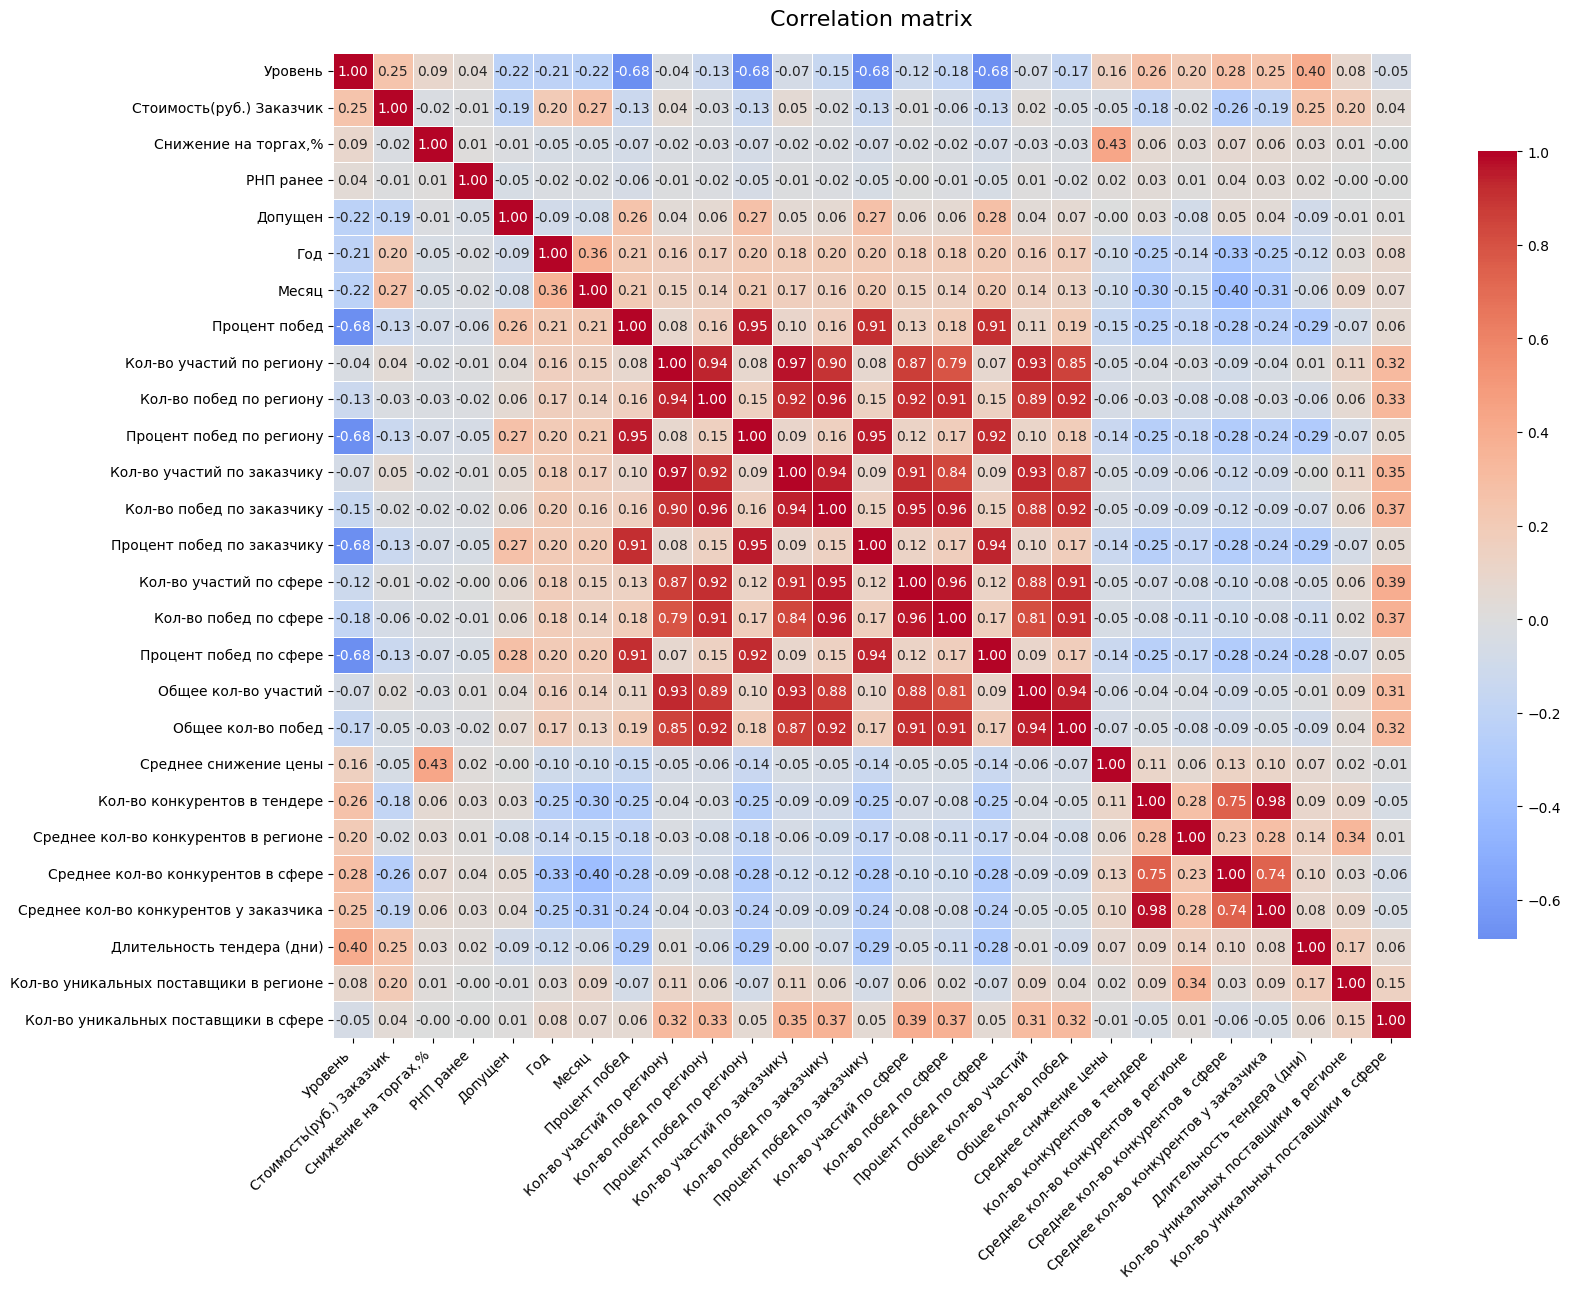

In [24]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(17, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation matrix", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Среднее снижение цены сильно коррелирует с снижением на торгах в %, уберем среднее значение

Общее количество участий сильно коррелирует с количеством участий по региону, по заказчику и по сфере - последние уберем


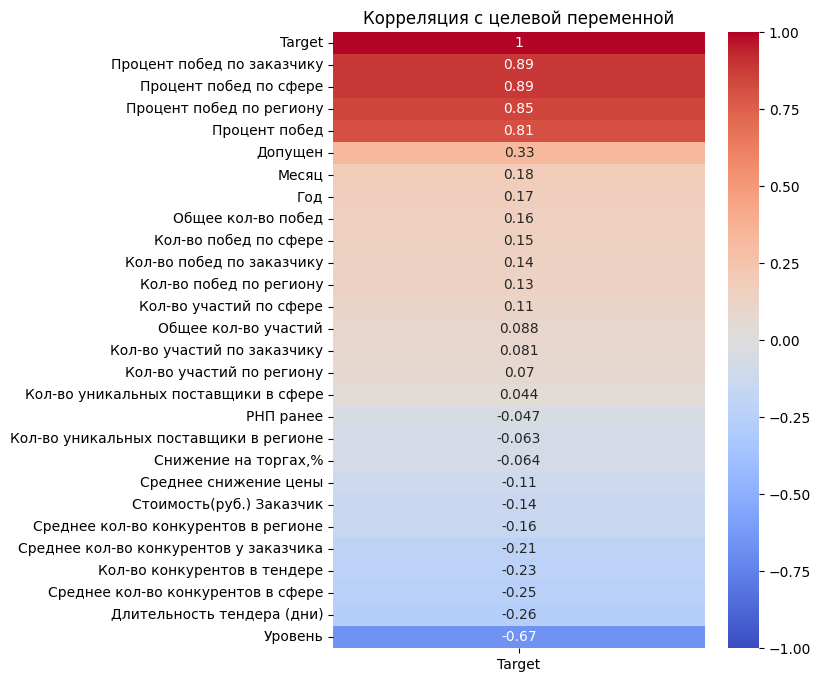

In [25]:
corr_with_target = df[numeric_cols + ['Target']].corr()[['Target']].sort_values('Target', ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция с целевой переменной')
plt.show()

In [11]:
df = df.drop(columns=['Среднее снижение цены', 'Кол-во участий по заказчику', 'Кол-во участий по региону', 'Кол-во участий по сфере'])

In [27]:
numeric_cols = ['Уровень', 'Стоимость(руб.) Заказчик',
       'Снижение на торгах,%', 'РНП ранее', 'Допущен', 'Год', 'Месяц', 
       'Процент побед', 'Кол-во побед по региону',
       'Процент побед по региону', 'Кол-во побед по заказчику', 
       'Процент побед по заказчику',  'Кол-во побед по сфере',
       'Процент побед по сфере', 'Общее кол-во участий', 'Общее кол-во побед', 
       'Кол-во конкурентов в тендере', 'Среднее кол-во конкурентов в регионе',
       'Среднее кол-во конкурентов в сфере',
       'Среднее кол-во конкурентов у заказчика', 'Длительность тендера (дни)',
       'Кол-во уникальных поставщики в регионе',
       'Кол-во уникальных поставщики в сфере']

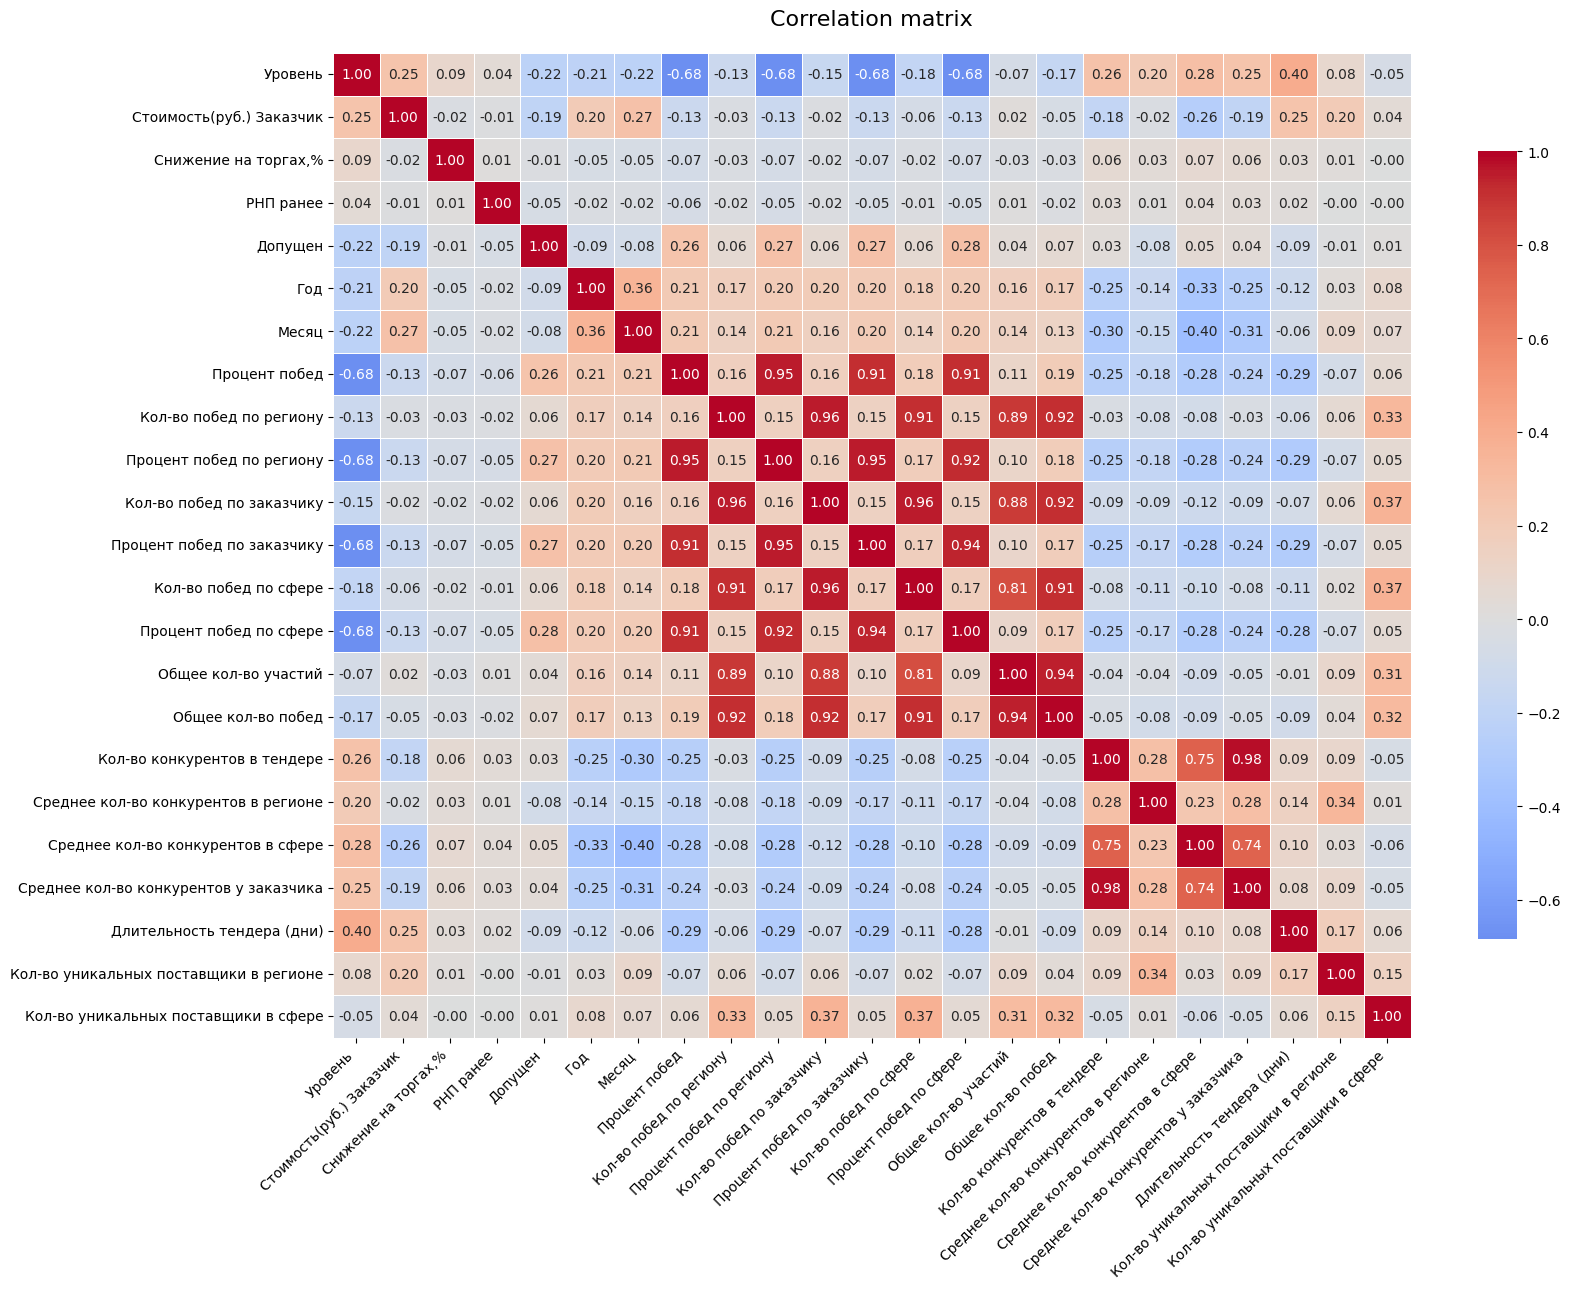

In [28]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(17, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation matrix", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Можно заметить, что корреляция между процентом побед по сфере/региону/заказчику слабо коррелирует с соответствующим количеством побед. Это говорит о разнородности участвующих компаний и их различных стратегиях (кто-то участвует во многих тендерах, а кто-то только в выигрышных)

Есть сильная корреляция между количеством конкурентов в тендере и средним количеством конкурентов у заказчиков, у первого корреляция больше (по модулю) с целевой переменной, поэтому уберем среднее количество конкурентов у заказчиков

In [12]:
numeric_cols = ['Уровень', 'Стоимость(руб.) Заказчик',
       'Снижение на торгах,%', 'РНП ранее', 'Допущен', 'Год', 'Месяц', 
       'Процент побед', 'Кол-во побед по региону',
       'Процент побед по региону', 'Кол-во побед по заказчику', 
       'Процент побед по заказчику',  'Кол-во побед по сфере',
       'Процент побед по сфере', 'Общее кол-во участий', 'Общее кол-во побед', 
       'Кол-во конкурентов в тендере', 'Среднее кол-во конкурентов в регионе',
       'Среднее кол-во конкурентов в сфере',
       'Длительность тендера (дни)',
       'Кол-во уникальных поставщики в регионе',
       'Кол-во уникальных поставщики в сфере']

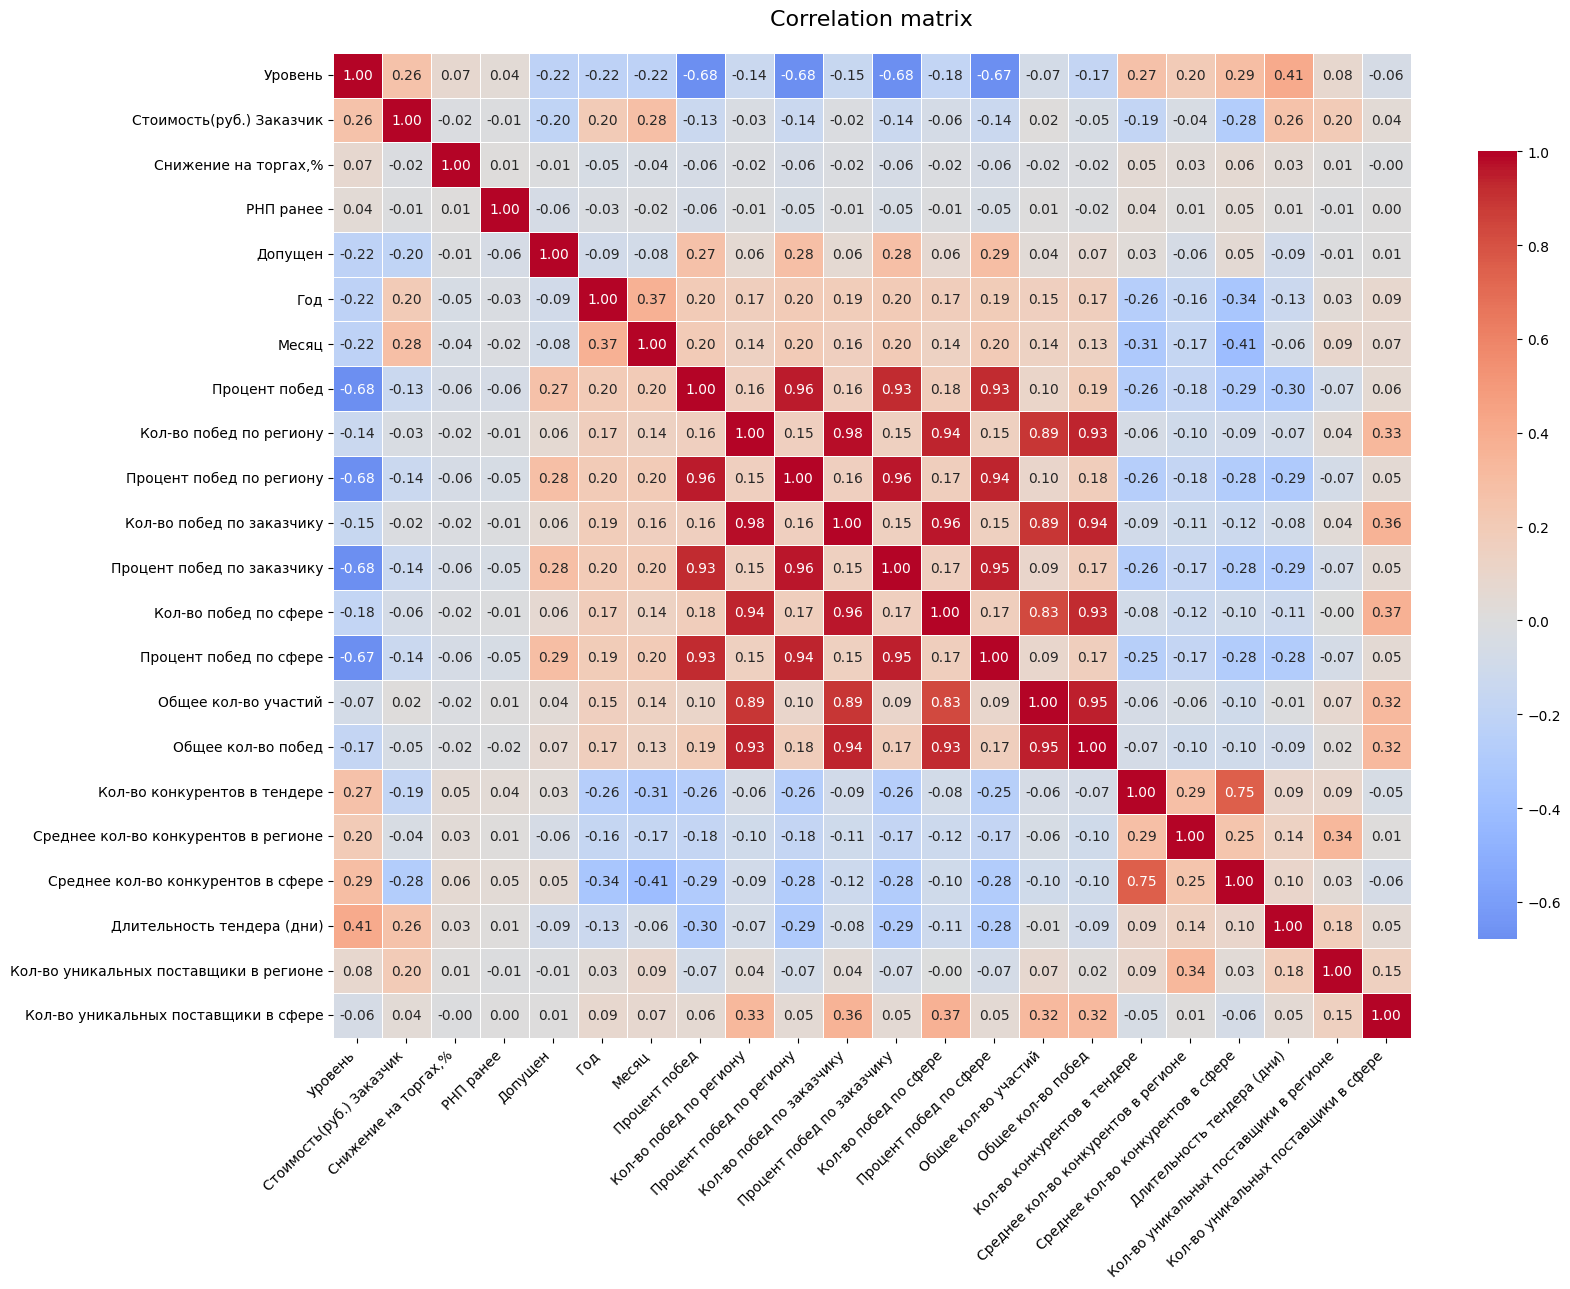

In [13]:
df = df.drop(columns=['Среднее кол-во конкурентов у заказчика'])

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(17, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation matrix", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Между количеством побед по региону, сфере и заказчику наблюдается высокая корреляция, но они могут понадобиться дальше, поэтому пока оставим. Аналоично для процентов побед


In [31]:
def check_significance(df, target_col='Target', alpha=0.05):
    results = []
    
    for feature in df.columns:
        if feature == target_col:
            continue
            
        if df[feature].dtype in ['int64', 'float64']:
            feature_type = 'Numerical'
        elif pd.api.types.is_datetime64_any_dtype(df[feature]):
            feature_type = 'DateTime'
            df[feature] = pd.to_numeric(df[feature])
        else:
            feature_type = 'Categorical'
            
        if feature_type in ['Numerical', 'DateTime']:  # для числовых признаков и дат используем t-тест
            group0 = df[df[target_col] == 0][feature].dropna()
            group1 = df[df[target_col] == 1][feature].dropna()
            
            stat, p = ttest_ind(group0, group1, equal_var=False)
                
        else:  # для категориальных признаков используем хи-квадрат
            contingency_table = pd.crosstab(df[feature], df[target_col])
            stat, p, _, _ = chi2_contingency(contingency_table)
        
        results.append({
            'Признак': feature,
            'Тип': feature_type,
            't-statistic': round(stat, 4),
            'p-value': round(p, 5),
            'Значимый': p < alpha
        })
    
    results_df = pd.DataFrame(results)
    return results_df.sort_values(by='p-value')

significance_results = check_significance(df)

significant_features = significance_results[significance_results['Значимый']]
print(f"Значимые признаки (p < 0.05):")
display(significant_features)

non_significant_features = significance_results[~significance_results['Значимый']]
print(f"\nНезначимые признаки (p >= 0.05):")
display(non_significant_features)

print(f"\nВсего признаков: {len(significance_results)}")
print(f"Значимых признаков: {len(significant_features)} ({len(significant_features)/len(significance_results):.1%})")
print(f"Незначимых признаков: {len(non_significant_features)} ({len(non_significant_features)/len(significance_results):.1%})")

Значимые признаки (p < 0.05):


,Признак,Тип,t-statistic,p-value,Значимый
0,Уровень,Numerical,357.8689,0.00000,True
20,Месяц,Categorical,6140.2103,0.00000,True
21,Процент побед,Numerical,-447.4121,0.00000,True
22,Кол-во побед по региону,Numerical,-51.1145,0.00000,True
23,Процент побед по региону,Numerical,-523.3280,0.00000,True
24,Кол-во побед по заказчику,Numerical,-52.3135,0.00000,True
25,Процент побед по заказчику,Numerical,-622.1038,0.00000,True
26,Кол-во побед по сфере,Numerical,-60.1846,0.00000,True
27,Процент побед по сфере,Numerical,-612.0768,0.00000,True
28,Общее кол-во участий,Numerical,-31.0900,0.00000,True



Незначимые признаки (p >= 0.05):


,Признак,Тип,t-statistic,p-value,Значимый
15,Форма публикации,Categorical,0.0,1.0,False



Всего признаков: 37
Значимых признаков: 36 (97.3%)
Незначимых признаков: 1 (2.7%)


Признак "Форма публикации" незначим на 5% уровне значимости, уберем его

In [14]:
df = df.drop(columns=['Форма публикации'])

In [33]:
df.columns

Index(['Уровень', 'Заказчик', 'ИНН заказчика', 'Стоимость(руб.) Заказчик',
       'Реестровый номер публикации', 'Сфера деятельности', 'Регион поставки',
       'Город поставки', 'Дата публикации',
       'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
       'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
       'Дата окончания проведения торгов', 'Поставщик', 'ИНН поставщика',
       'Снижение на торгах,%', 'Тип торгов', 'РНП ранее', 'Target', 'Допущен',
       'Год', 'Месяц', 'Процент побед', 'Кол-во побед по региону',
       'Процент побед по региону', 'Кол-во побед по заказчику',
       'Процент побед по заказчику', 'Кол-во побед по сфере',
       'Процент побед по сфере', 'Общее кол-во участий', 'Общее кол-во побед',
       'Последняя дата публикации', 'Кол-во конкурентов в тендере',
       'Среднее кол-во конкурентов в регионе',
       'Среднее кол-во конкурентов в сфере'

In [15]:
date_columns = [
    'Дата публикации',
    'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
    'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
    'Дата окончания проведения торгов',
    'Последняя дата публикации'
]

df_temporal = pd.DataFrame(index=df.index)

for col in date_columns:
    df_temporal[col] = pd.to_datetime(df[col])
df_temporal['Target'] = df['Target']

df_temporal['Длительность_приема_заявок'] = (
    df_temporal[date_columns[1]] - df_temporal[date_columns[2]]
).dt.days.abs()

df_temporal['Время_до_торгов'] = (
    df_temporal[date_columns[3]] - df_temporal[date_columns[0]]
).dt.days.abs()

df_temporal['Время_с_последней_публикации'] = (
    df_temporal[date_columns[0]] - df_temporal[date_columns[4]]
).dt.days.abs()

for col in date_columns:
    df_temporal[f'{col}_месяц'] = df_temporal[col].dt.month
    df_temporal[f'{col}_день_недели'] = df_temporal[col].dt.dayofweek
    df_temporal[f'{col}_выходной'] = df_temporal[col].dt.dayofweek.isin([5, 6]).astype(int)
    df_temporal[f'{col}_сезон'] = df_temporal[col].dt.month.map({
        12: 'Зима', 1: 'Зима', 2: 'Зима',
        3: 'Весна', 4: 'Весна', 5: 'Весна',
        6: 'Лето', 7: 'Лето', 8: 'Лето',
        9: 'Осень', 10: 'Осень', 11: 'Осень'
    })

print("\nСтатистика по временным интервалам:")
time_intervals = ['Длительность_приема_заявок', 'Время_до_торгов', 'Время_с_последней_публикации']
print(df_temporal[time_intervals].describe())


Статистика по временным интервалам:
       Длительность_приема_заявок  Время_до_торгов  \
count                54937.000000     54937.000000   
mean                     7.223565        11.290351   
std                      6.537803        14.161561   
min                      0.000000         0.000000   
25%                      1.000000         2.000000   
50%                      7.000000         8.000000   
75%                      9.000000        12.000000   
max                    364.000000       389.000000   

       Время_с_последней_публикации  
count                  54937.000000  
mean                     226.634472  
std                      419.754388  
min                        0.000000  
25%                        0.000000  
50%                        0.000000  
75%                      281.000000  
max                     1876.000000  


In [35]:
print("\nКорреляция с целевой переменной:")
for col in time_intervals:
    correlation = df_temporal[col].corr(df_temporal['Target'])
    print(f"{col}: {correlation:.3f}")


Корреляция с целевой переменной:
Длительность_приема_заявок: -0.279
Время_до_торгов: -0.213
Время_с_последней_публикации: 0.100


Наибольшая корреляция с целевой переменной у длительности приема заявок

In [ ]:
for col in date_columns:
    season_col = f'{col}_сезон'
    success_rate = pd.crosstab(df_temporal[season_col], df_temporal['Target'], normalize='index') * 100
    print(f"\nПроцент успешных тендеров по сезонам для {col}:")
    print(success_rate[1].sort_values(ascending=False))


Процент успешных тендеров по сезонам для Дата публикации:
Дата публикации_сезон
Весна    68.876056
Осень    68.197206
Лето     67.160650
Зима     50.506744
Name: 1, dtype: float64

Процент успешных тендеров по сезонам для Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ:
Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ_сезон
Весна    68.127674
Осень    67.678245
Лето     66.558659
Зима     50.762687
Name: 1, dtype: float64

Процент успешных тендеров по сезонам для Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ:
Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ_сезон
Весна    68.825002
Осень    68.324057
Лето     67.192447
Зима     50.509686
Name: 1, dtype: float64

Процент успешных тендеров по сезонам для Дата окончания проведения торгов:
Дата окончания проведения торгов_сезон
Осень   

В данных наблюдается сезонность. Весна и осень показывают стабильно высокую успешность (около 68%), зима - значительно более низкую (50-55%). Лето по значениям близко к весне и осени (66-67%)

In [37]:
for col in date_columns:
    month_success = pd.crosstab(df_temporal[col].dt.month, df_temporal['Target'], normalize='index') * 100
    print(f"\nПроцент успешных тендеров по месяцам для {col}:")
    print(month_success[1].sort_values(ascending=False))


Процент успешных тендеров по месяцам для Дата публикации:
Дата публикации
12    75.697605
3     70.254080
11    69.921150
4     68.329604
9     67.861178
6     67.502061
7     67.341729
5     67.324895
10    67.264808
8     66.580263
2     64.544990
1     44.609148
Name: 1, dtype: float64

Процент успешных тендеров по месяцам для Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ:
Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ
12    75.508637
11    69.246960
3     69.036145
9     68.283768
4     67.768080
7     67.635493
2     67.446394
5     67.076083
6     66.102728
10    65.985282
8     65.956284
1     44.734729
Name: 1, dtype: float64

Процент успешных тендеров по месяцам для Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ:
Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ
12    75.

Есть выраженная успешность участия в тендерах в декабре и пониженный процент выигрышей в январе

In [15]:
days = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 3: 'Четверг', 
            4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}
for col in date_columns:
    df_temporal[f'{col}_день_недели'] = df_temporal[col].dt.dayofweek.map(days)
    day_success = pd.crosstab(df_temporal[f'{col}_день_недели'], df_temporal['Target'], normalize='index') * 100
    print(f"\nПроцент успешных тендеров по дням недели для {col}:")
    print(day_success[1].sort_values(ascending=False))


Процент успешных тендеров по дням недели для Дата публикации:
Дата публикации_день_недели
Воскресенье    64.126394
Суббота        62.002413
Четверг        61.628301
Пятница        61.175109
Вторник        60.053189
Понедельник    58.060268
Среда          56.956270
Name: 1, dtype: float64

Процент успешных тендеров по дням недели для Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ:
Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ_день_недели
Суббота        77.570093
Вторник        64.612756
Воскресенье    62.761506
Понедельник    62.046719
Среда          59.067064
Четверг        58.730417
Пятница        55.154439
Name: 1, dtype: float64

Процент успешных тендеров по дням недели для Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ:
Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ_день_не

Для временных признаков, которые попадают на выходные дни, характерен повышенный процент побед. Самый большой разброс по значениям характерен для даты окончания приема заявок

In [16]:
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Утро'
    elif 12 <= hour < 17:
        return 'День'
    elif 17 <= hour < 22:
        return 'Вечер'
    else:
        return 'Ночь'

for col in date_columns:
    df_temporal[f'{col}_время_суток'] = df_temporal[col].dt.hour.apply(get_time_of_day)
    time_success = pd.crosstab(df_temporal[f'{col}_время_суток'], df_temporal['Target'], normalize='index') * 100
    print(f"\nПроцент успешных тендеров по времени суток для {col}:")
    print(time_success[1].sort_values(ascending=False))


Процент успешных тендеров по времени суток для Дата публикации:
Дата публикации_время_суток
Ночь     71.865443
Утро     61.884891
Вечер    59.503254
День     57.769769
Name: 1, dtype: float64

Процент успешных тендеров по времени суток для Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ:
Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ_время_суток
День     72.400268
Вечер    60.802356
Ночь     56.889495
Утро     51.385778
Name: 1, dtype: float64

Процент успешных тендеров по времени суток для Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ:
Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ_время_суток
Ночь     70.349053
Вечер    48.586488
Утро     38.951311
День     37.861771
Name: 1, dtype: float64

Процент успешных тендеров по времени суток для Дата окончания проведения торгов:
Дата 

Для публикации ночь наиболее успешна, для окончания приема - день (тут максимальная разница в значениях), для начала подачи заявок - ночь успешна, а днем совсем плохо это делать

In [17]:
for col in date_columns:
    if col == 'Дата публикации':
        df_temporal[f'{col}_месяц'] = df_temporal[col].dt.month
        df_temporal['Публикация_декабрь'] = (df_temporal[col].dt.month == 12).astype(int)
        df_temporal['Публикация_январь'] = (df_temporal[col].dt.month == 1).astype(int)
    
    df_temporal[f'{col}_время_суток'] = df_temporal[col].dt.hour.apply(get_time_of_day)

    if col == 'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ':
        df_temporal['Окончание_прием_суббота'] = (df_temporal[col].dt.dayofweek == 5).astype(int)

important_features = [
    'Длительность_приема_заявок',
    'Время_до_торгов',
    'Публикация_декабрь',
    'Публикация_январь',
    'Окончание_прием_суббота'
]

for feature in important_features:
    df[feature] = df_temporal[feature]

In [41]:
len(df.columns.tolist())

42

In [18]:
numerical_features = [
    'Процент побед', 'Кол-во побед по региону', 'Процент побед по региону',
    'Кол-во побед по заказчику', 'Процент побед по заказчику',
    'Кол-во побед по сфере', 'Процент побед по сфере',
    'Общее кол-во участий', 'Общее кол-во побед',
    'Стоимость(руб.) Заказчик', 'Длительность_приема_заявок', 
    'Время_до_торгов', 'Кол-во конкурентов в тендере',
    'Среднее кол-во конкурентов в регионе', 'Среднее кол-во конкурентов в сфере',
    'Длительность тендера (дни)', 'Кол-во уникальных поставщики в регионе',
    'Кол-во уникальных поставщики в сфере'
]

categorical_features = [
    'Уровень', 'Регион поставки', 'Сфера деятельности', 
    'Тип торгов', 'РНП ранее', 'Заказчик', 'Город поставки', 'Поставщик'
]

time_features = [
    'Год', 'Месяц', 
    'Публикация_декабрь', 'Публикация_январь', 'Окончание_прием_суббота'
]

train_data = df[df['Год'].isin(range(2019, 2024))].copy()
test_data = df[df['Год'].isin(range(2024, 2026))].copy()

feature_columns = numerical_features + categorical_features + time_features

X_train = train_data[feature_columns]
y_train = train_data['Target']
X_test = test_data[feature_columns]
y_test = test_data['Target']

Посмотрим, что стновится с распределением при использовании различных scalers. Так как скейлеры по-разному работают с выбросами и распределениями, будем сначала смотреть на распределения по всем данным, затем обработаем выбросы на тренировочных данных и после этого перейдем к обучению моделей на чистых данных

Анализ процентных признаков:

Статистики для Процент побед:
Среднее: 0.60
Медиана: 0.67
Стд. отклонение: 0.41

Статистики после MinMaxScaler:
Среднее: 0.60
Медиана: 0.67
Стд. отклонение: 0.41
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: -0.08
Медиана: 0.00
Стд. отклонение: 0.48
Min: -0.78
Max: 0.39

Статистики после StandardScaler:
Среднее: 0.00
Медиана: 0.17
Стд. отклонение: 1.00
Min: -1.44
Max: 0.97


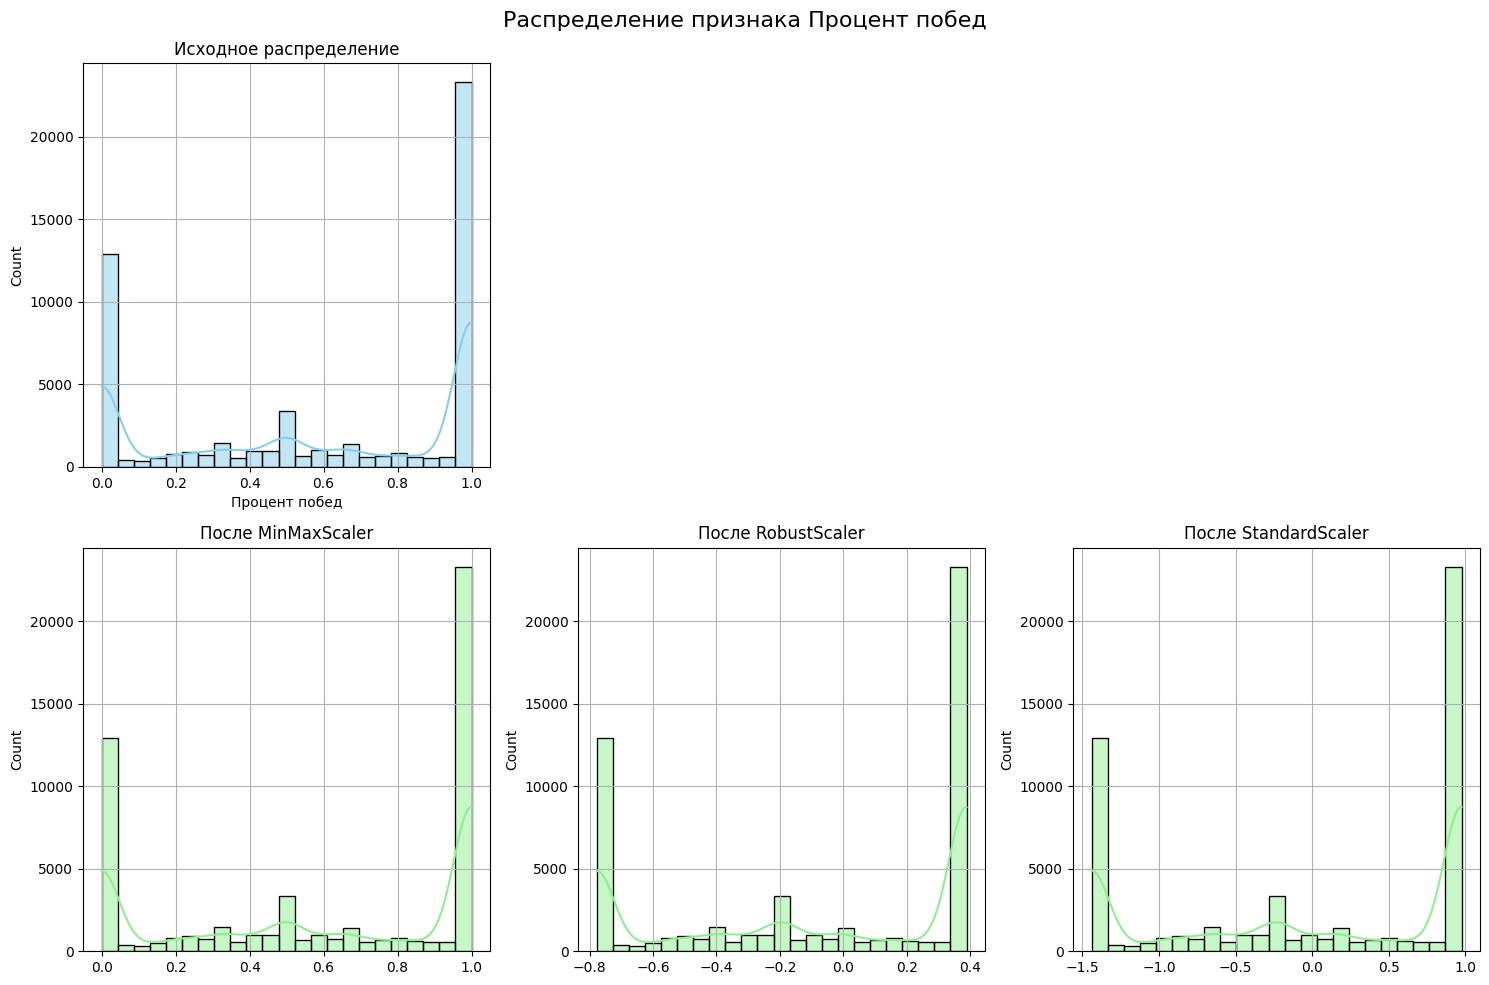


Статистики для Процент побед по региону:
Среднее: 0.60
Медиана: 0.78
Стд. отклонение: 0.43

Статистики после MinMaxScaler:
Среднее: 0.60
Медиана: 0.78
Стд. отклонение: 0.43
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: -0.18
Медиана: 0.00
Стд. отклонение: 0.43
Min: -0.78
Max: 0.22

Статистики после StandardScaler:
Среднее: -0.00
Медиана: 0.42
Стд. отклонение: 1.00
Min: -1.38
Max: 0.93


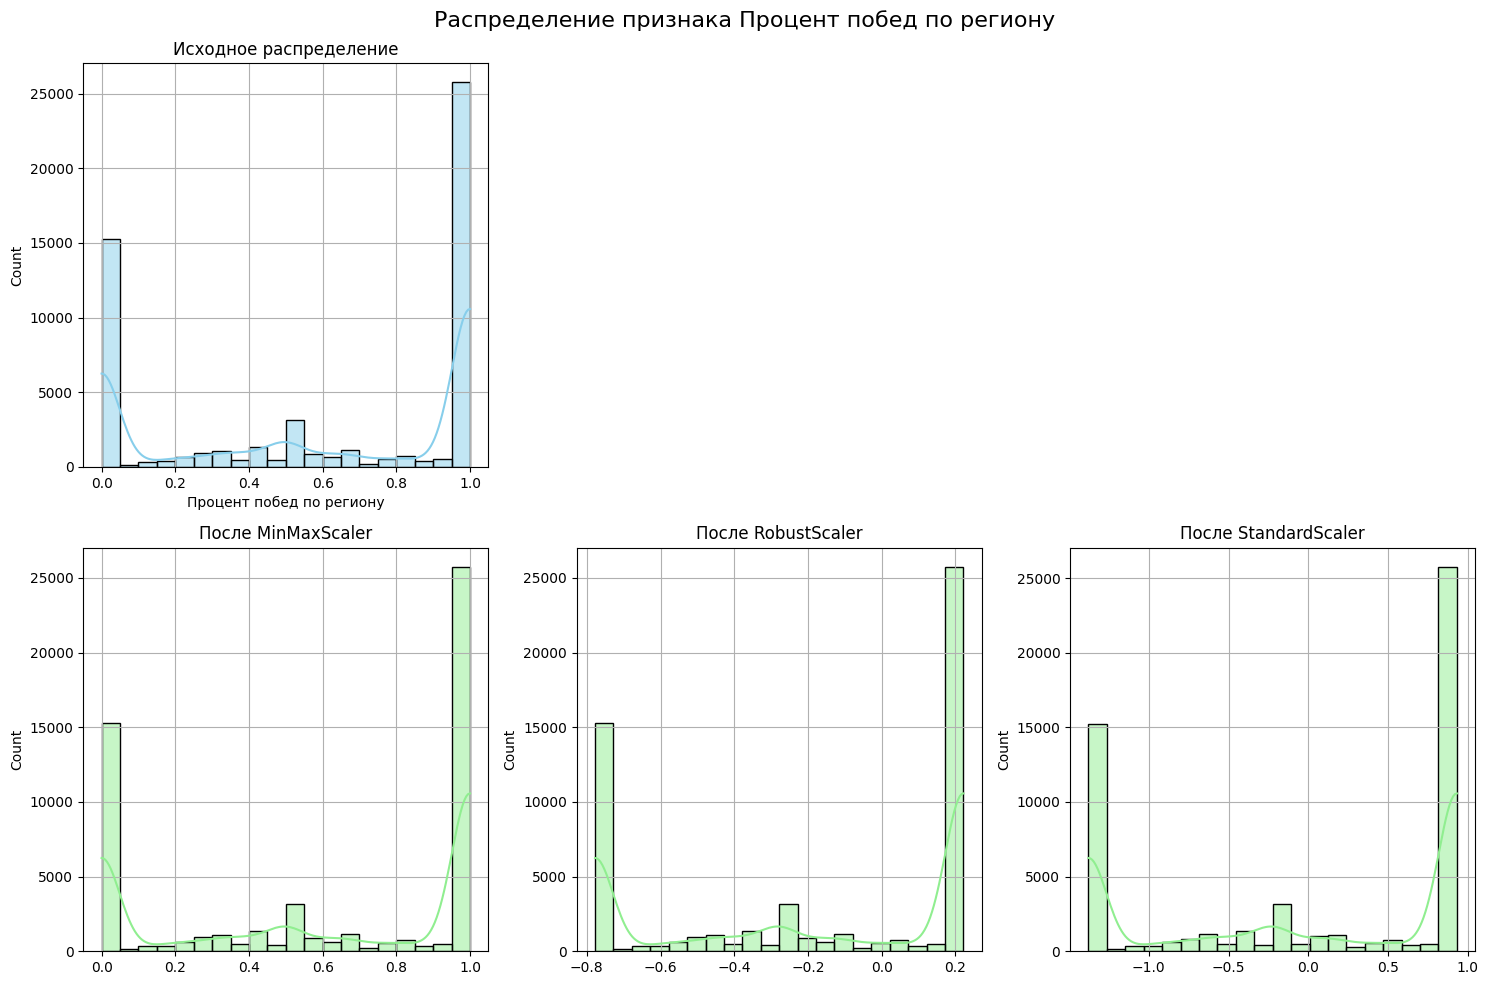


Статистики для Процент побед по заказчику:
Среднее: 0.60
Медиана: 0.96
Стд. отклонение: 0.45

Статистики после MinMaxScaler:
Среднее: 0.60
Медиана: 0.96
Стд. отклонение: 0.45
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: -0.36
Медиана: 0.00
Стд. отклонение: 0.45
Min: -0.96
Max: 0.04

Статистики после StandardScaler:
Среднее: -0.00
Медиана: 0.80
Стд. отклонение: 1.00
Min: -1.33
Max: 0.90


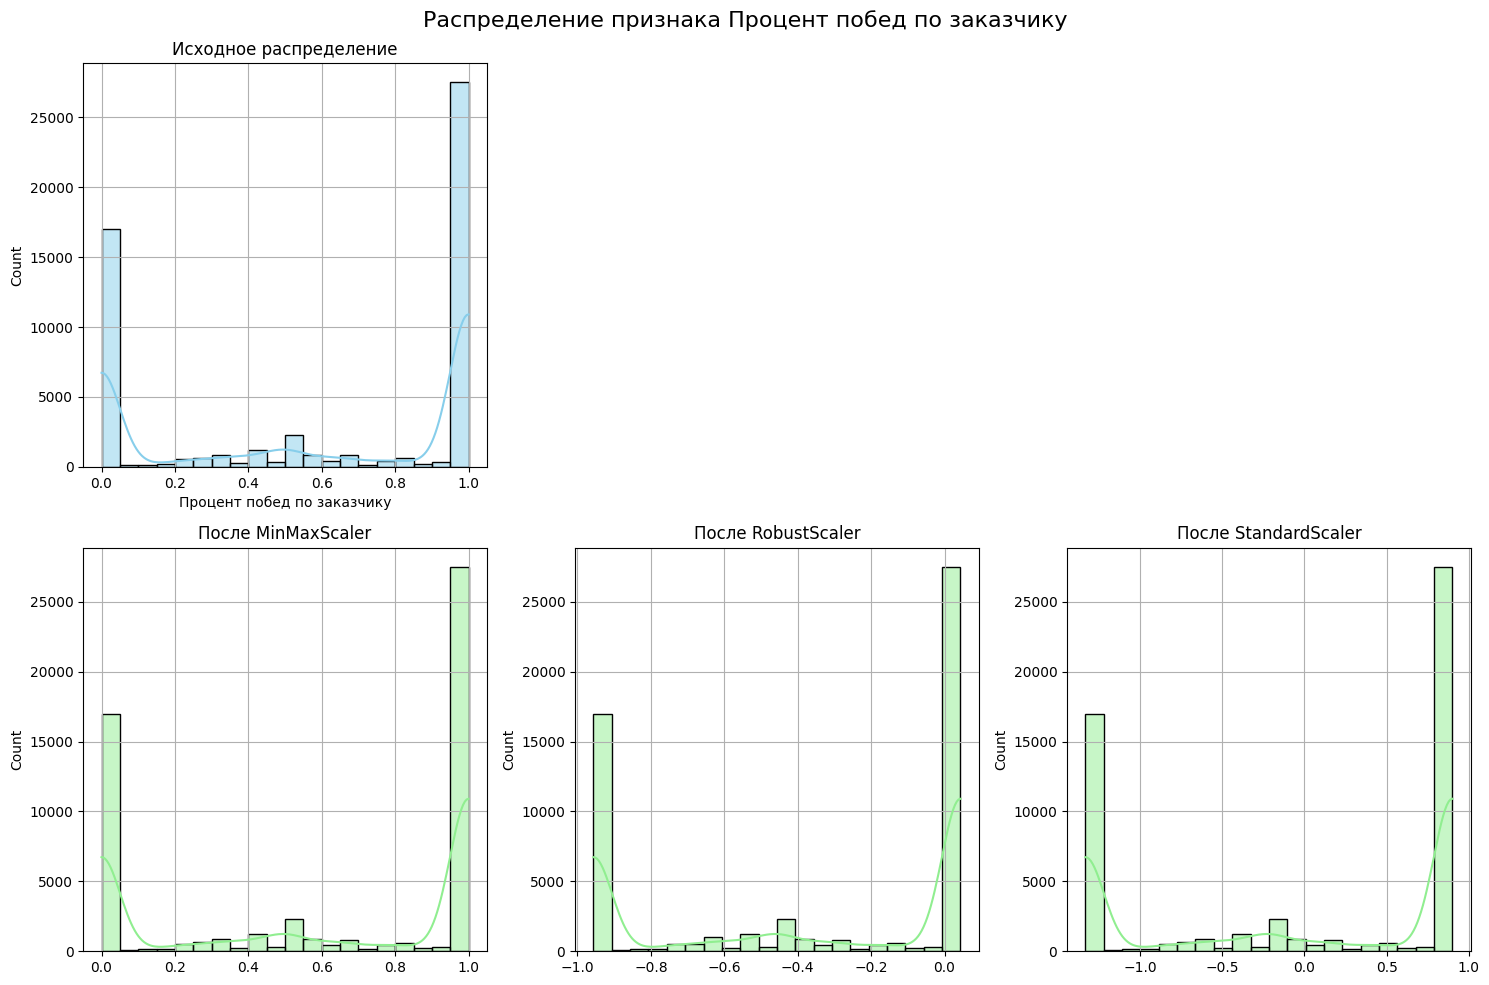


Статистики для Процент побед по сфере:
Среднее: 0.60
Медиана: 0.92
Стд. отклонение: 0.45

Статистики после MinMaxScaler:
Среднее: 0.60
Медиана: 0.92
Стд. отклонение: 0.45
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: -0.32
Медиана: 0.00
Стд. отклонение: 0.45
Min: -0.92
Max: 0.08

Статистики после StandardScaler:
Среднее: 0.00
Медиана: 0.72
Стд. отклонение: 1.00
Min: -1.33
Max: 0.90


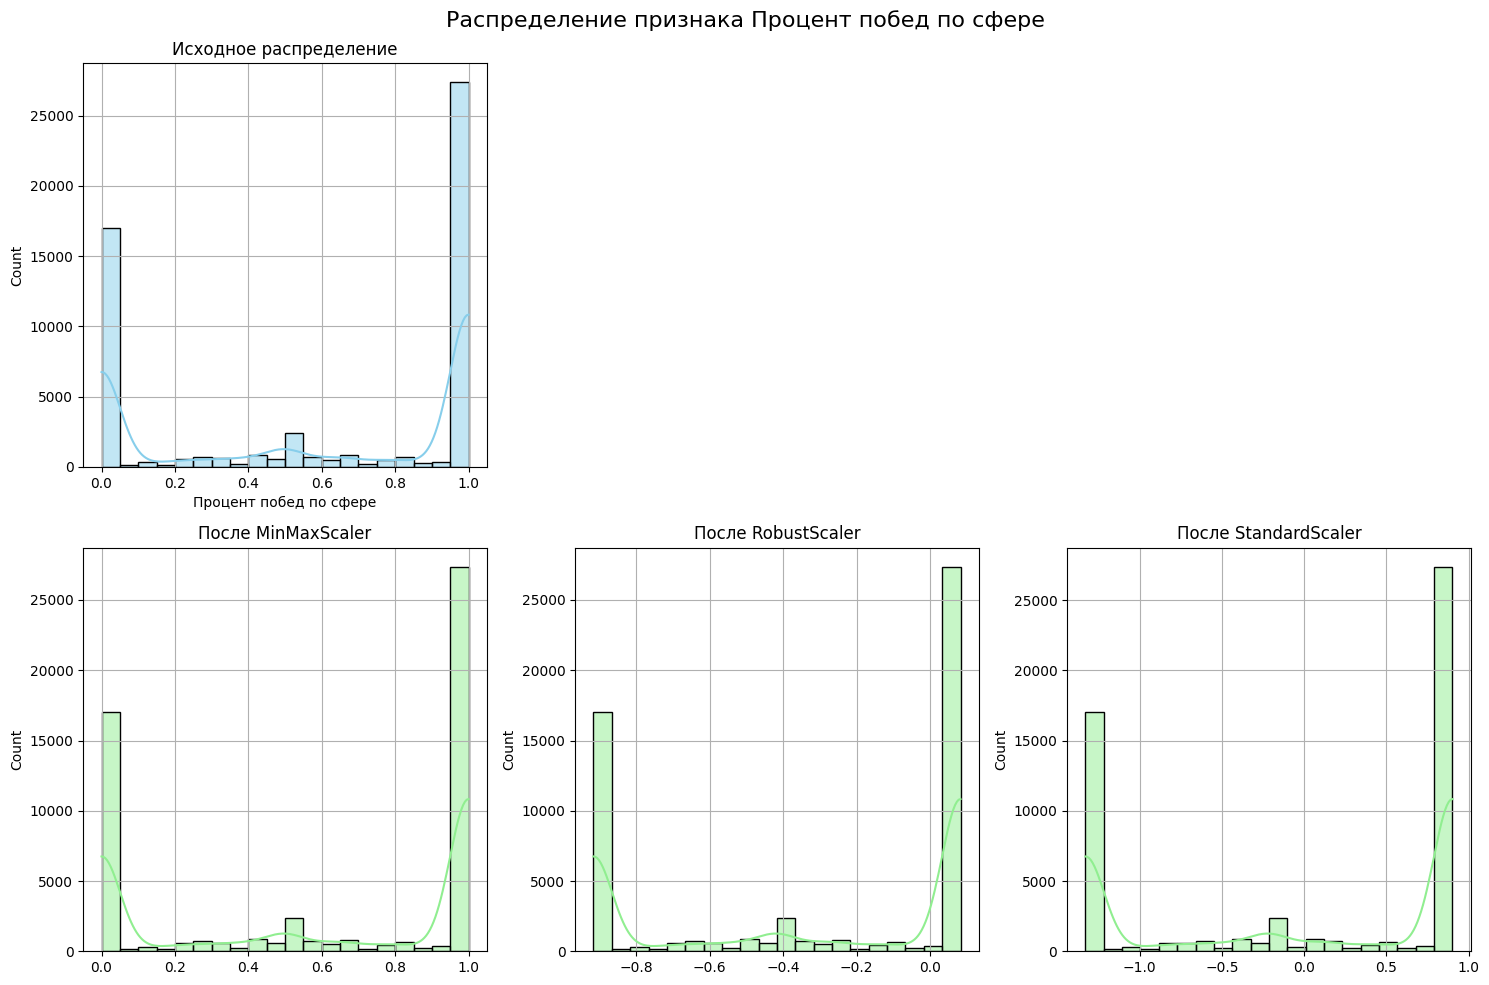


Анализ количественных признаков:

Статистики для Кол-во побед по региону:
Среднее: 8.90
Медиана: 1.00
Стд. отклонение: 31.49

Статистики после MinMaxScaler:
Среднее: 0.03
Медиана: 0.00
Стд. отклонение: 0.11
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 2.63
Медиана: 0.00
Стд. отклонение: 10.50
Min: -0.33
Max: 96.33

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.25
Стд. отклонение: 1.00
Min: -0.28
Max: 8.93


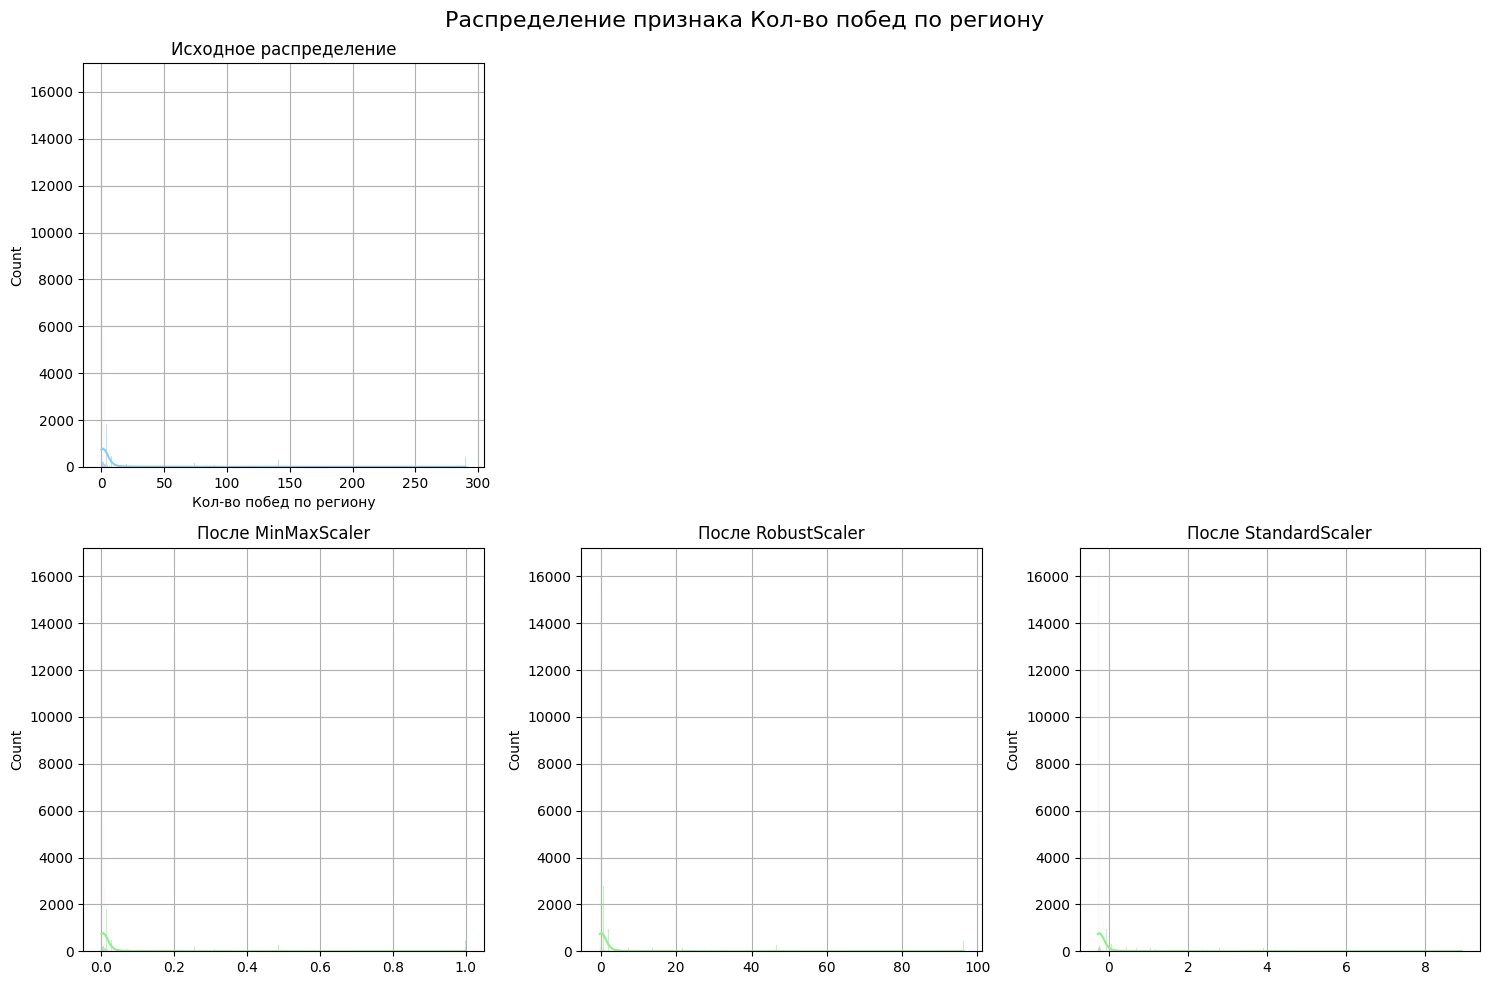


Статистики для Кол-во побед по заказчику:
Среднее: 8.79
Медиана: 1.00
Стд. отклонение: 32.23

Статистики после MinMaxScaler:
Среднее: 0.03
Медиана: 0.00
Стд. отклонение: 0.11
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 3.89
Медиана: 0.00
Стд. отклонение: 16.12
Min: -0.50
Max: 145.50

Статистики после StandardScaler:
Среднее: -0.00
Медиана: -0.24
Стд. отклонение: 1.00
Min: -0.27
Max: 8.79


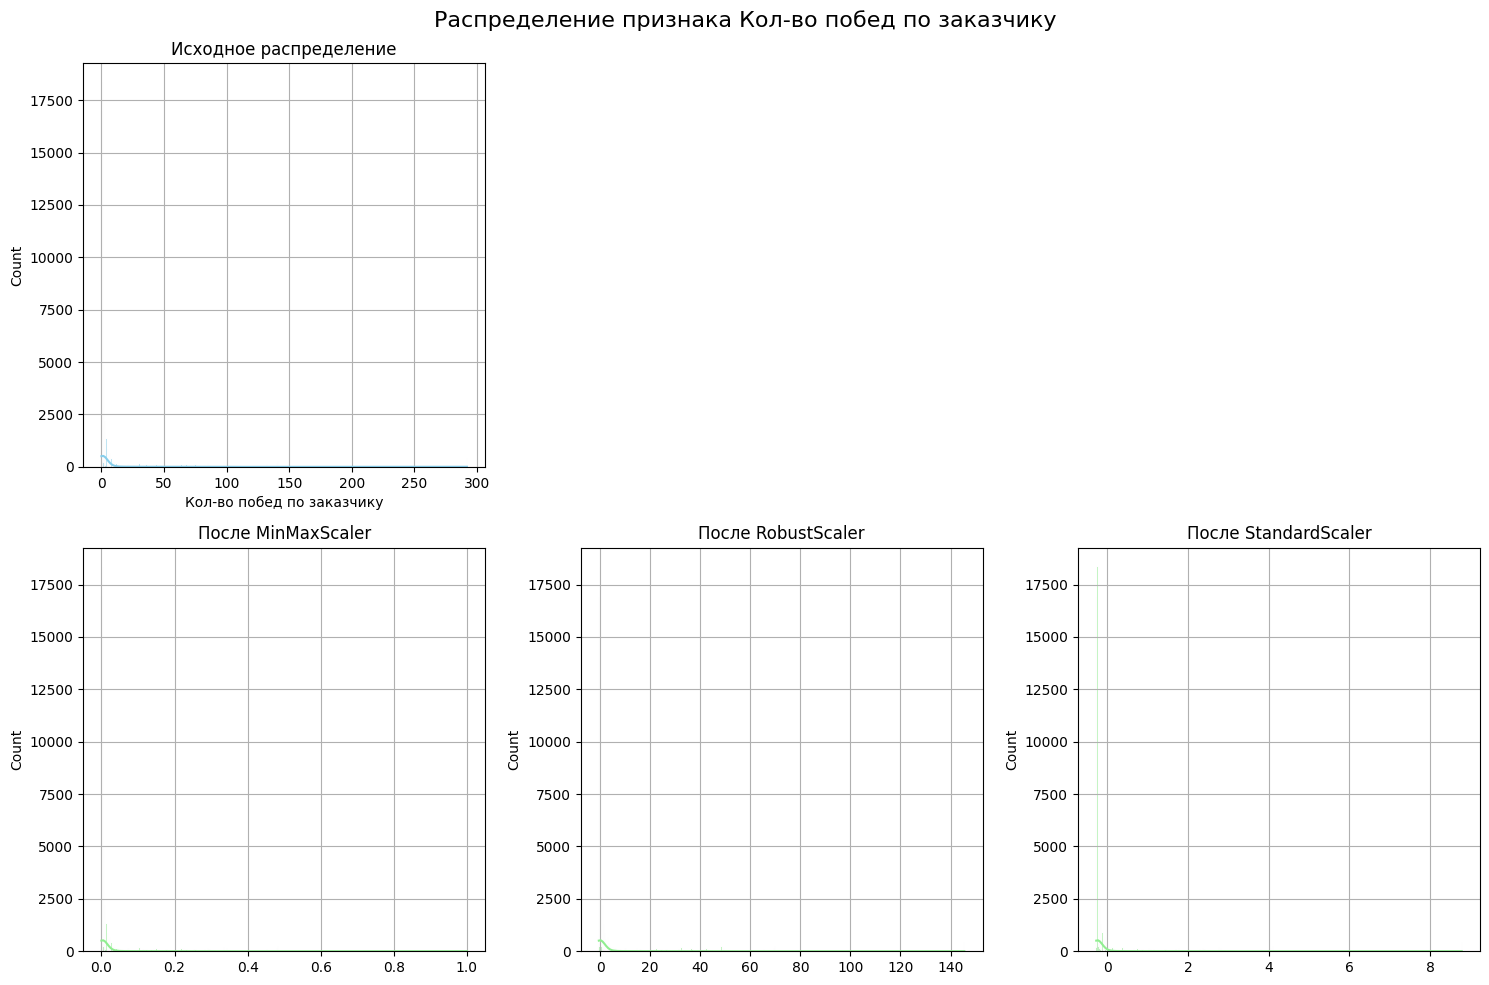


Статистики для Кол-во побед по сфере:
Среднее: 7.84
Медиана: 1.00
Стд. отклонение: 30.42

Статистики после MinMaxScaler:
Среднее: 0.03
Медиана: 0.00
Стд. отклонение: 0.10
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 3.42
Медиана: 0.00
Стд. отклонение: 15.21
Min: -0.50
Max: 145.50

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.22
Стд. отклонение: 1.00
Min: -0.26
Max: 9.34


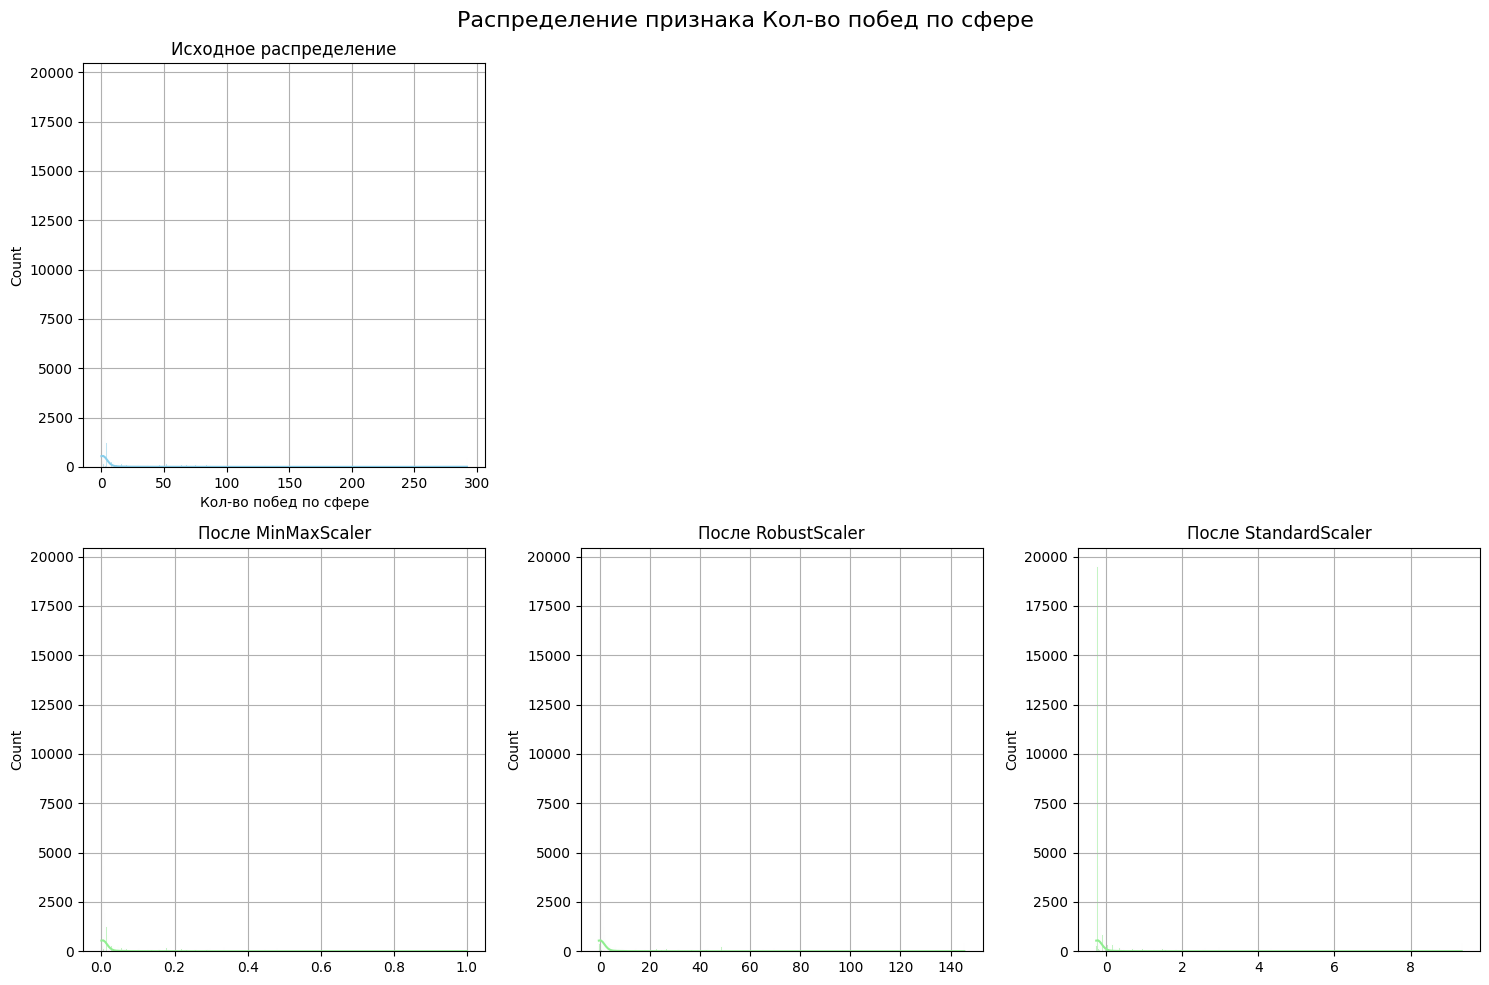


Статистики для Общее кол-во участий:
Среднее: 15.74
Медиана: 2.00
Стд. отклонение: 41.02

Статистики после MinMaxScaler:
Среднее: 0.05
Медиана: 0.00
Стд. отклонение: 0.14
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 1.96
Медиана: 0.00
Стд. отклонение: 5.86
Min: -0.14
Max: 41.43

Статистики после StandardScaler:
Среднее: -0.00
Медиана: -0.33
Стд. отклонение: 1.00
Min: -0.36
Max: 6.74


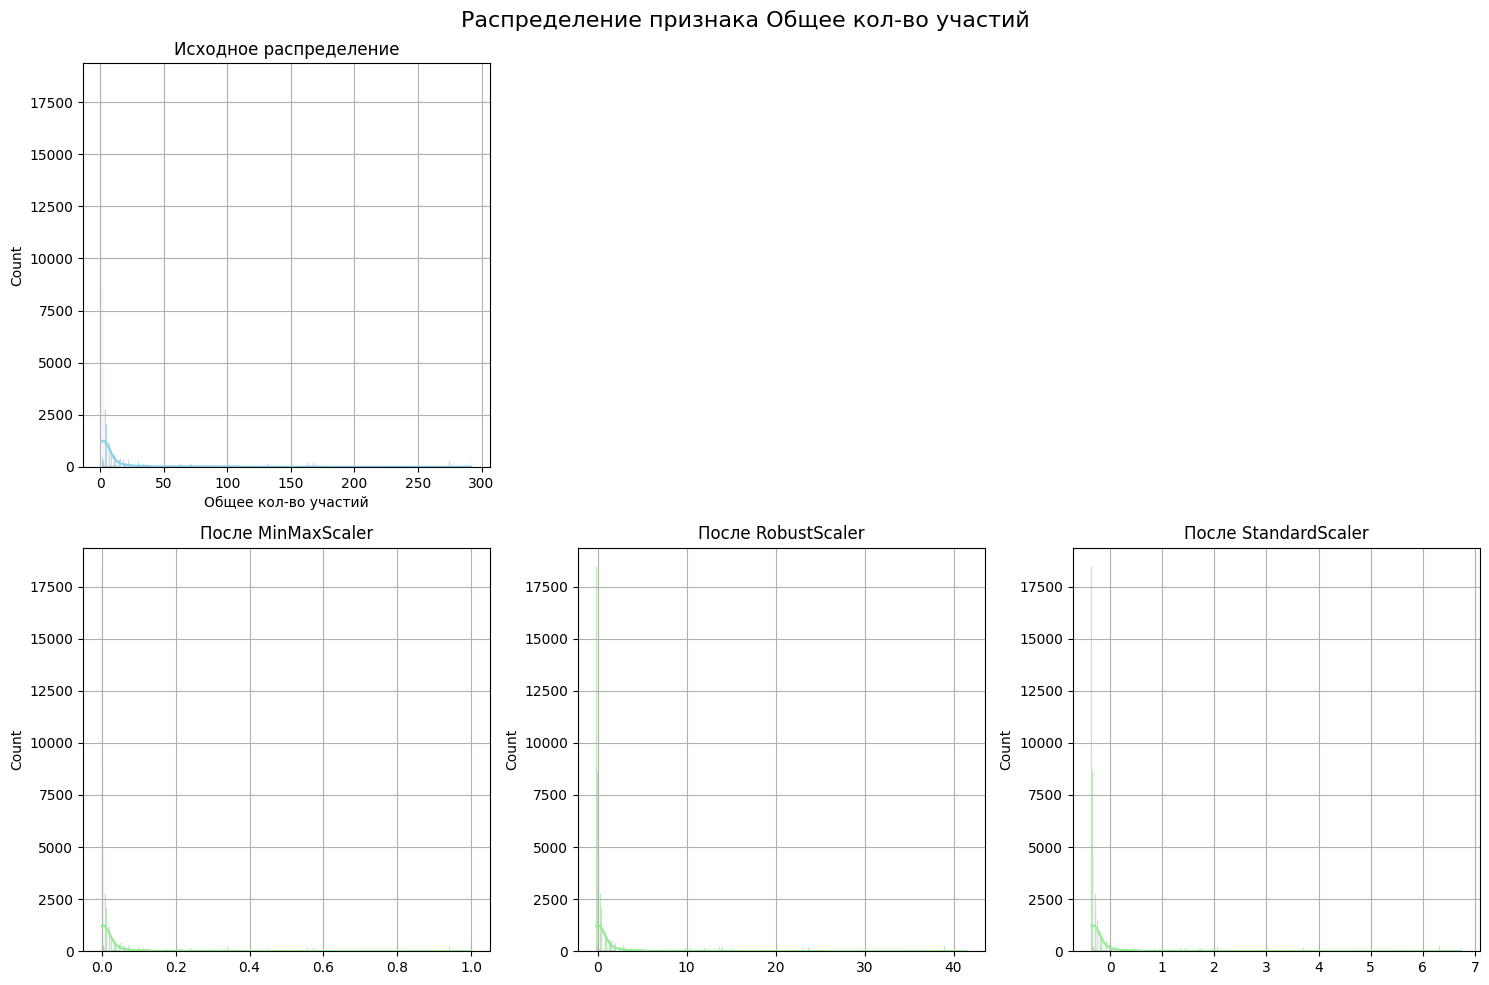


Статистики для Общее кол-во побед:
Среднее: 11.12
Медиана: 1.00
Стд. отклонение: 33.97

Статистики после MinMaxScaler:
Среднее: 0.04
Медиана: 0.00
Стд. отклонение: 0.12
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 2.98
Медиана: 0.00
Стд. отклонение: 9.99
Min: -0.29
Max: 85.59

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.30
Стд. отклонение: 1.00
Min: -0.33
Max: 8.27


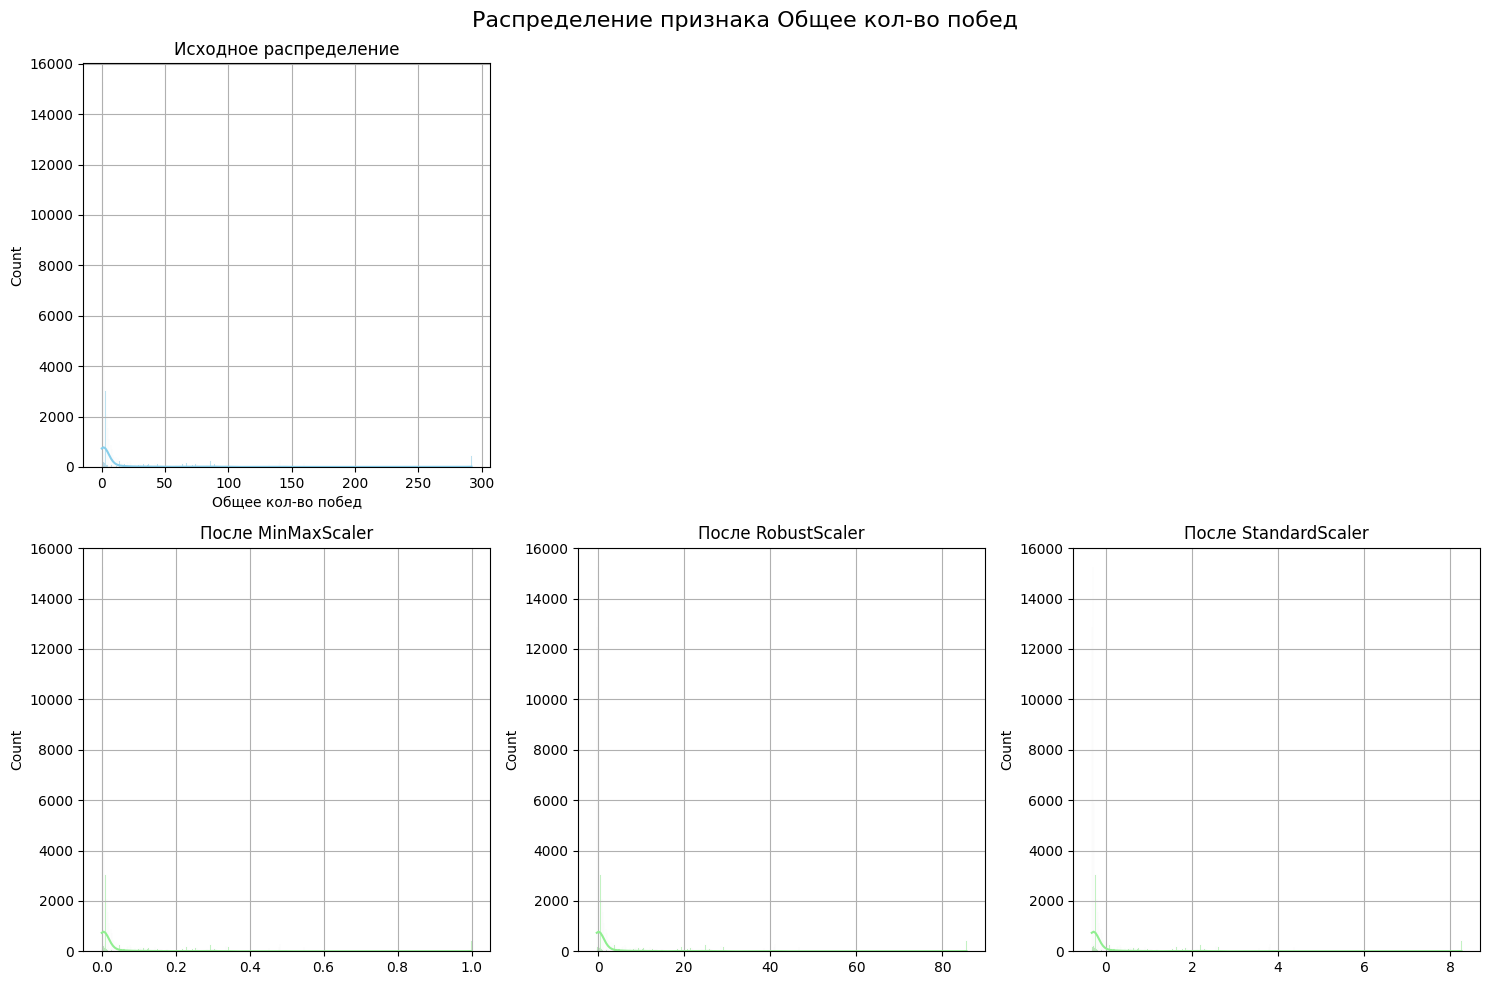


Статистики для Кол-во конкурентов в тендере:
Среднее: 5.16
Медиана: 1.00
Стд. отклонение: 13.07

Статистики после MinMaxScaler:
Среднее: 0.04
Медиана: 0.01
Стд. отклонение: 0.09
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 1.04
Медиана: 0.00
Стд. отклонение: 3.27
Min: -0.25
Max: 35.25

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.32
Стд. отклонение: 1.00
Min: -0.39
Max: 10.47


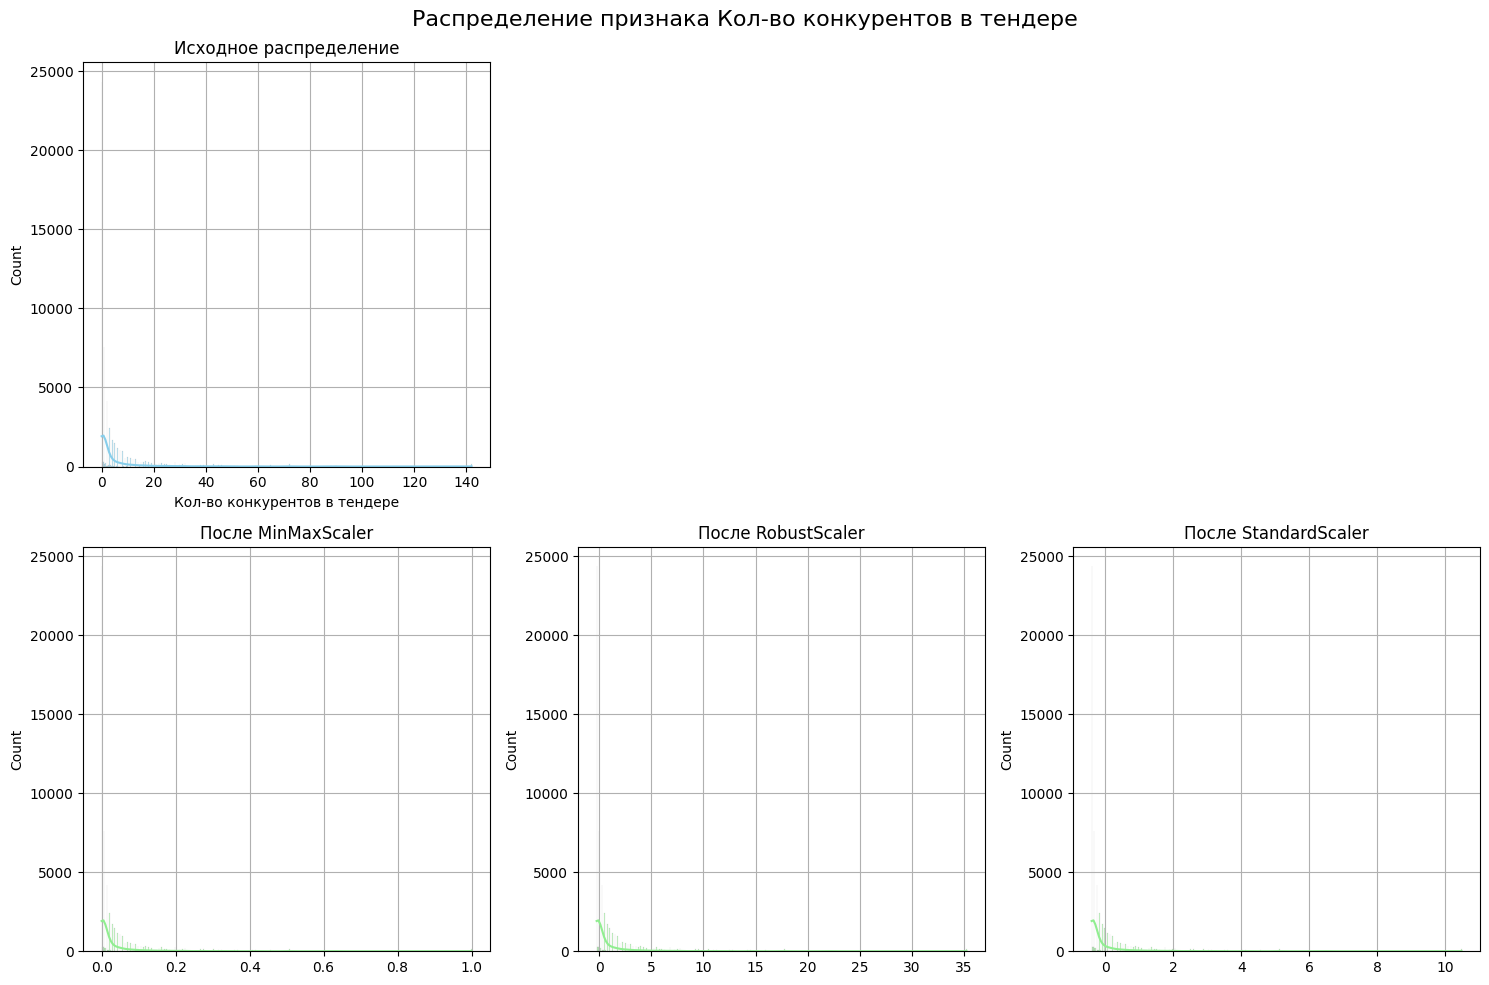


Статистики для Среднее кол-во конкурентов в регионе:
Среднее: 5.47
Медиана: 4.52
Стд. отклонение: 3.84

Статистики после MinMaxScaler:
Среднее: 0.25
Медиана: 0.21
Стд. отклонение: 0.18
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 0.15
Медиана: 0.00
Стд. отклонение: 0.63
Min: -0.71
Max: 2.72

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.25
Стд. отклонение: 1.00
Min: -1.38
Max: 4.10


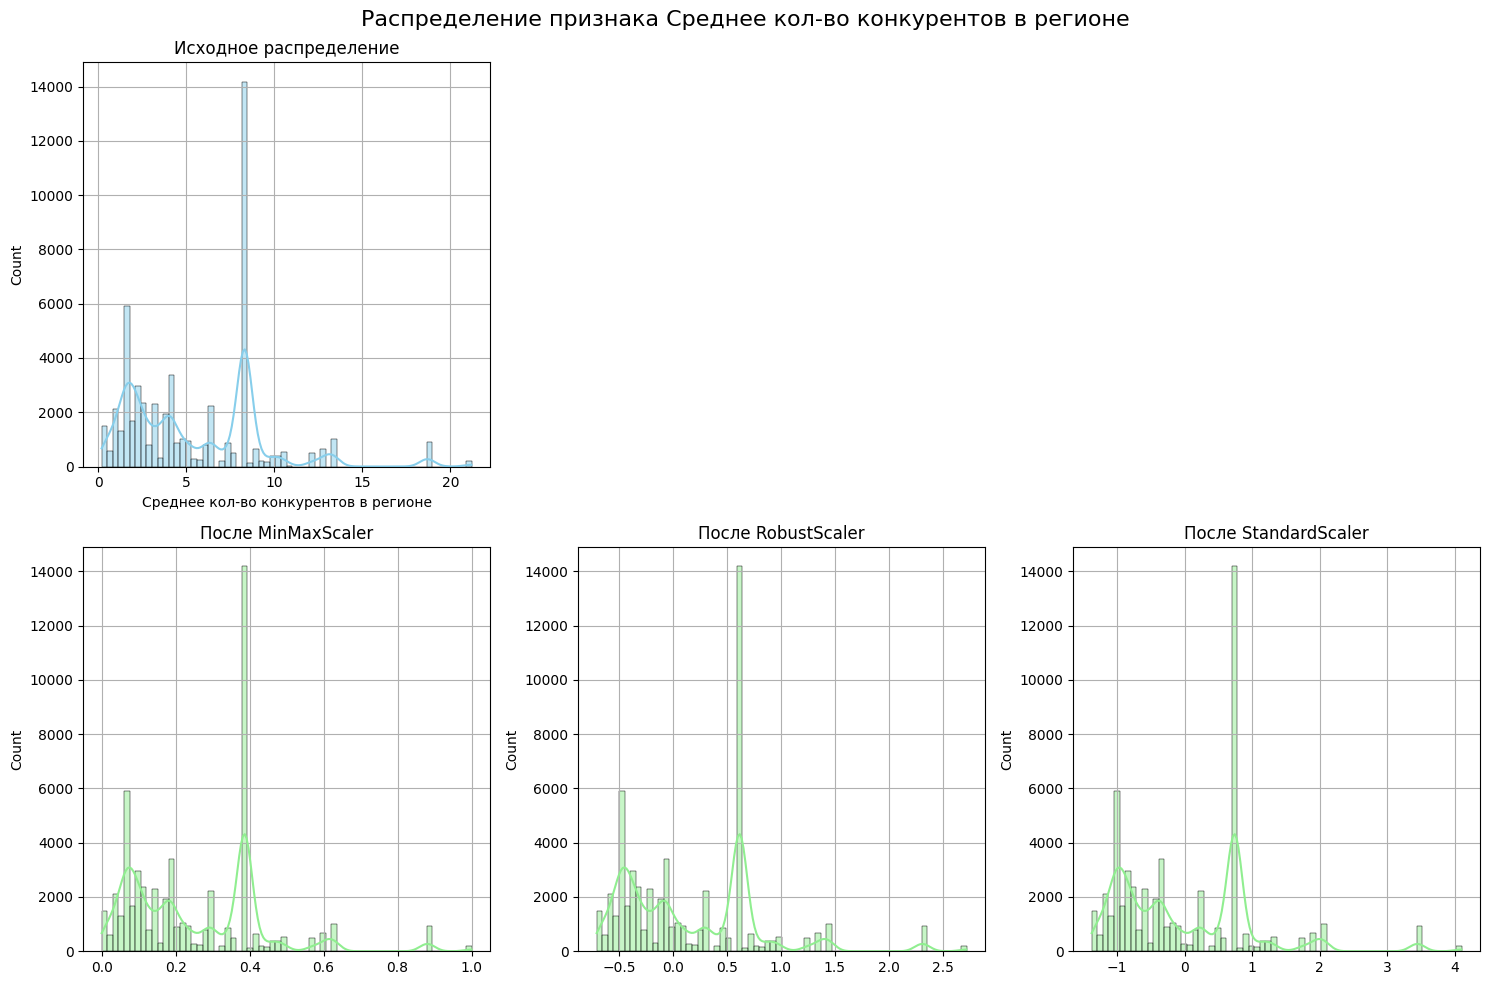


Статистики для Среднее кол-во конкурентов в сфере:
Среднее: 5.18
Медиана: 1.00
Стд. отклонение: 9.83

Статистики после MinMaxScaler:
Среднее: 0.04
Медиана: 0.01
Стд. отклонение: 0.07
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 0.69
Медиана: 0.00
Стд. отклонение: 1.63
Min: -0.17
Max: 23.39

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.43
Стд. отклонение: 1.00
Min: -0.53
Max: 13.92


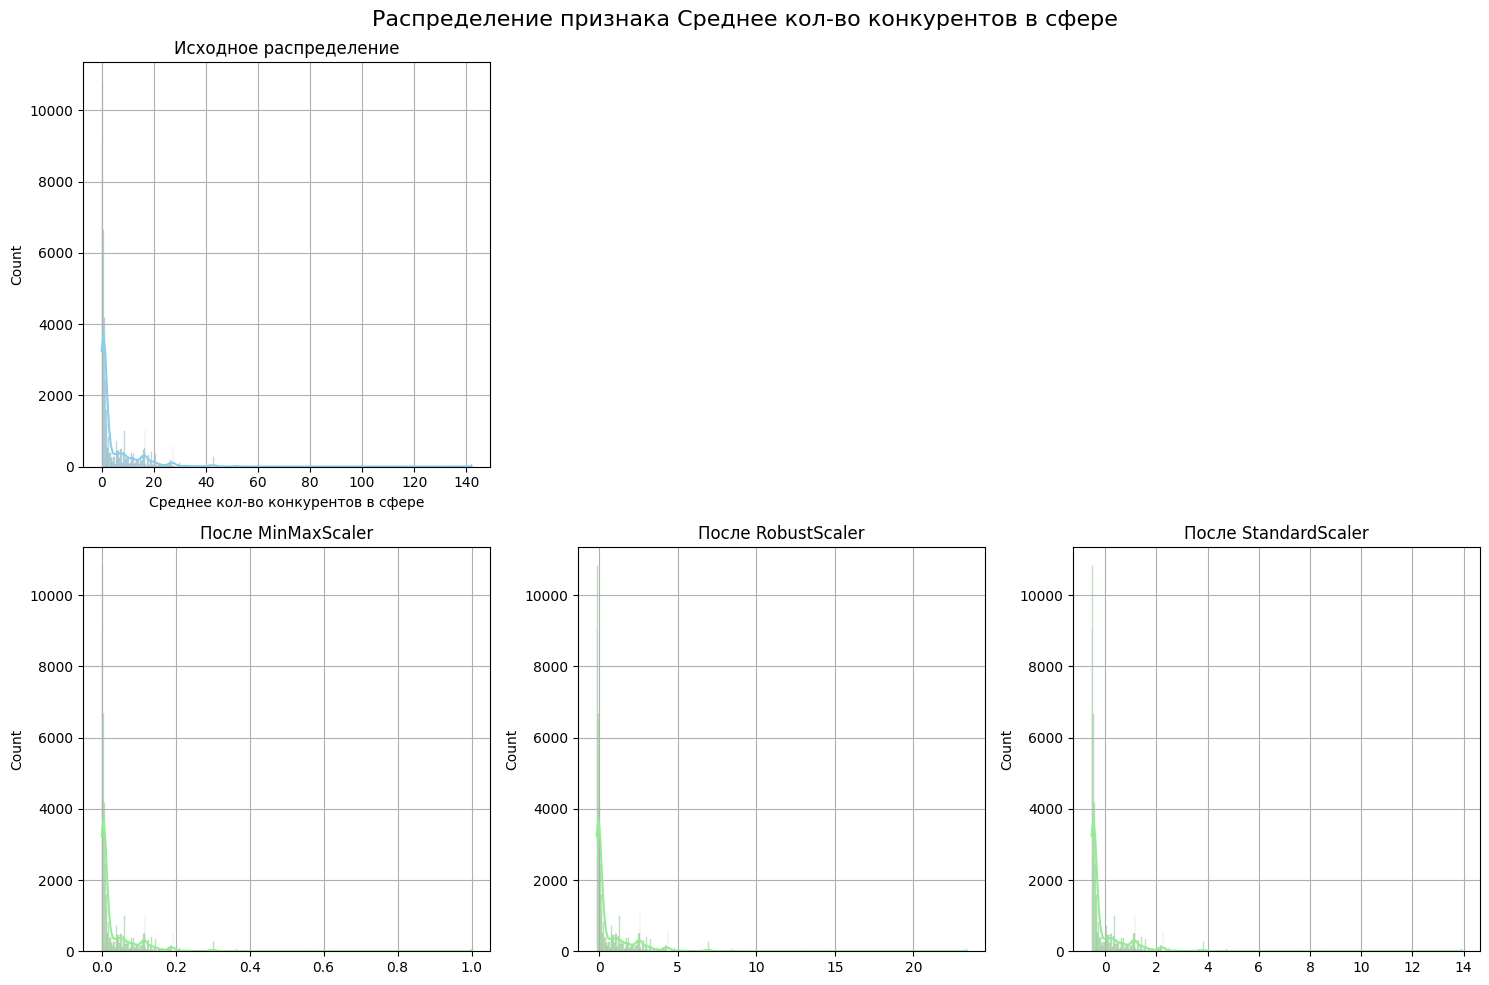


Статистики для Кол-во уникальных поставщики в регионе:
Среднее: 1190.58
Медиана: 614.00
Стд. отклонение: 1331.29

Статистики после MinMaxScaler:
Среднее: 0.29
Медиана: 0.15
Стд. отклонение: 0.33
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 0.69
Медиана: 0.00
Стд. отклонение: 1.59
Min: -0.71
Max: 4.14

Статистики после StandardScaler:
Среднее: -0.00
Медиана: -0.43
Стд. отклонение: 1.00
Min: -0.88
Max: 2.17


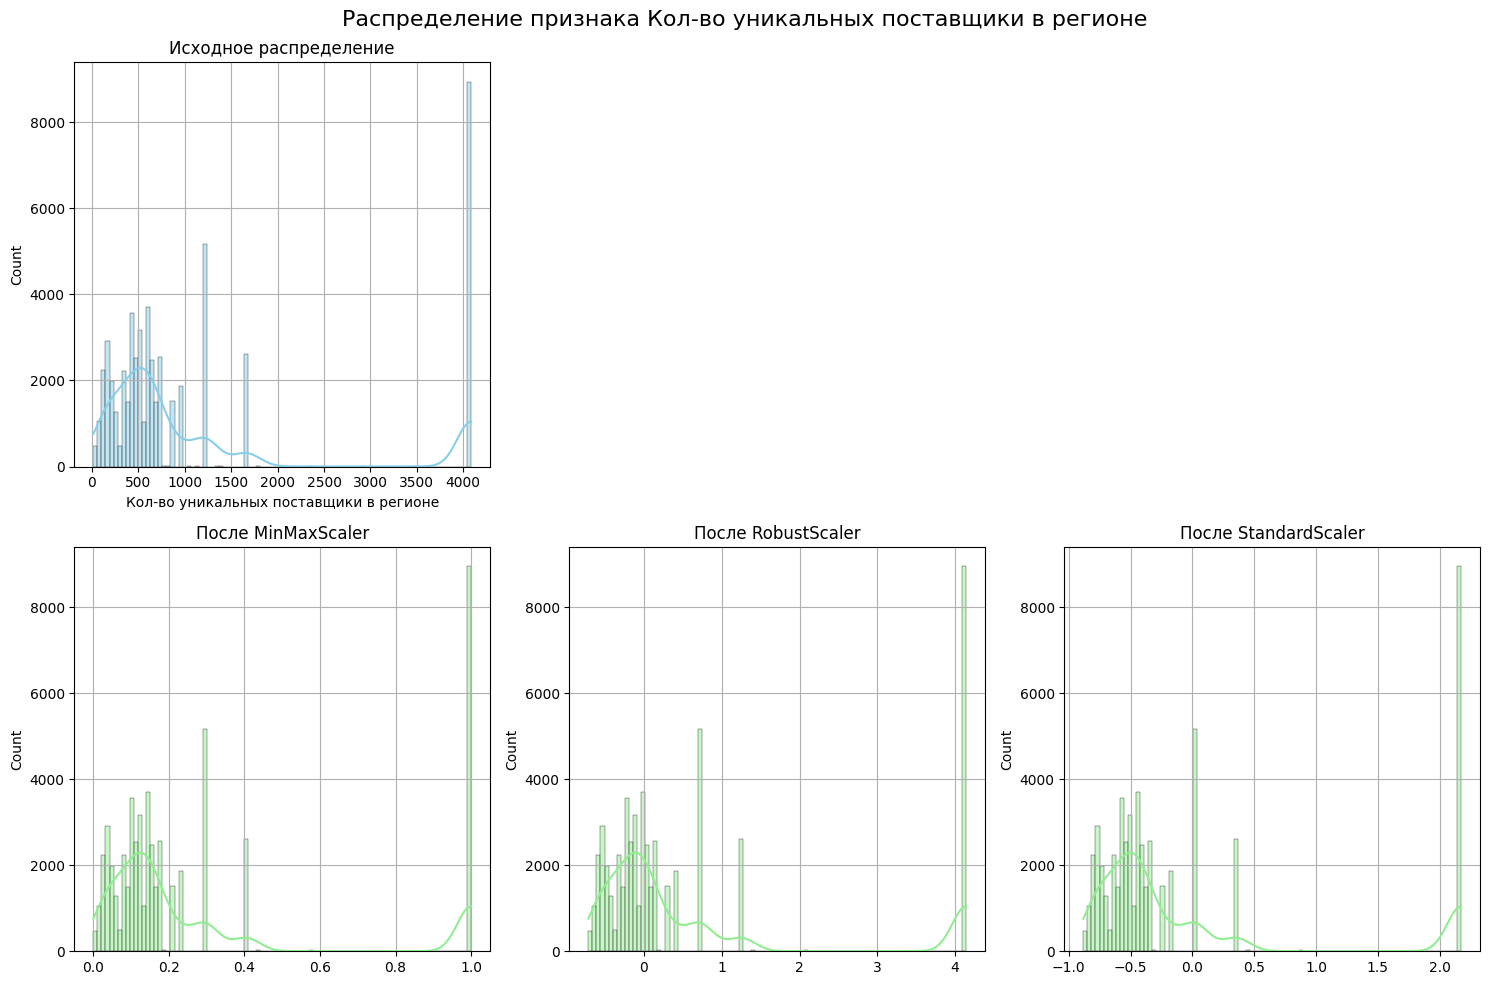


Статистики для Кол-во уникальных поставщики в сфере:
Среднее: 132.50
Медиана: 71.00
Стд. отклонение: 163.87

Статистики после MinMaxScaler:
Среднее: 0.18
Медиана: 0.10
Стд. отклонение: 0.23
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 0.33
Медиана: 0.00
Стд. отклонение: 0.87
Min: -0.37
Max: 3.49

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.38
Стд. отклонение: 1.00
Min: -0.80
Max: 3.63


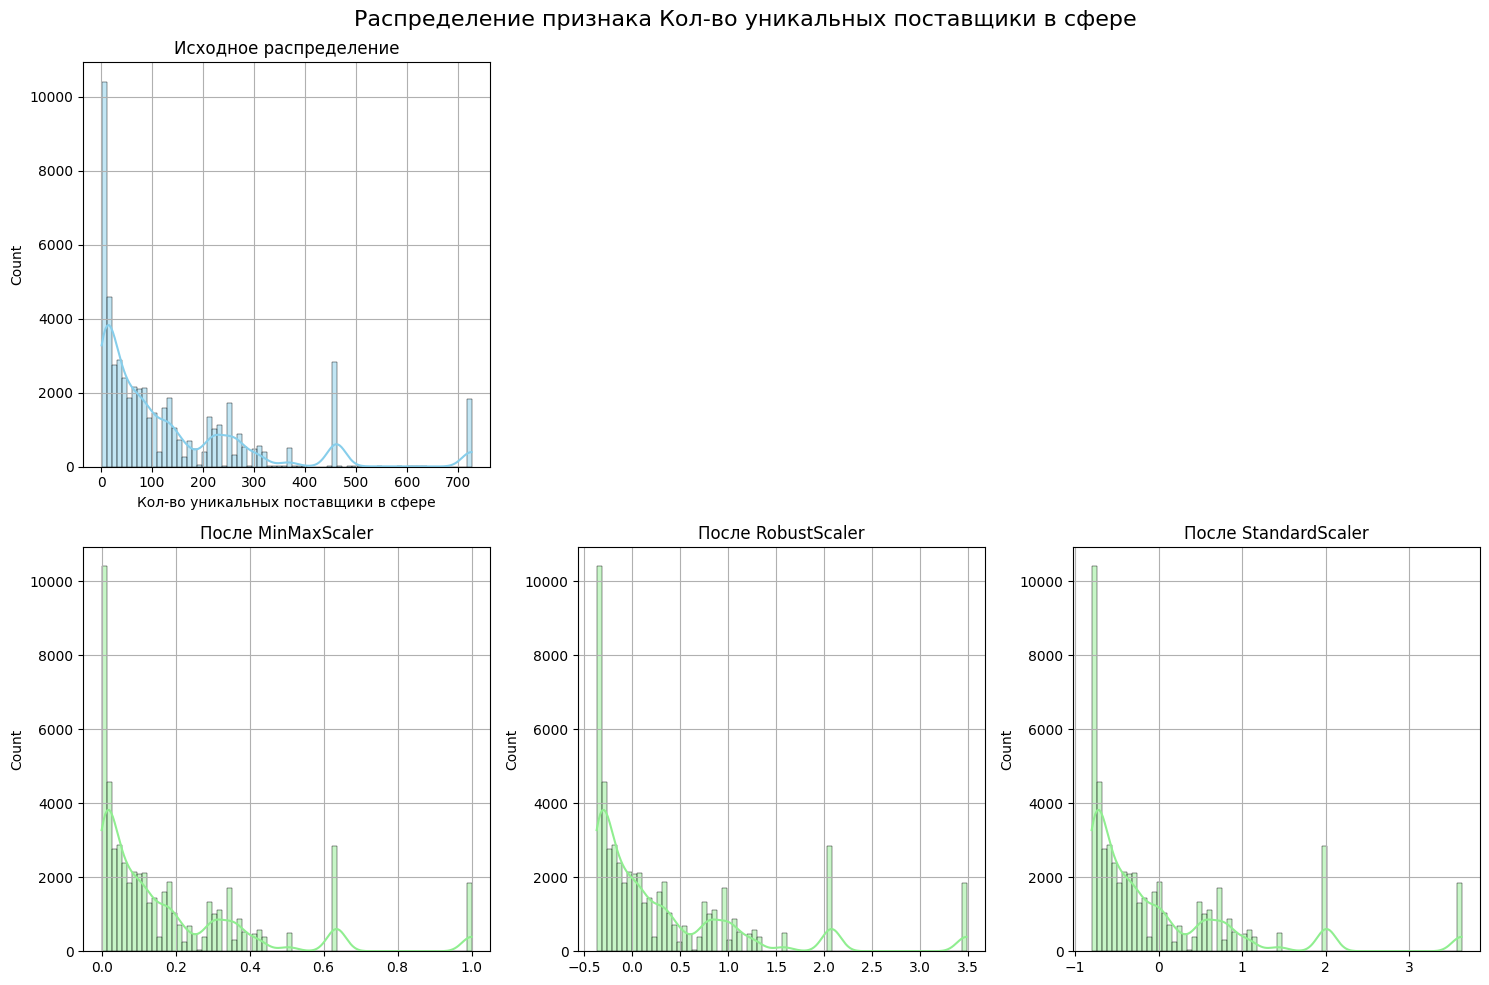


Анализ временных признаков:

Статистики для Длительность_приема_заявок:
Среднее: 7.22
Медиана: 7.00
Стд. отклонение: 6.54

Статистики после MinMaxScaler:
Среднее: 0.02
Медиана: 0.02
Стд. отклонение: 0.02
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 0.03
Медиана: 0.00
Стд. отклонение: 0.82
Min: -0.88
Max: 44.62

Статистики после StandardScaler:
Среднее: -0.00
Медиана: -0.03
Стд. отклонение: 1.00
Min: -1.10
Max: 54.57


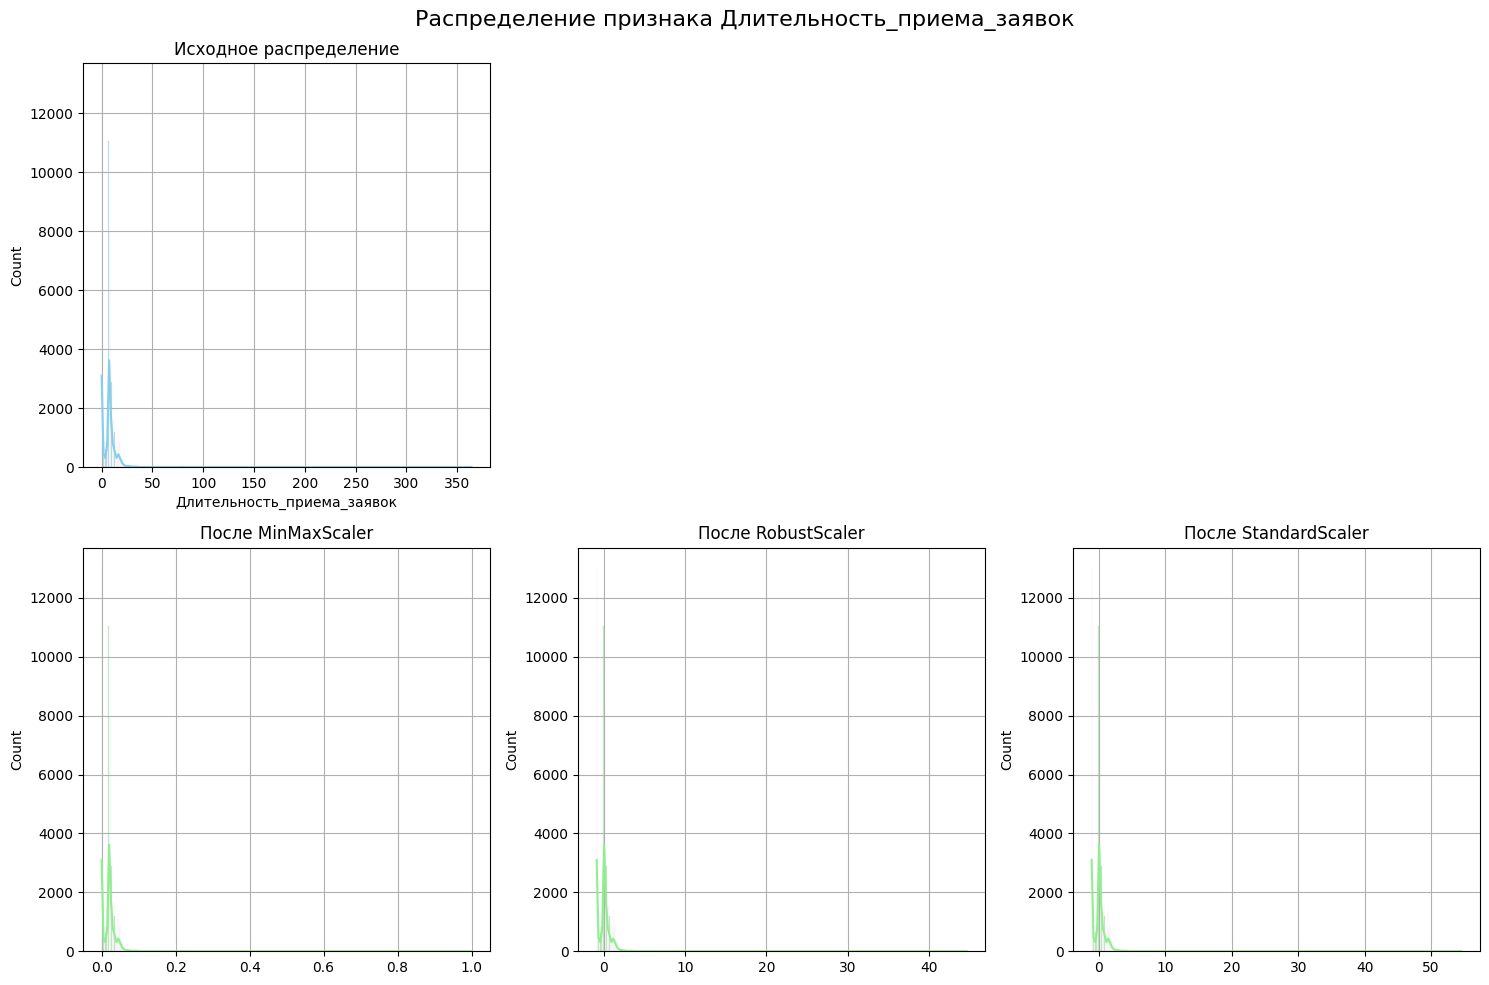


Статистики для Время_до_торгов:
Среднее: 11.29
Медиана: 8.00
Стд. отклонение: 14.16

Статистики после MinMaxScaler:
Среднее: 0.03
Медиана: 0.02
Стд. отклонение: 0.04
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: 0.33
Медиана: 0.00
Стд. отклонение: 1.42
Min: -0.80
Max: 38.10

Статистики после StandardScaler:
Среднее: 0.00
Медиана: -0.23
Стд. отклонение: 1.00
Min: -0.80
Max: 26.67


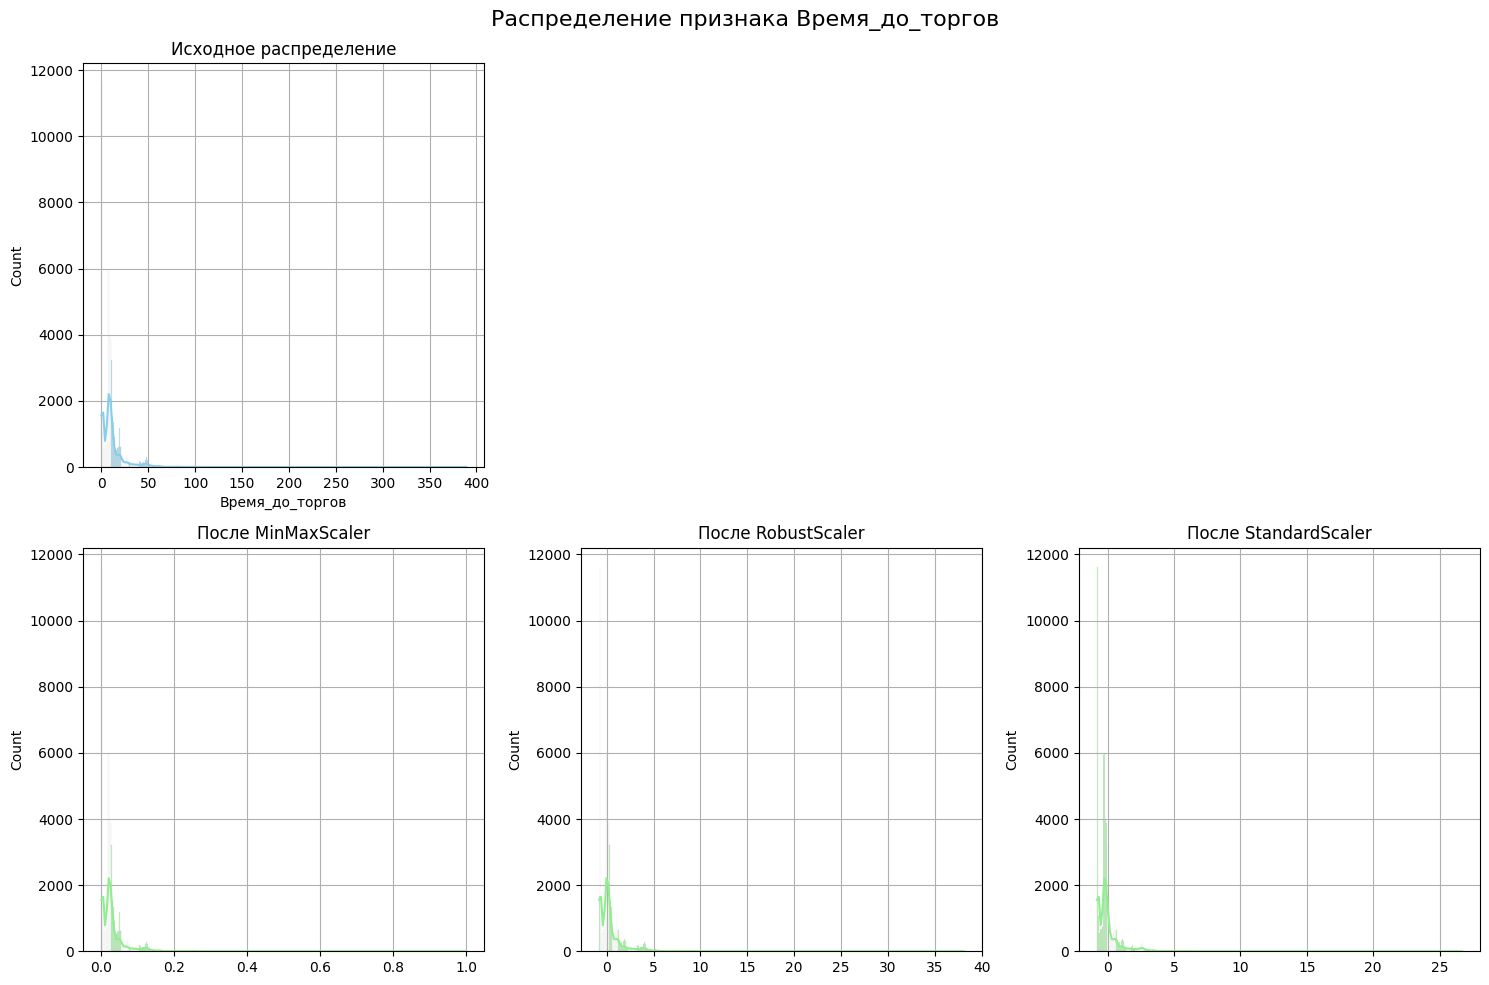


Статистики для Длительность тендера (дни):
Среднее: 6.85
Медиана: 7.00
Стд. отклонение: 7.58

Статистики после MinMaxScaler:
Среднее: 0.38
Медиана: 0.38
Стд. отклонение: 0.01
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: -0.02
Медиана: 0.00
Стд. отклонение: 0.95
Min: -29.88
Max: 48.12

Статистики после StandardScaler:
Среднее: -0.00
Медиана: 0.02
Стд. отклонение: 1.00
Min: -31.53
Max: 50.83


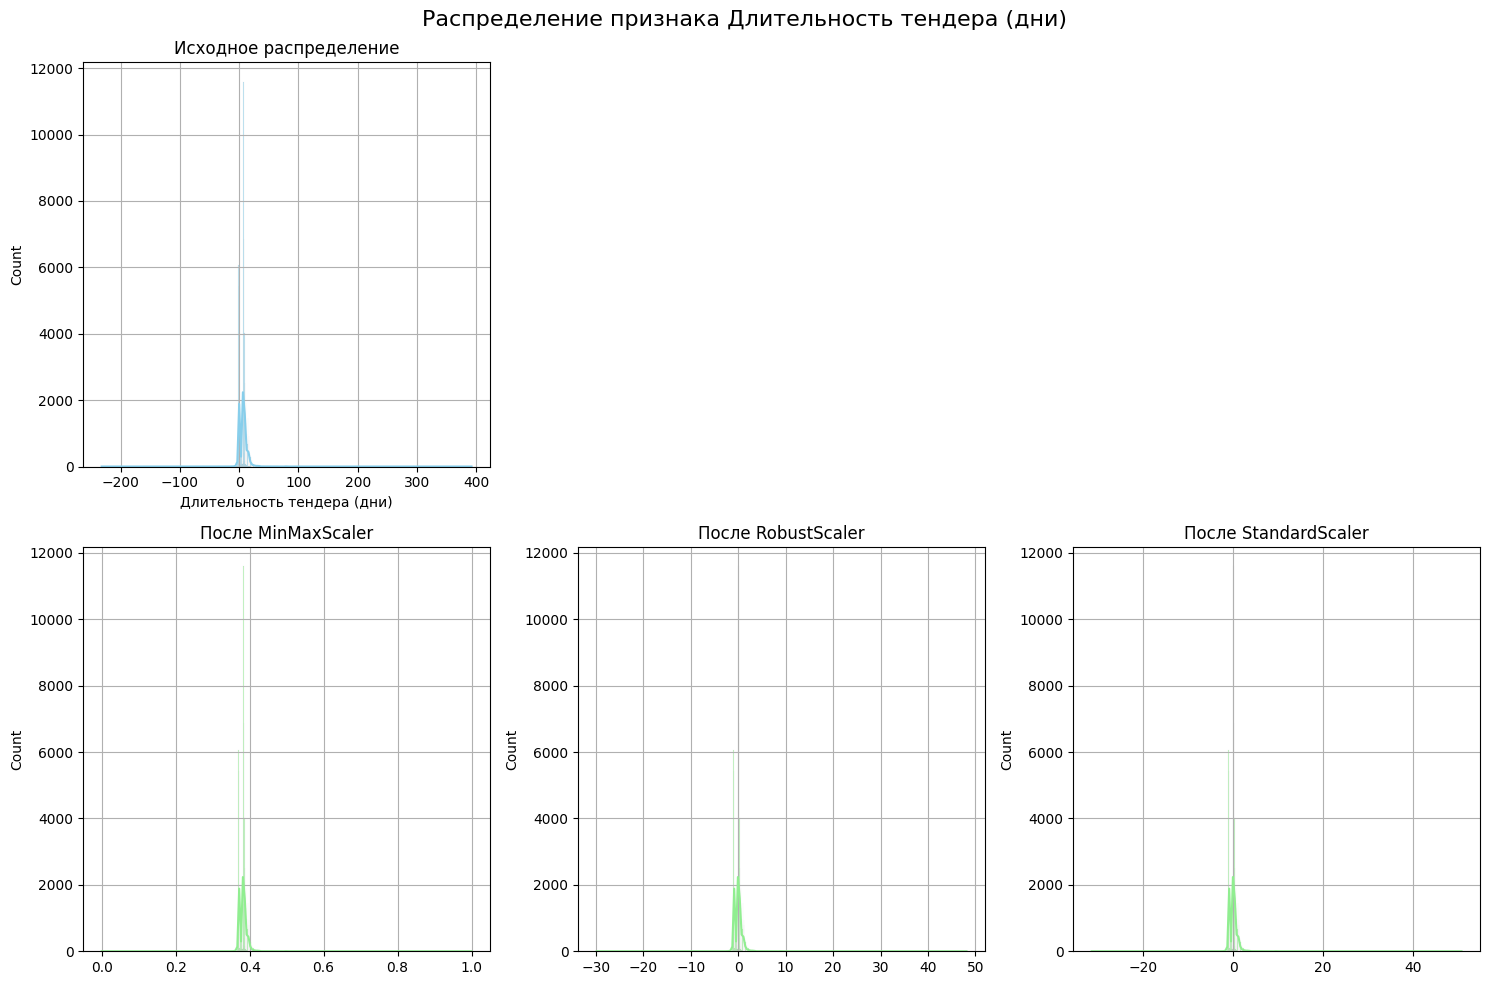


Анализ стоимости:

Статистики для Стоимость(руб.) Заказчик:
Среднее: 13.91
Медиана: 14.00
Стд. отклонение: 1.80

Статистики после MinMaxScaler:
Среднее: 0.53
Медиана: 0.54
Стд. отклонение: 0.08
Min: 0.00
Max: 1.00

Статистики после RobustScaler:
Среднее: -0.03
Медиана: 0.00
Стд. отклонение: 0.58
Min: -3.88
Max: 3.35

Статистики после StandardScaler:
Среднее: 0.00
Медиана: 0.05
Стд. отклонение: 1.00
Min: -6.65
Max: 5.83


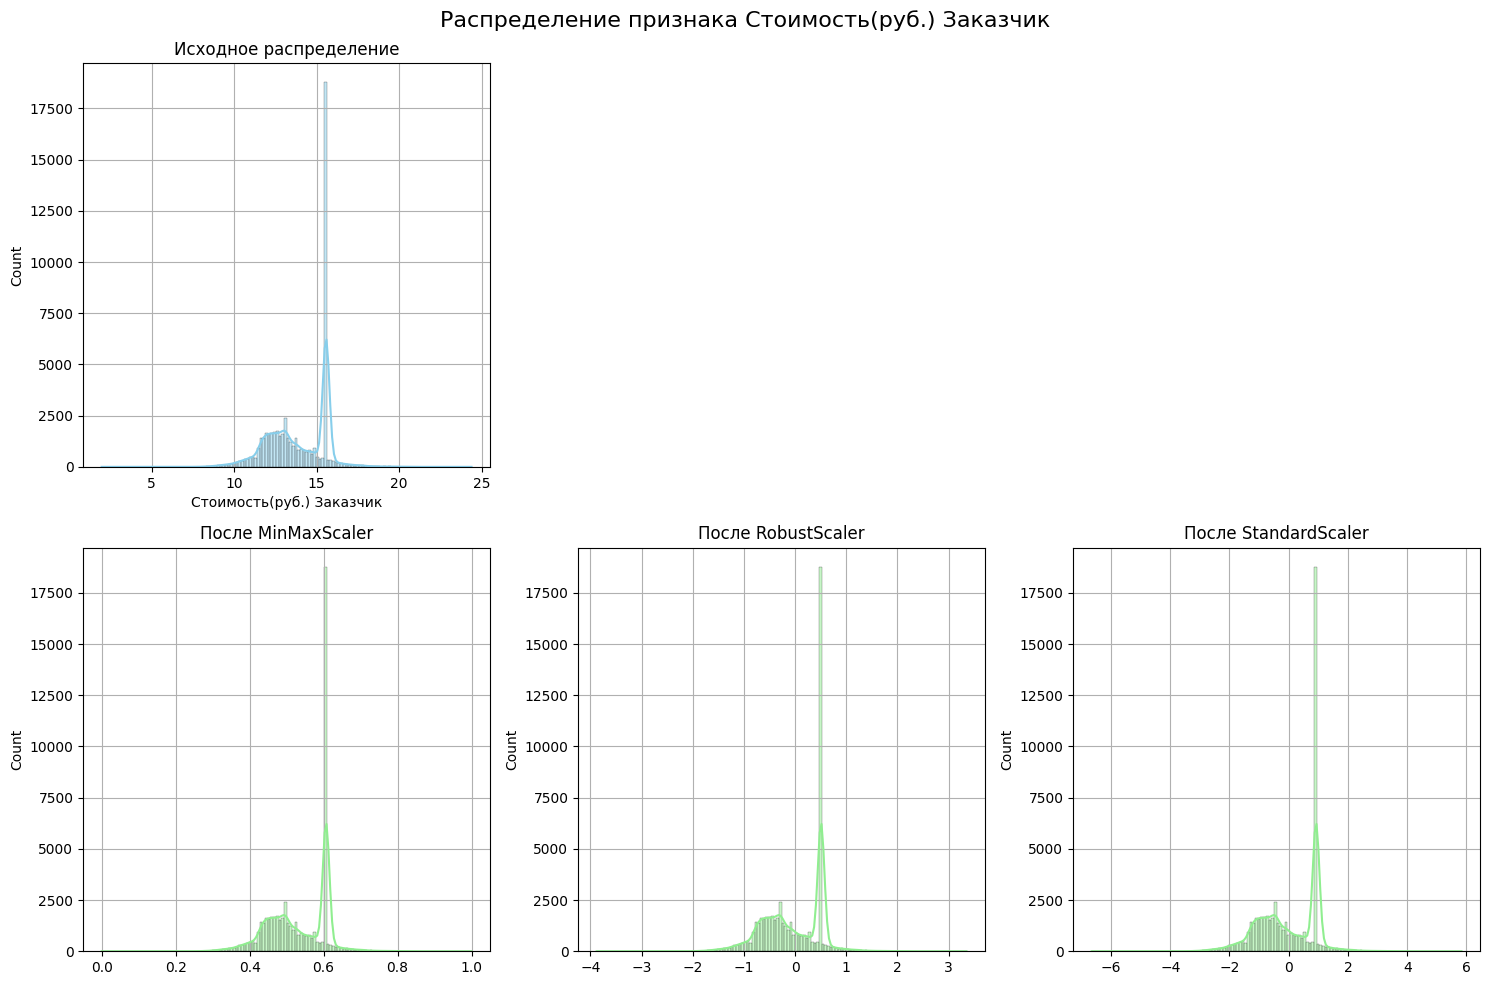

In [28]:
def format_number(x):
    if abs(x) < 0.01 or abs(x) > 1e6:
        return f"{x:.2f}"
    return f"{x:.2f}"

def analyze_feature_distribution(df, feature, scalers):
    data = df[feature].dropna()

    print(f"\nСтатистики для {feature}:")
    print(f"Среднее: {format_number(data.mean())}")
    print(f"Медиана: {format_number(data.median())}")
    print(f"Стд. отклонение: {format_number(data.std())}")

    fig, axes = plt.subplots(nrows=2, ncols=len(scalers), figsize=(15, 10))
    plt.suptitle(f'Распределение признака {feature}', fontsize=16)
    
    sns.histplot(data, kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Исходное распределение')
    axes[0, 0].grid(True)
    
    for idx in range(1, len(scalers)):
        axes[0, idx].axis('off')
    
    for idx, (name, scaler) in enumerate(scalers.items()):
        scaled_data = scaler.fit_transform(data.values.reshape(-1, 1)).ravel()
        sns.histplot(scaled_data, kde=True, ax=axes[1, idx], color='lightgreen')
        axes[1, idx].set_title(f'После {name}')
        axes[1, idx].grid(True)

        print(f"\nСтатистики после {name}:")
        print(f"Среднее: {format_number(np.mean(scaled_data))}")
        print(f"Медиана: {format_number(np.median(scaled_data))}")
        print(f"Стд. отклонение: {format_number(np.std(scaled_data))}")
        print(f"Min: {format_number(np.min(scaled_data))}")
        print(f"Max: {format_number(np.max(scaled_data))}")
    
    plt.tight_layout()
    plt.show()

percent_features = [
    'Процент побед', 'Процент побед по региону',
    'Процент побед по заказчику', 'Процент побед по сфере'
]

count_features = [
    'Кол-во побед по региону', 'Кол-во побед по заказчику',
    'Кол-во побед по сфере', 'Общее кол-во участий',
    'Общее кол-во побед', 'Кол-во конкурентов в тендере',
    'Среднее кол-во конкурентов в регионе', 'Среднее кол-во конкурентов в сфере',
    'Кол-во уникальных поставщики в регионе', 'Кол-во уникальных поставщики в сфере'
]

duration_features = [
    'Длительность_приема_заявок', 'Время_до_торгов',
    'Длительность тендера (дни)'
]

cost_features = ['Стоимость(руб.) Заказчик']

scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler()
}

print("Анализ процентных признаков:")
for feature in percent_features:
    analyze_feature_distribution(df, feature, scalers)

print("\nАнализ количественных признаков:")
for feature in count_features:
    analyze_feature_distribution(df, feature, scalers)

print("\nАнализ временных признаков:")
for feature in duration_features:
    analyze_feature_distribution(df, feature, scalers)

print("\nАнализ стоимости:")
for feature in cost_features:
    analyze_feature_distribution(df, feature, scalers)

Все процентные признаки уже имеют значение от 0 до 1, их можно оставить без шкалирования, данные уже нормализованы 

Для различных количеств побед и участий наблюдаются сильно скошенные распрделения, много выбросов, поэтому лучше всего использовать RobustScaler - он как раз устойчив к ним, для борьбы с асимметрией лучше всего подойдет медианное центрирование и масштабирование по квартилям. Количество конкурентов тоже везде скошено, а именно вправо, есть пики, длинные хвосты - тоже применяем RobustScaler

Для всех временных признаков тоже подойдет RobustScaler лучше всего: у всех длинный правый хвост, несколько пиков в распределении, не похоже на нормальное, чтобы можно было использовать StandartScaler

Стоимость - cильно скошенное распределение, есть очень большие выбросы и очень большая разница в значениях, поэтому np.log1p() + StandardScaler: логарифмическое преобразование сделает распределение более симметричным, а StandardScaler приведет к нужному масштабу

___


Посмотрим, что происходит с выбросами, а также как меняется распределение значений признаков при обработке выбросов, будем использовать IQR, он более устойчив к эстремальным выбросам, не предполагает нормальность распределения (наш случай), использует более робастные оценки


Распределения в целом получились не сильно сбалансированными. Так, процент побед имеет сильные пики около 0 и 1, как и в целом другие проценты, но выбросов здесь нет, что логично для процентных значений

По количествам видно много выбросов, поэтому после их обработки диапазон значений сильно уменьшается (например, с 500 до 14 для количества побед по региону). Теперь лучше видно структуру распределения

Для стоимости видны очень сильные выбросы. Медиана смещена к нижней границе - очень много небольших значений и немного очень больших, после обработки выбросов структура прослеживается намного четче


Статистики для признака Процент побед:

До обработки (тренировочная выборка):
Среднее: 0.59
Медиана: 0.67
Стд. отклонение: 0.42
Min: 0.00
Max: 1.00

После обработки:
Среднее: 0.59
Медиана: 0.67
Стд. отклонение: 0.42
Min: 0.00
Max: 1.00

Процент выбросов в тренировочной выборке: 0.00%


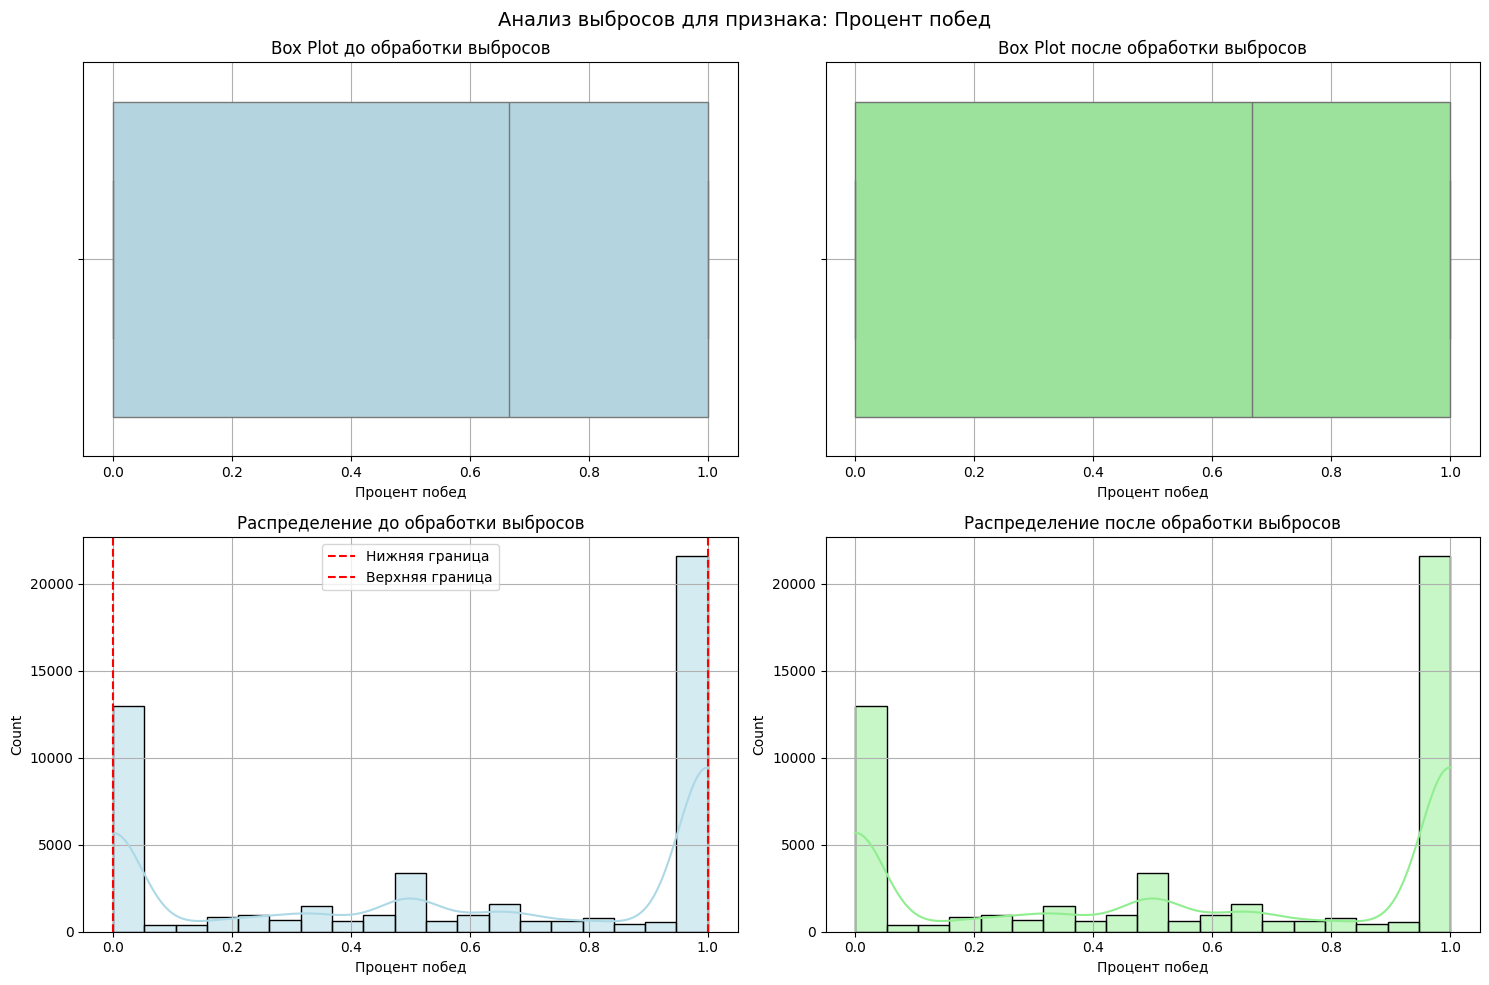


Статистики для признака Кол-во побед по региону:

До обработки (тренировочная выборка):
Среднее: 7.98
Медиана: 1.00
Стд. отклонение: 28.87
Min: 0.00
Max: 290.00

После обработки:
Среднее: 6.67
Медиана: 1.00
Стд. отклонение: 19.24
Min: 0.00
Max: 110.00

Процент выбросов в тренировочной выборке: 1.64%


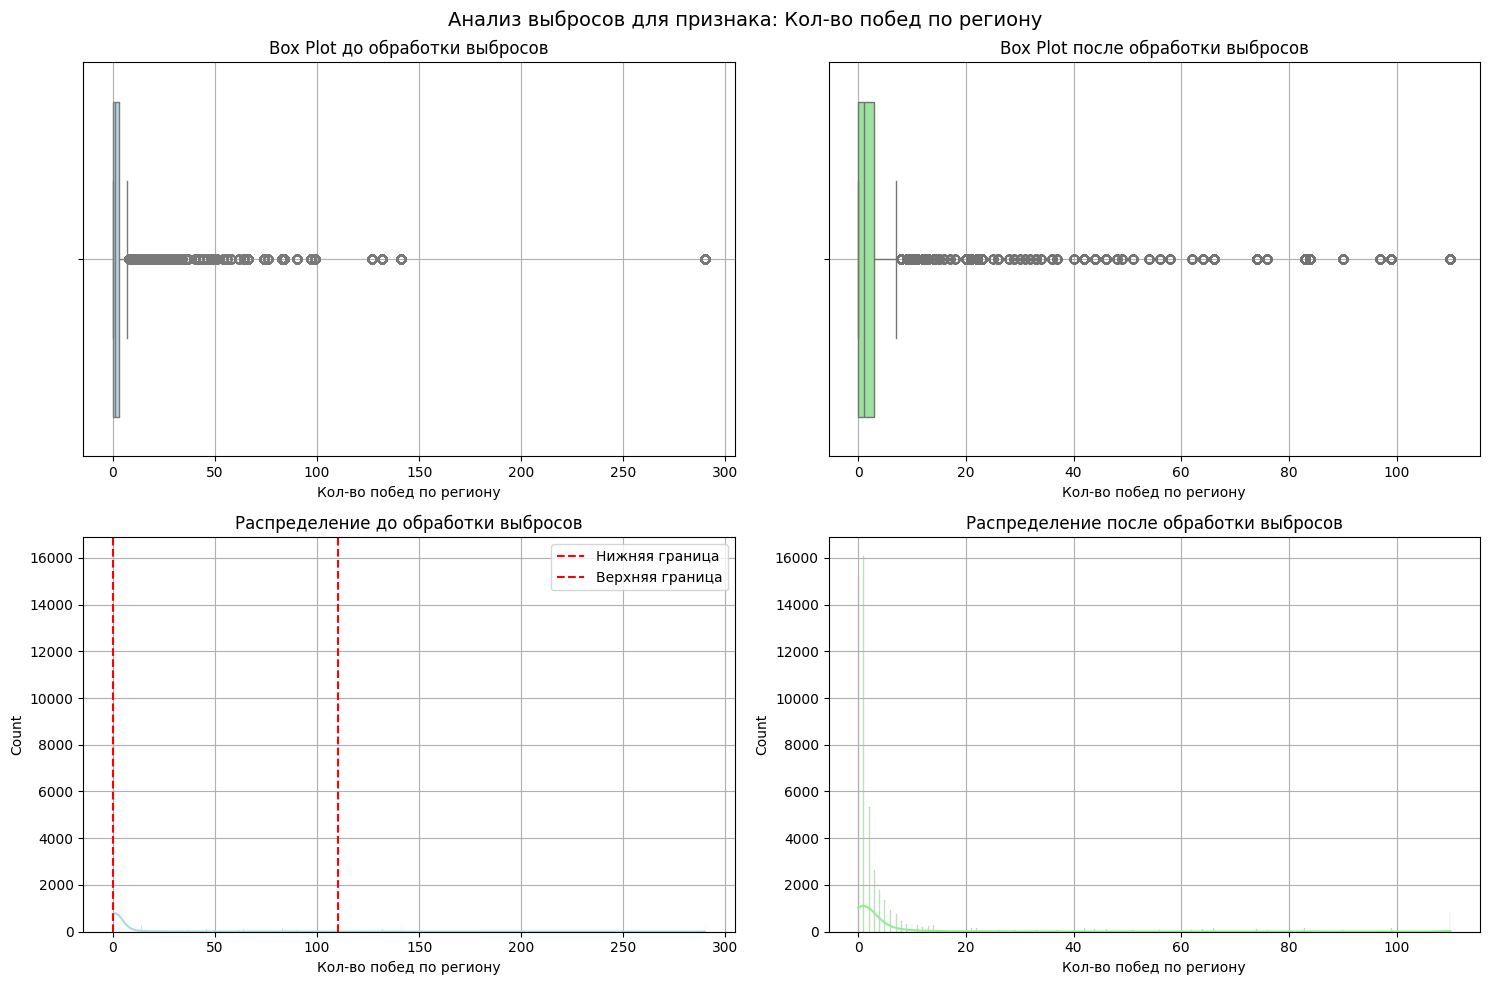


Статистики для признака Процент побед по региону:

До обработки (тренировочная выборка):
Среднее: 0.59
Медиана: 0.75
Стд. отклонение: 0.44
Min: 0.00
Max: 1.00

После обработки:
Среднее: 0.59
Медиана: 0.75
Стд. отклонение: 0.44
Min: 0.00
Max: 1.00

Процент выбросов в тренировочной выборке: 0.00%


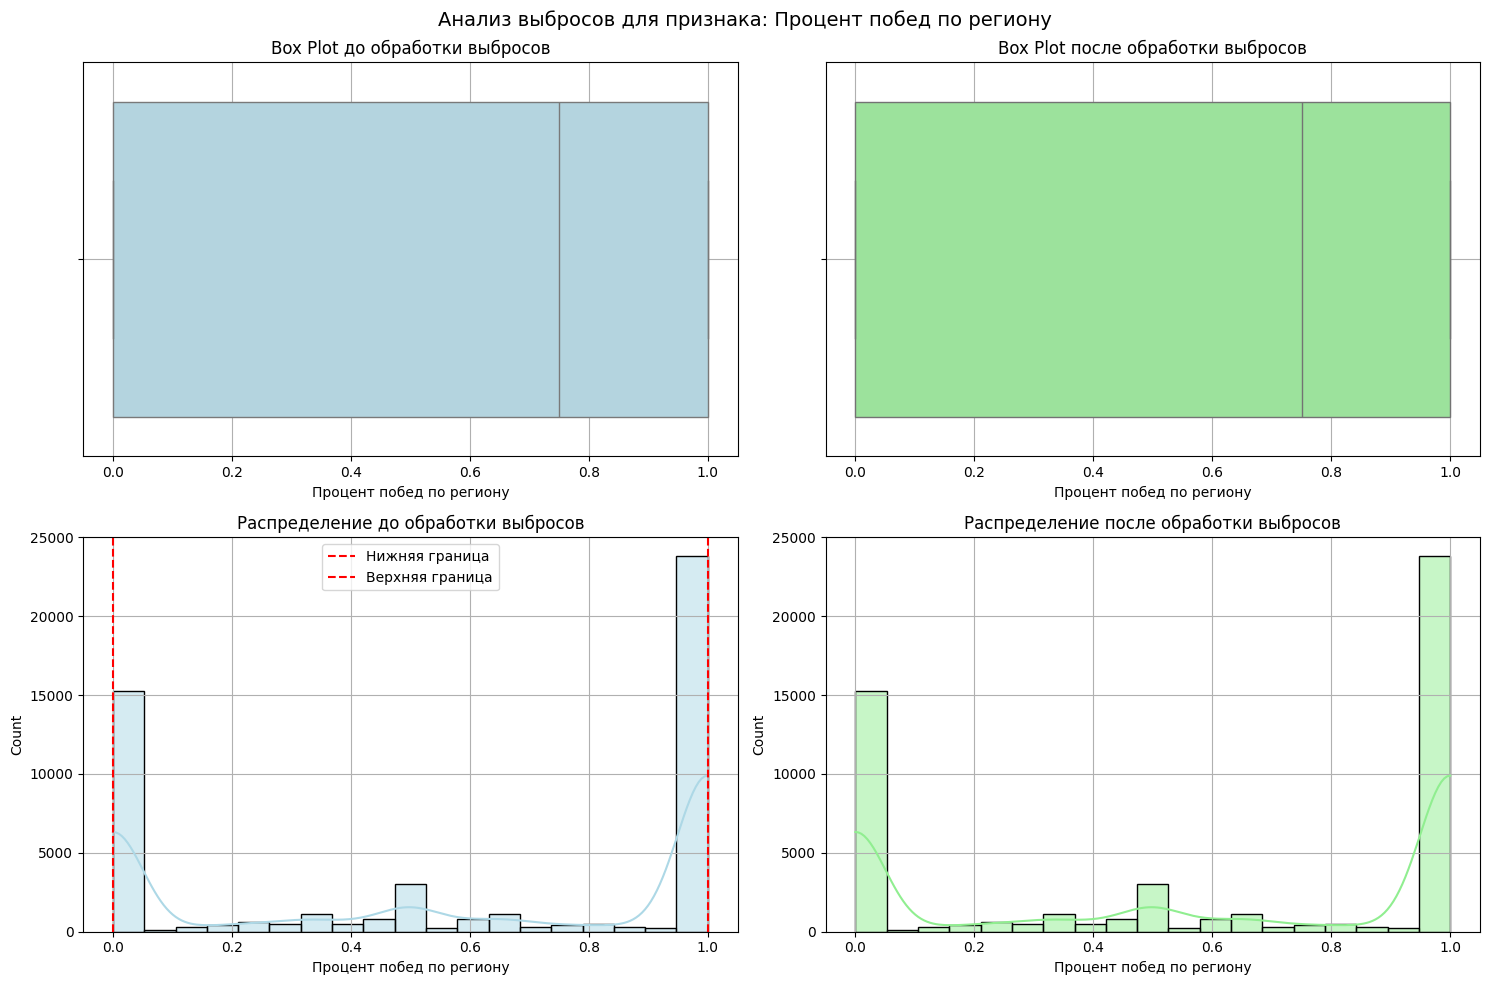


Статистики для признака Кол-во побед по заказчику:

До обработки (тренировочная выборка):
Среднее: 7.76
Медиана: 1.00
Стд. отклонение: 29.47
Min: 0.00
Max: 292.00

После обработки:
Среднее: 6.39
Медиана: 1.00
Стд. отклонение: 19.63
Min: 0.00
Max: 110.00

Процент выбросов в тренировочной выборке: 1.67%


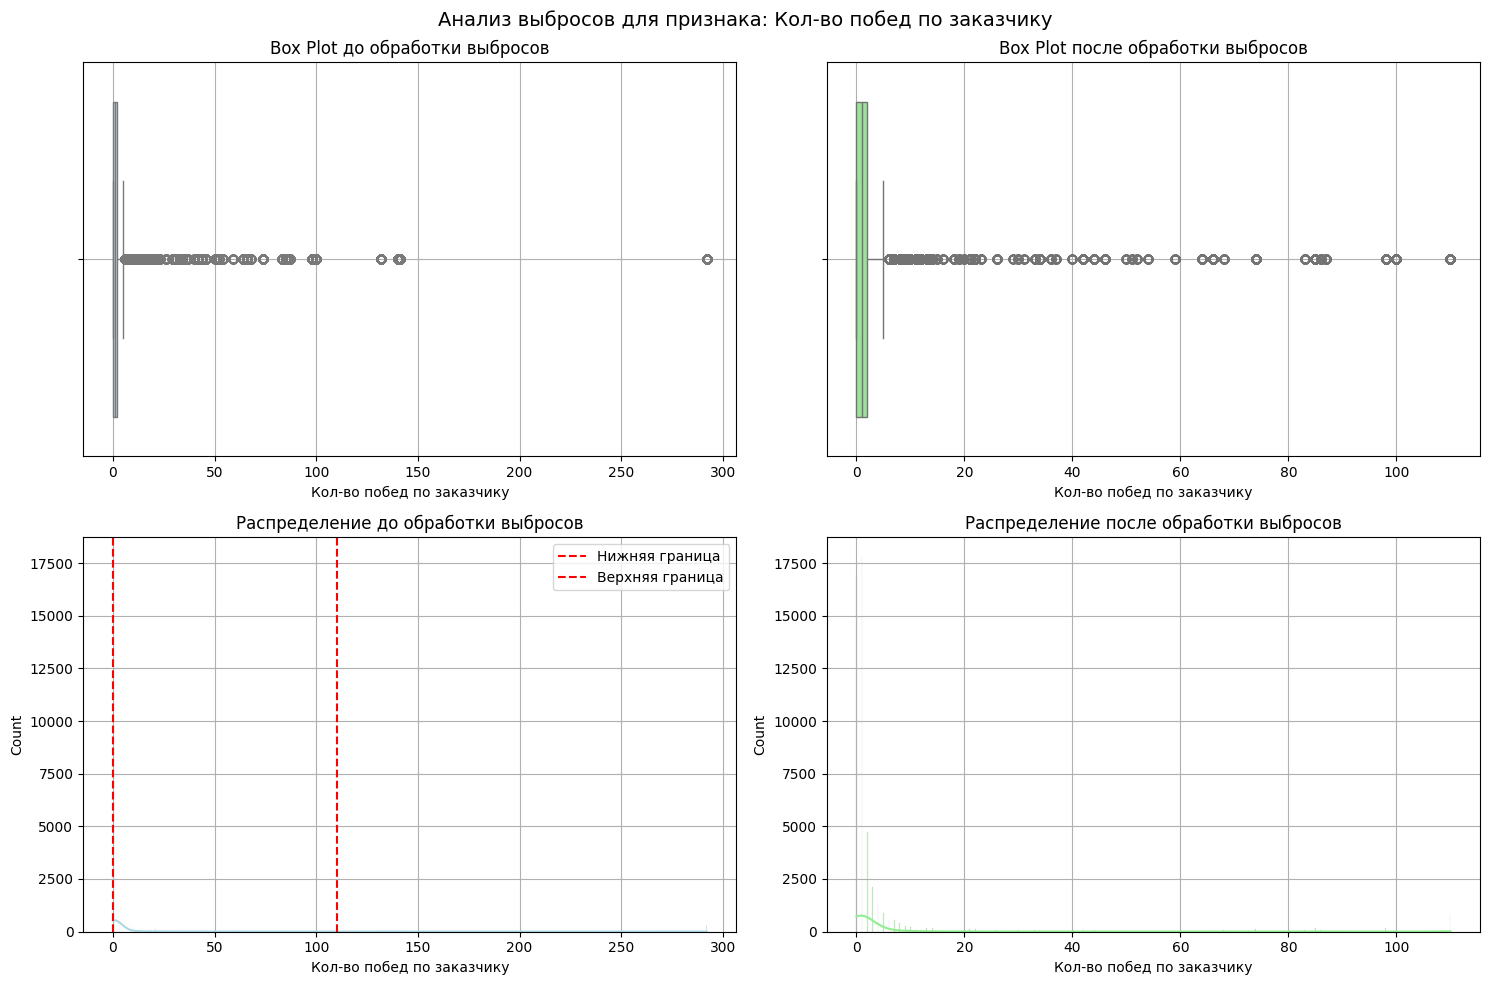


Статистики для признака Процент побед по заказчику:

До обработки (тренировочная выборка):
Среднее: 0.59
Медиана: 1.00
Стд. отклонение: 0.46
Min: 0.00
Max: 1.00

После обработки:
Среднее: 0.59
Медиана: 1.00
Стд. отклонение: 0.46
Min: 0.00
Max: 1.00

Процент выбросов в тренировочной выборке: 0.00%


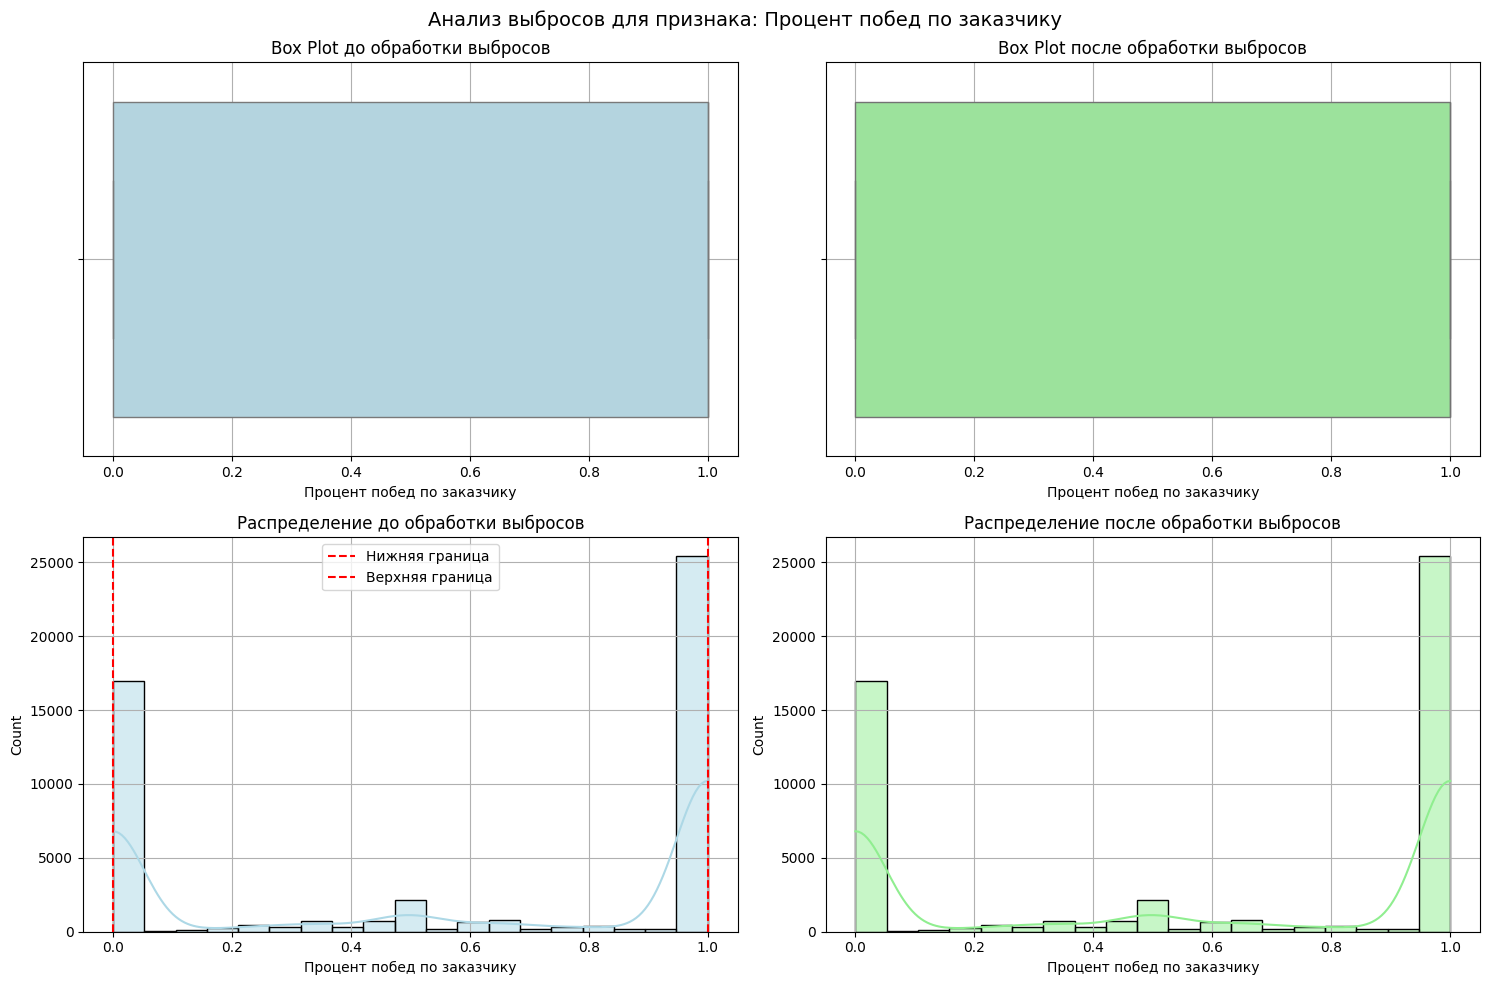


Статистики для признака Кол-во побед по сфере:

До обработки (тренировочная выборка):
Среднее: 6.85
Медиана: 1.00
Стд. отклонение: 27.36
Min: 0.00
Max: 292.00

После обработки:
Среднее: 5.40
Медиана: 1.00
Стд. отклонение: 16.02
Min: 0.00
Max: 90.00

Процент выбросов в тренировочной выборке: 1.51%


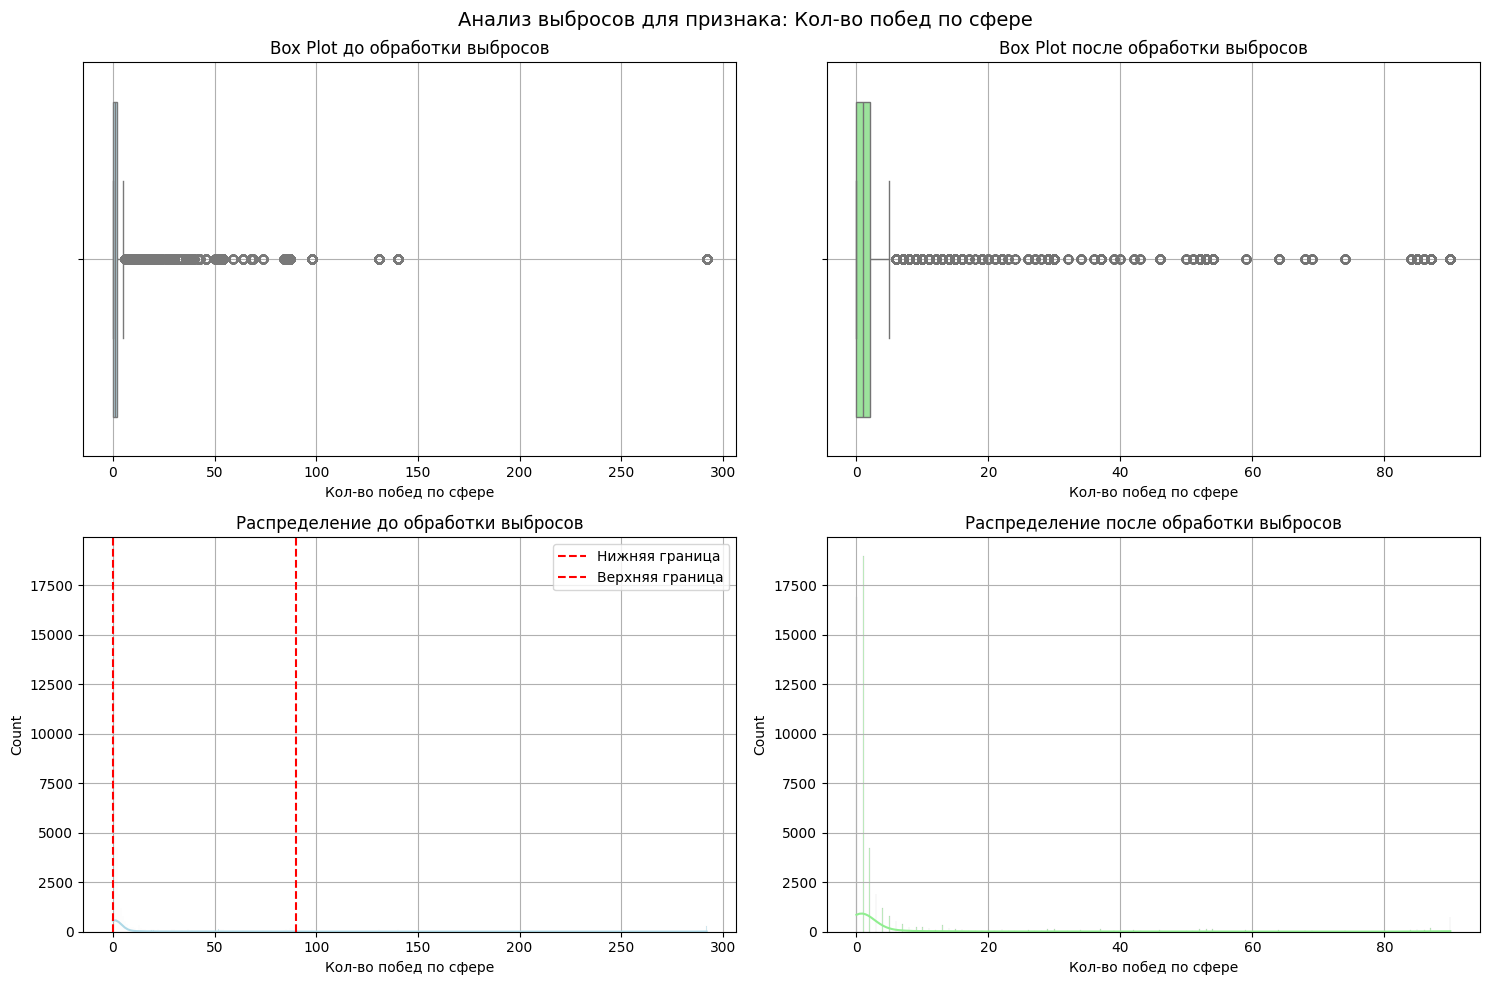


Статистики для признака Процент побед по сфере:

До обработки (тренировочная выборка):
Среднее: 0.59
Медиана: 1.00
Стд. отклонение: 0.46
Min: 0.00
Max: 1.00

После обработки:
Среднее: 0.59
Медиана: 1.00
Стд. отклонение: 0.46
Min: 0.00
Max: 1.00

Процент выбросов в тренировочной выборке: 0.00%


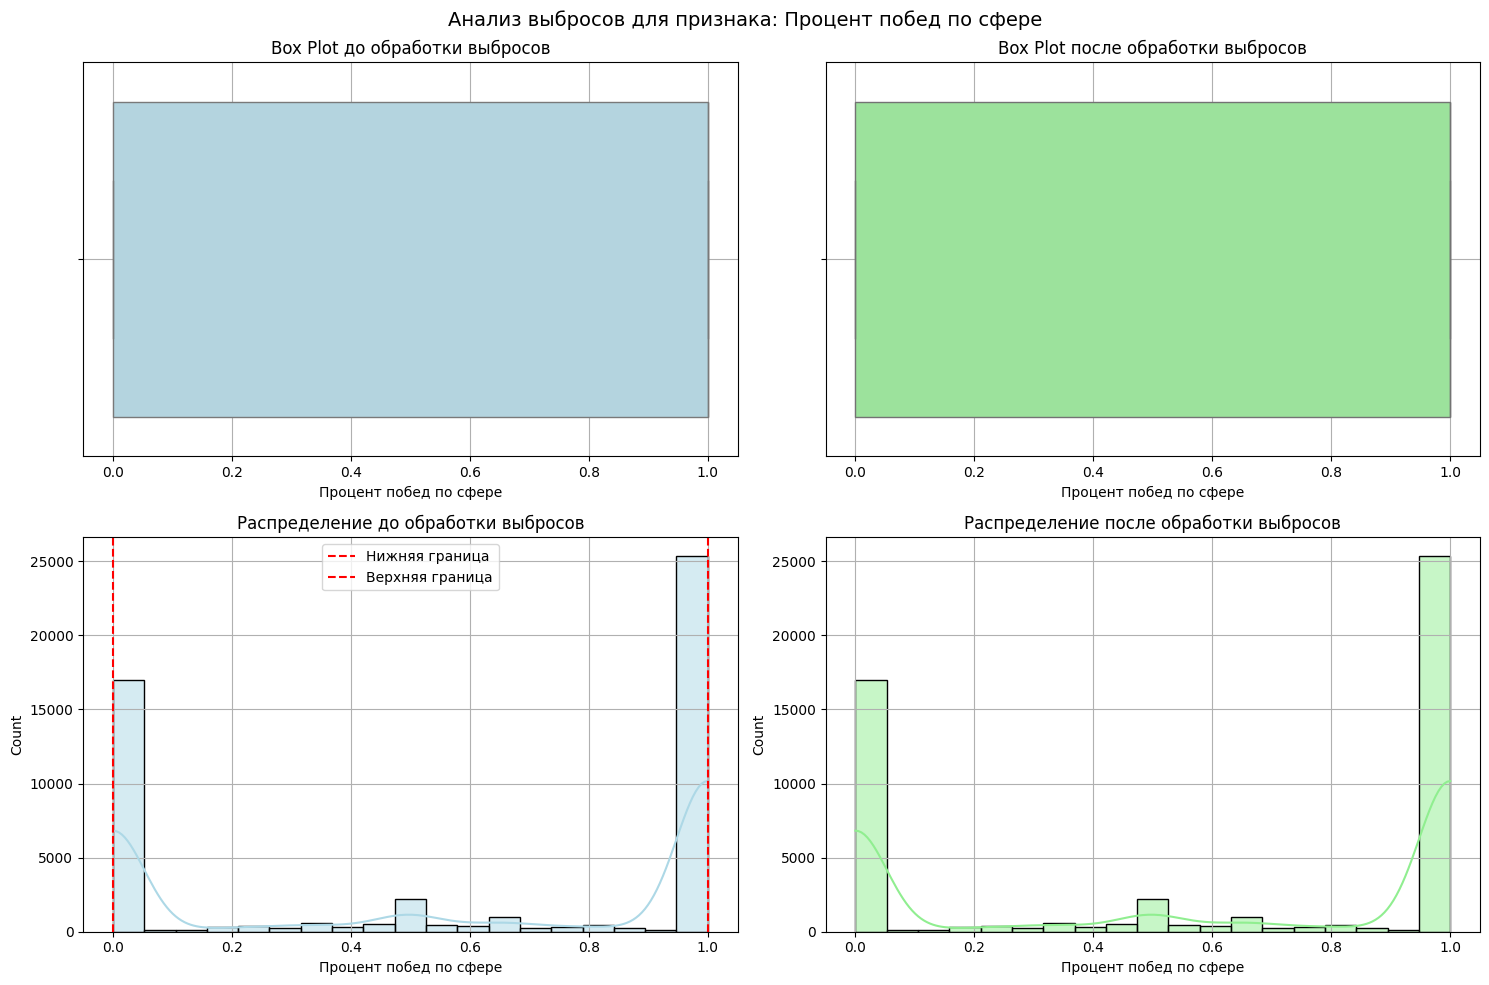


Статистики для признака Общее кол-во участий:

До обработки (тренировочная выборка):
Среднее: 14.70
Медиана: 2.00
Стд. отклонение: 39.45
Min: 1.00
Max: 292.00

После обработки:
Среднее: 13.94
Медиана: 2.00
Стд. отклонение: 34.58
Min: 1.00
Max: 216.00

Процент выбросов в тренировочной выборке: 1.13%


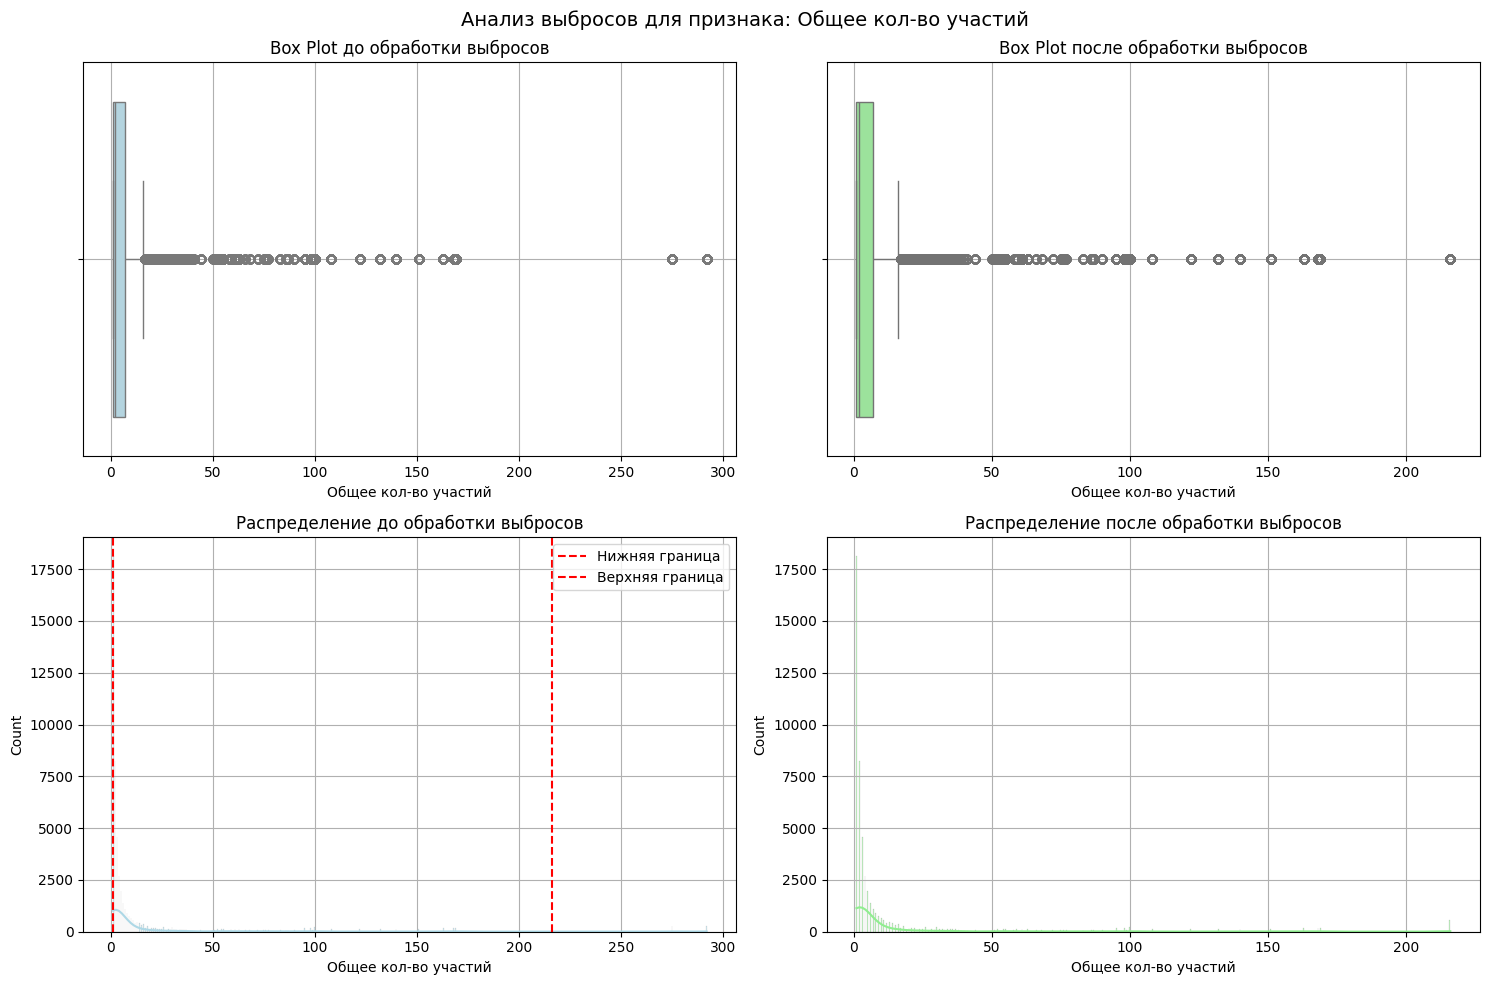


Статистики для признака Общее кол-во побед:

До обработки (тренировочная выборка):
Среднее: 10.11
Медиана: 1.00
Стд. отклонение: 31.54
Min: 0.00
Max: 292.00

После обработки:
Среднее: 9.34
Медиана: 1.00
Стд. отклонение: 25.75
Min: 0.00
Max: 160.00

Процент выбросов в тренировочной выборке: 0.58%


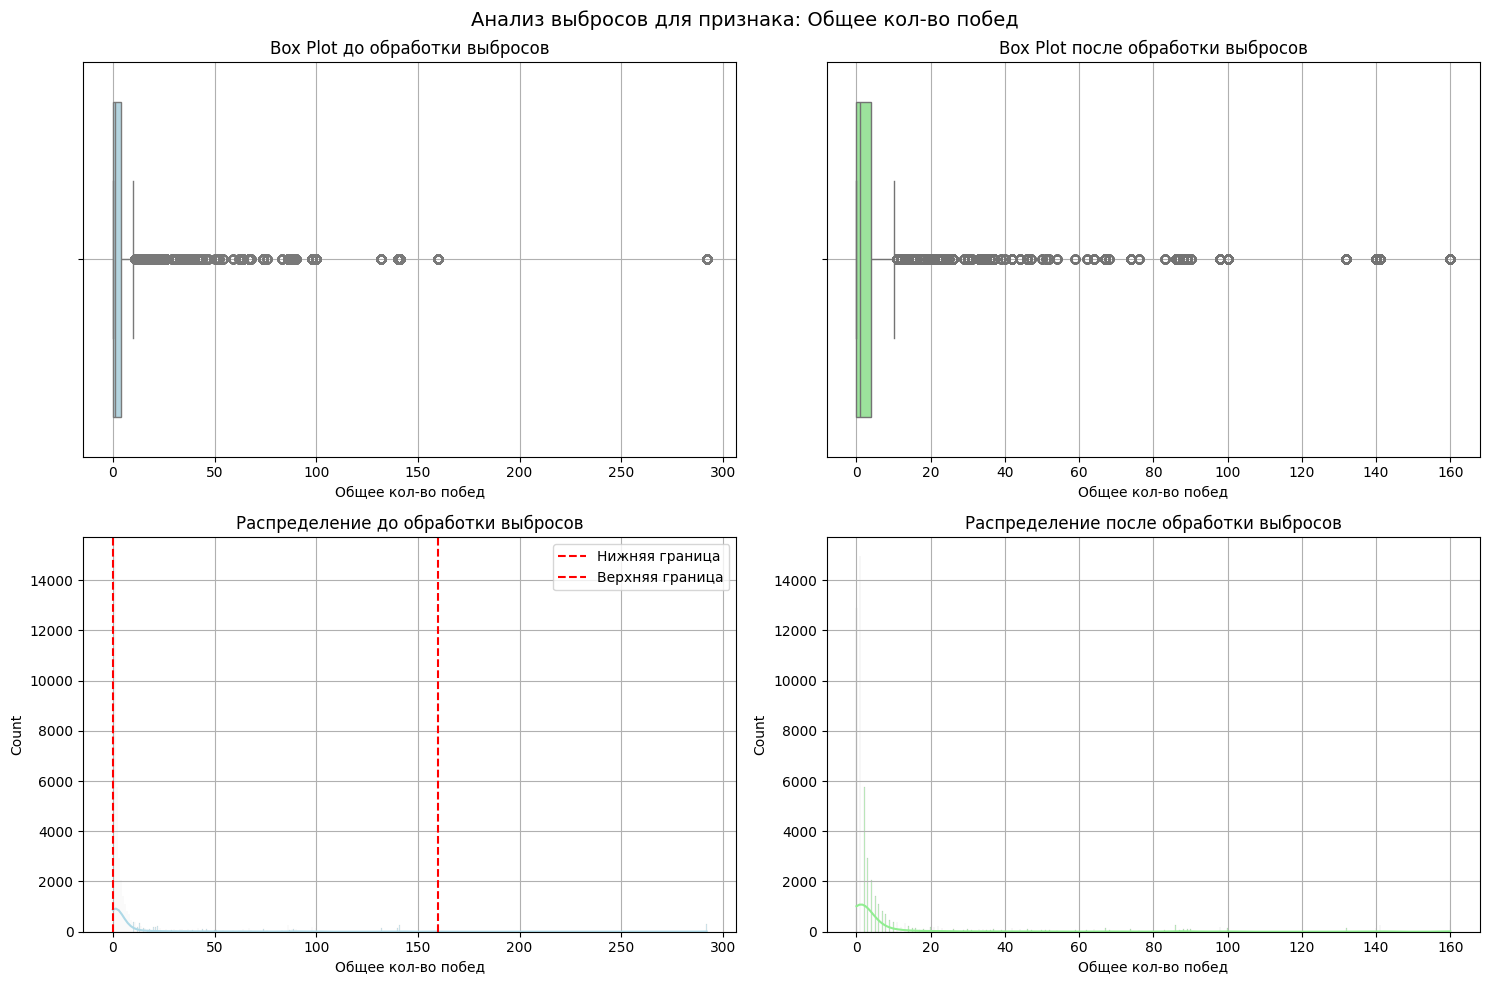


Статистики для признака Стоимость(руб.) Заказчик:

До обработки (тренировочная выборка):
Среднее: 13.87
Медиана: 13.92
Стд. отклонение: 1.81
Min: 1.97
Max: 24.39

После обработки:
Среднее: 13.87
Медиана: 13.92
Стд. отклонение: 1.81
Min: 3.88
Max: 22.59

Процент выбросов в тренировочной выборке: 0.01%


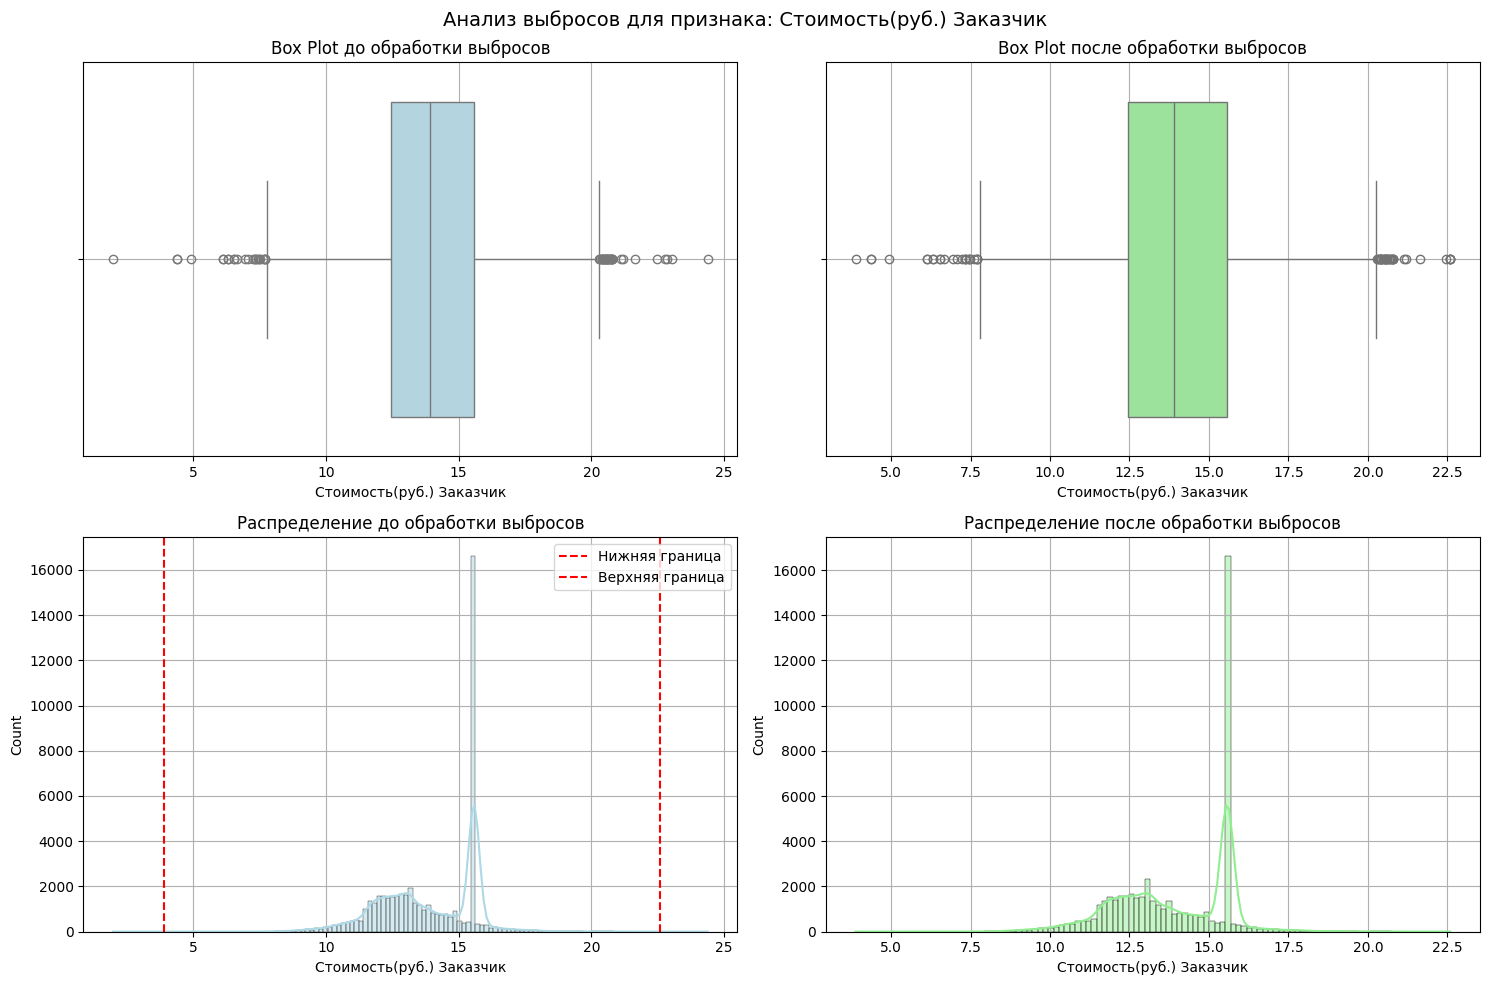


Статистики для признака Длительность_приема_заявок:

До обработки (тренировочная выборка):
Среднее: 7.45
Медиана: 7.00
Стд. отклонение: 6.59
Min: 0.00
Max: 364.00

После обработки:
Среднее: 7.40
Медиана: 7.00
Стд. отклонение: 6.01
Min: 0.00
Max: 45.00

Процент выбросов в тренировочной выборке: 0.23%


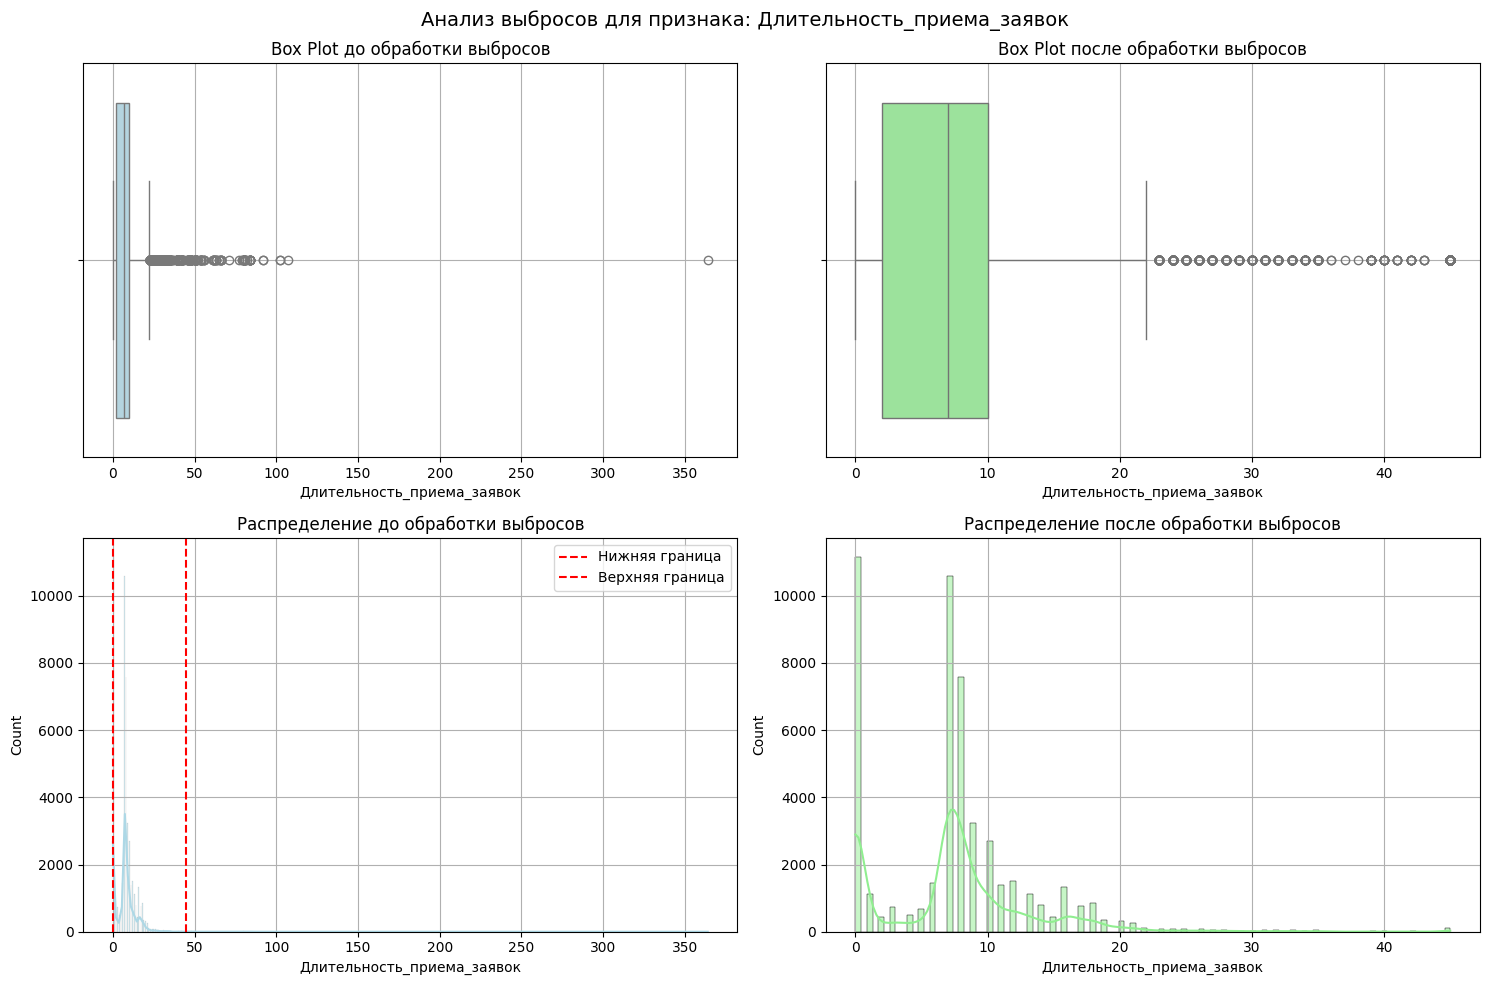


Статистики для признака Время_до_торгов:

До обработки (тренировочная выборка):
Среднее: 11.41
Медиана: 8.00
Стд. отклонение: 14.07
Min: 0.00
Max: 389.00

После обработки:
Среднее: 11.30
Медиана: 8.00
Стд. отклонение: 12.57
Min: 0.00
Max: 96.00

Процент выбросов в тренировочной выборке: 0.19%


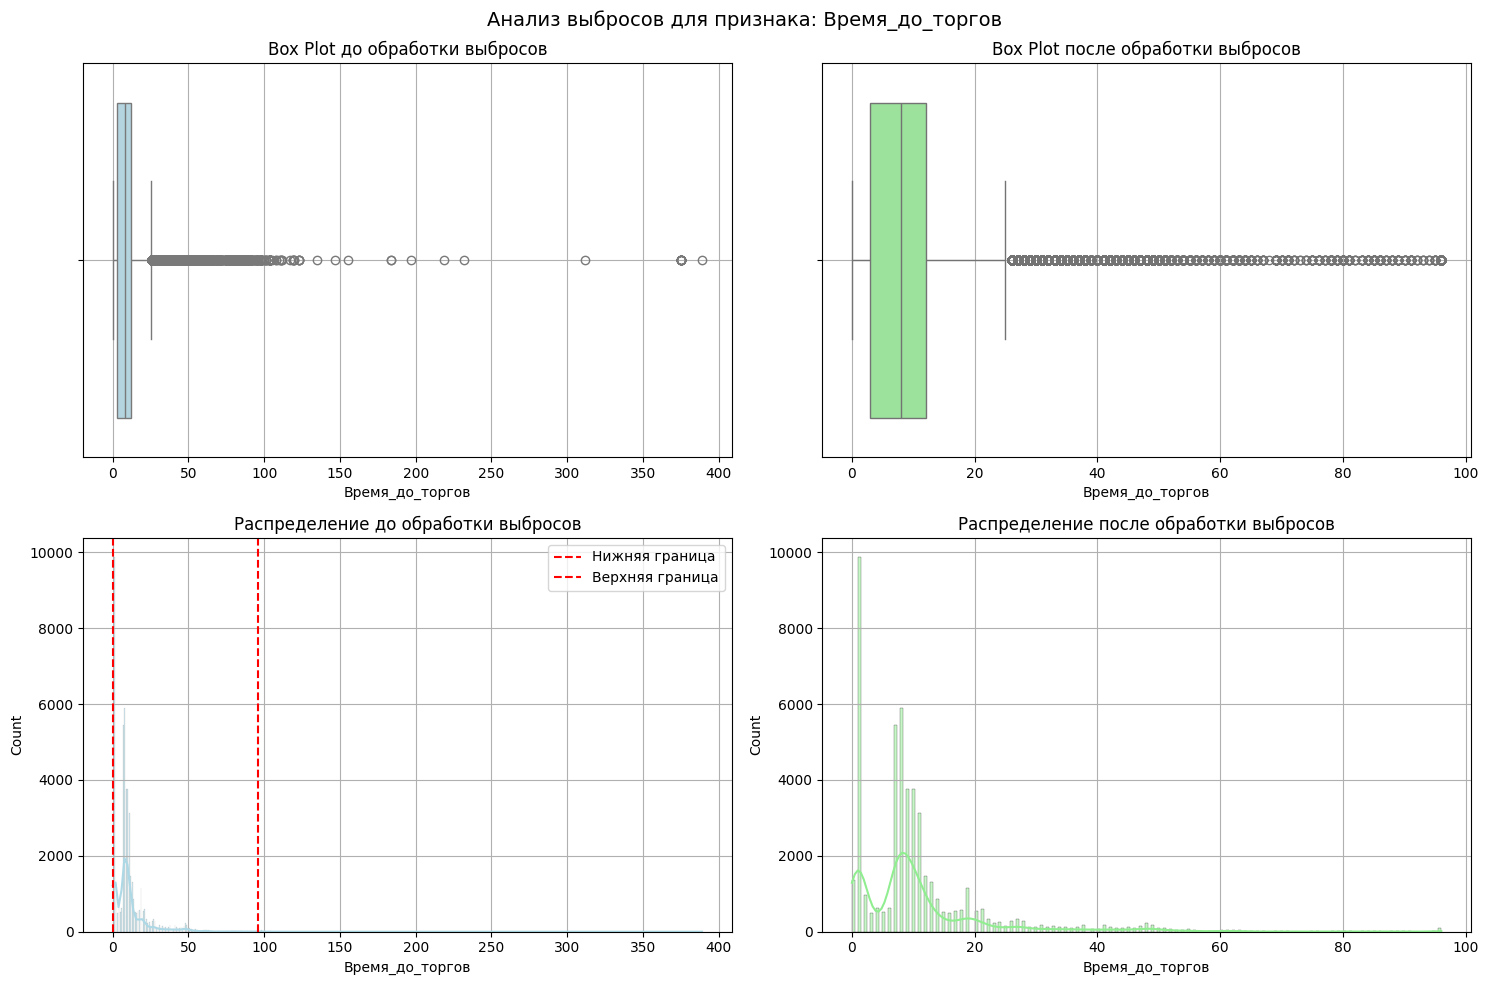


Статистики для признака Кол-во конкурентов в тендере:

До обработки (тренировочная выборка):
Среднее: 5.57
Медиана: 1.00
Стд. отклонение: 13.58
Min: 0.00
Max: 142.00

После обработки:
Среднее: 5.28
Медиана: 1.00
Стд. отклонение: 11.41
Min: 0.00
Max: 70.00

Процент выбросов в тренировочной выборке: 1.09%


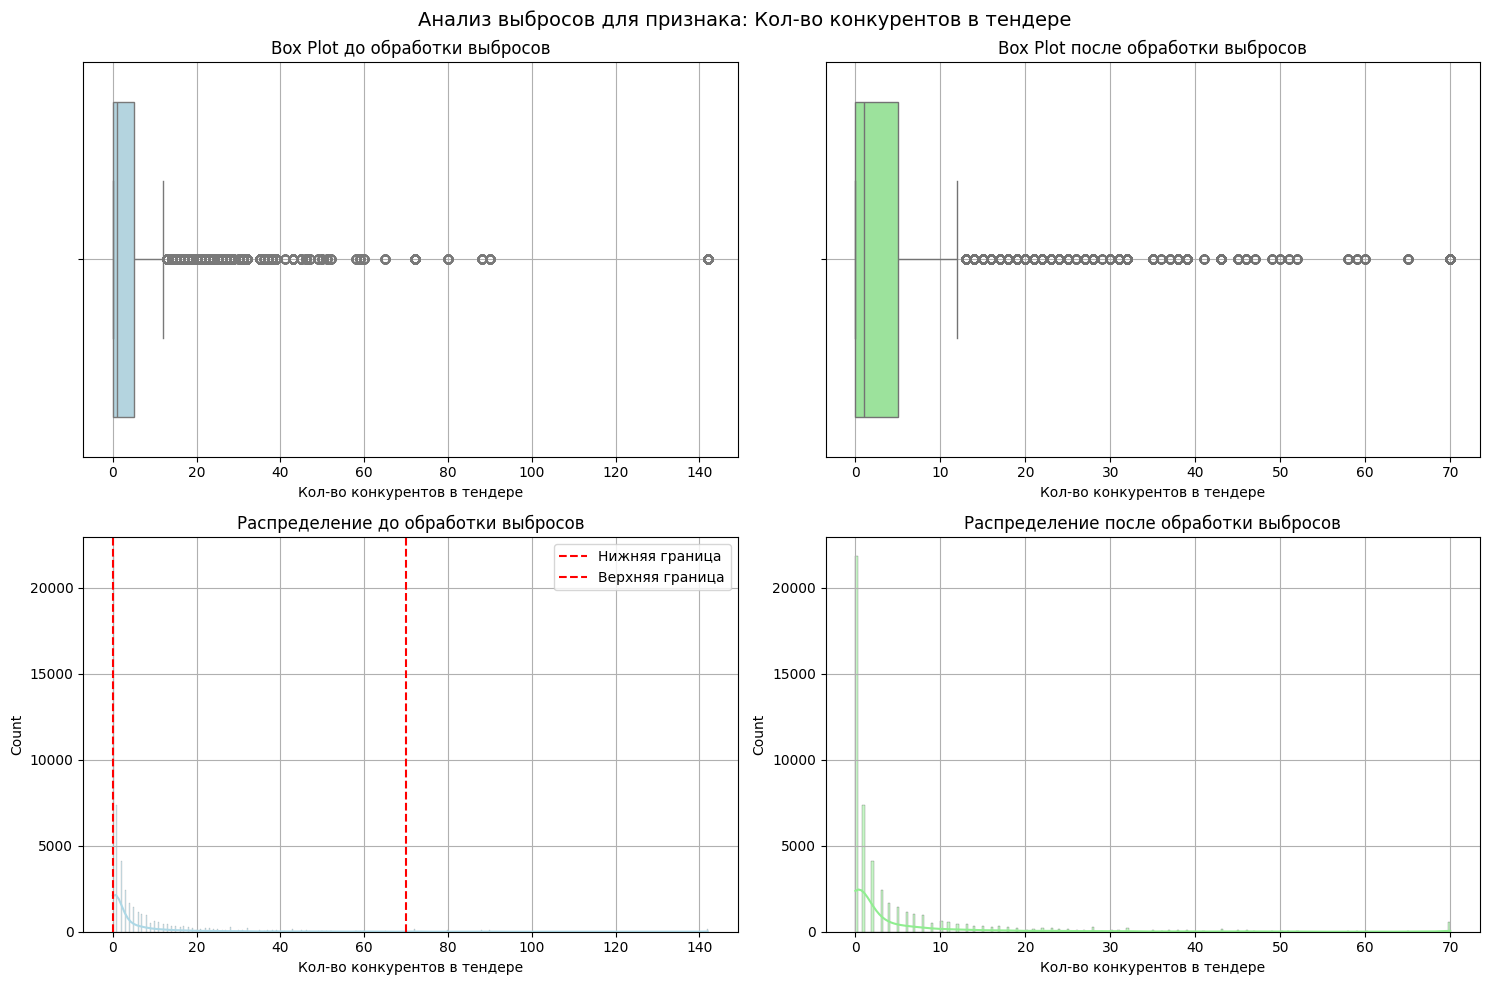


Статистики для признака Среднее кол-во конкурентов в регионе:

До обработки (тренировочная выборка):
Среднее: 5.57
Медиана: 4.91
Стд. отклонение: 3.88
Min: 0.19
Max: 21.20

После обработки:
Среднее: 5.57
Медиана: 4.91
Стд. отклонение: 3.88
Min: 0.19
Max: 21.20

Процент выбросов в тренировочной выборке: 0.00%


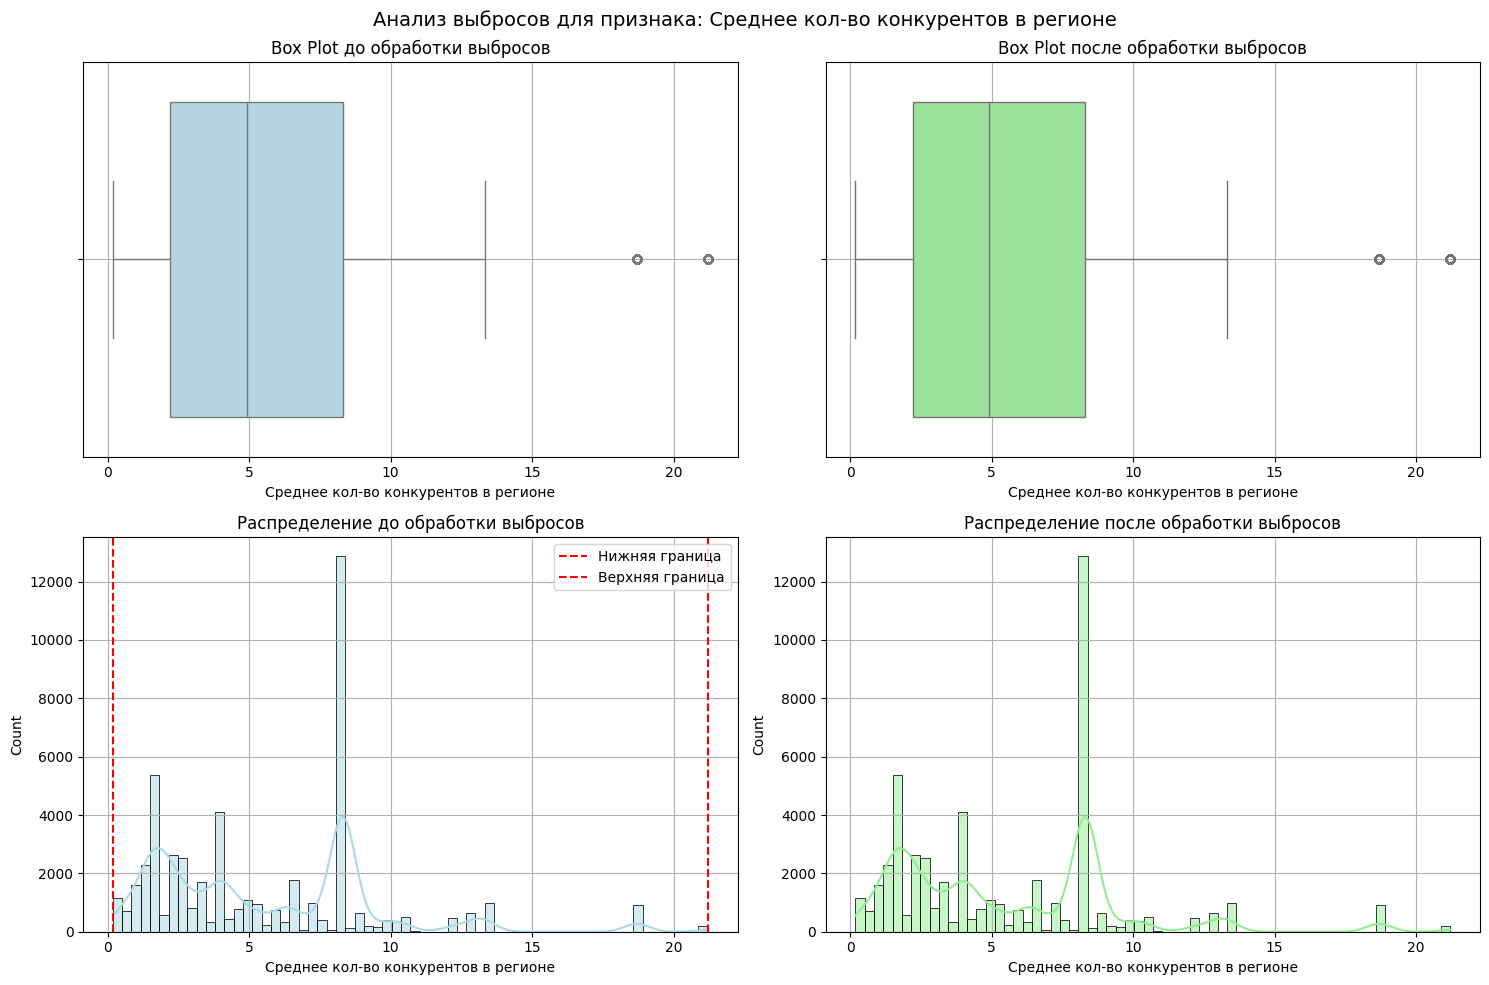


Статистики для признака Среднее кол-во конкурентов в сфере:

До обработки (тренировочная выборка):
Среднее: 5.57
Медиана: 1.04
Стд. отклонение: 10.18
Min: 0.00
Max: 142.00

После обработки:
Среднее: 5.39
Медиана: 1.04
Стд. отклонение: 8.57
Min: 0.00
Max: 55.00

Процент выбросов в тренировочной выборке: 0.36%


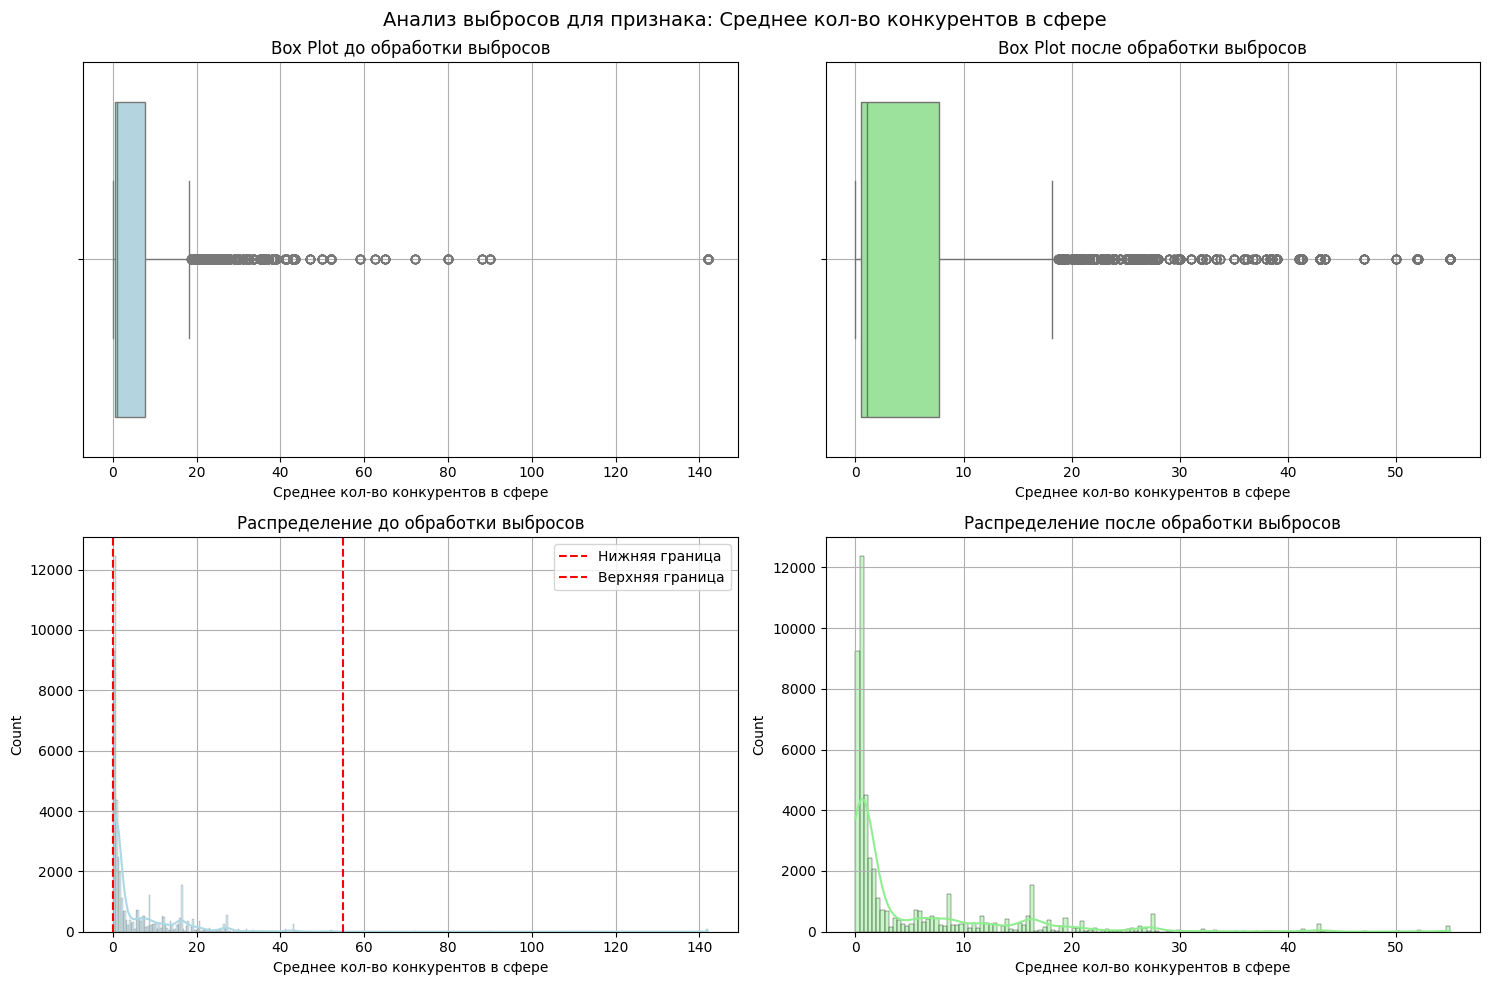


Статистики для признака Длительность тендера (дни):

До обработки (тренировочная выборка):
Среднее: 7.05
Медиана: 7.00
Стд. отклонение: 7.74
Min: -232.00
Max: 392.00

После обработки:
Среднее: 7.03
Медиана: 7.00
Стд. отклонение: 6.31
Min: -28.00
Max: 44.00

Процент выбросов в тренировочной выборке: 0.37%


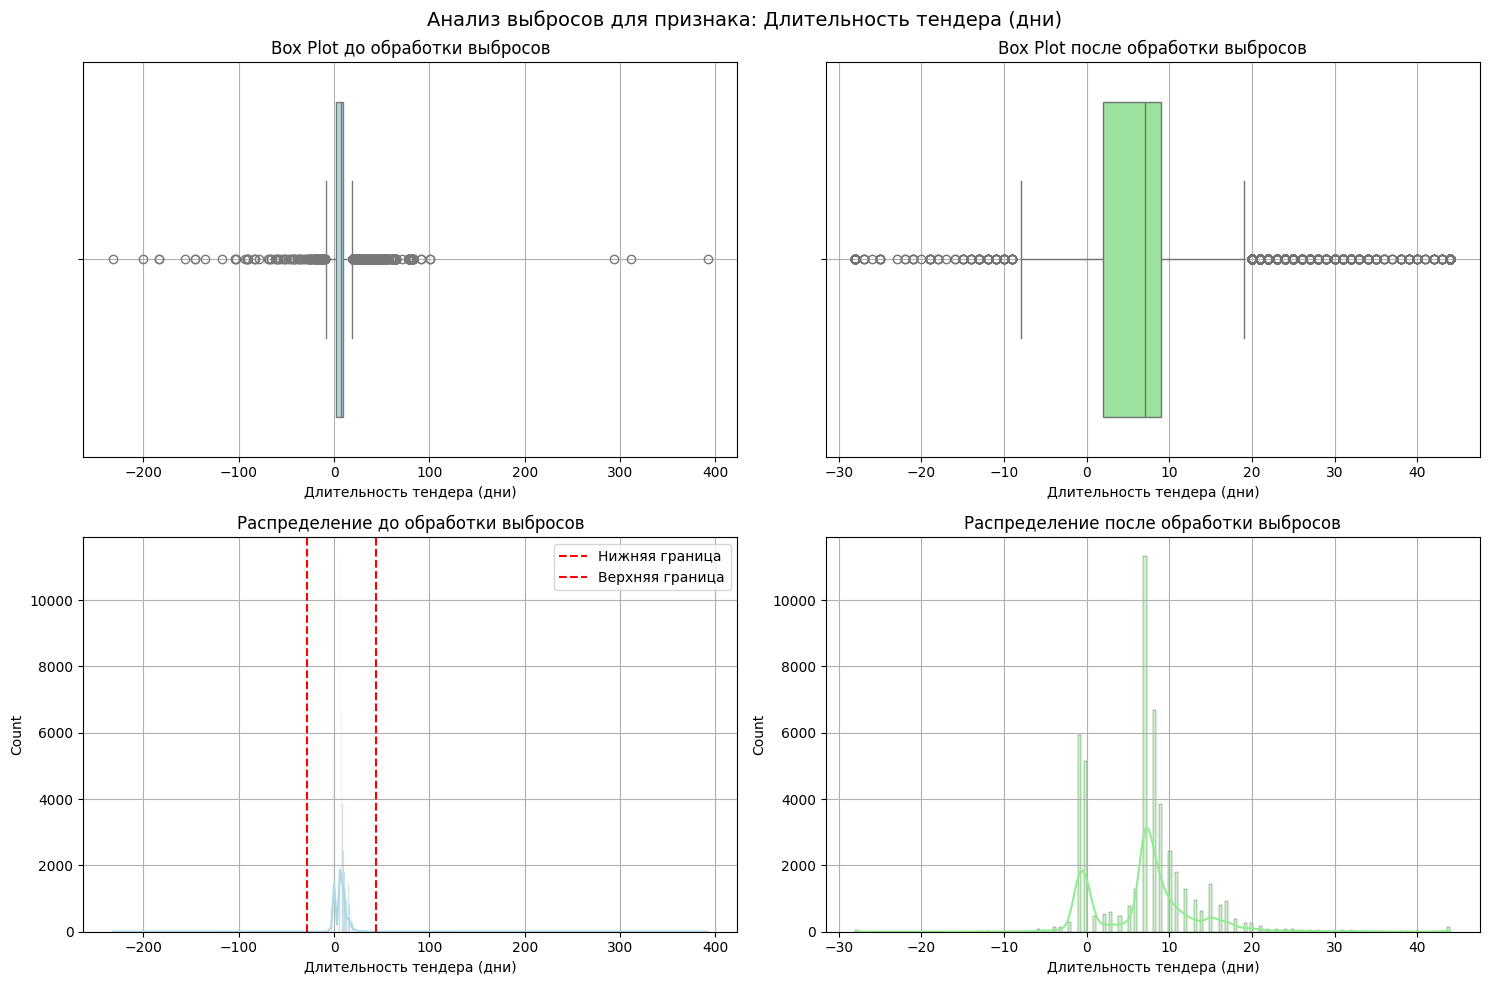


Статистики для признака Кол-во уникальных поставщики в регионе:

До обработки (тренировочная выборка):
Среднее: 1195.04
Медиана: 610.00
Стд. отклонение: 1339.59
Min: 15.00
Max: 4084.00

После обработки:
Среднее: 1195.04
Медиана: 610.00
Стд. отклонение: 1339.59
Min: 15.00
Max: 4084.00

Процент выбросов в тренировочной выборке: 0.00%


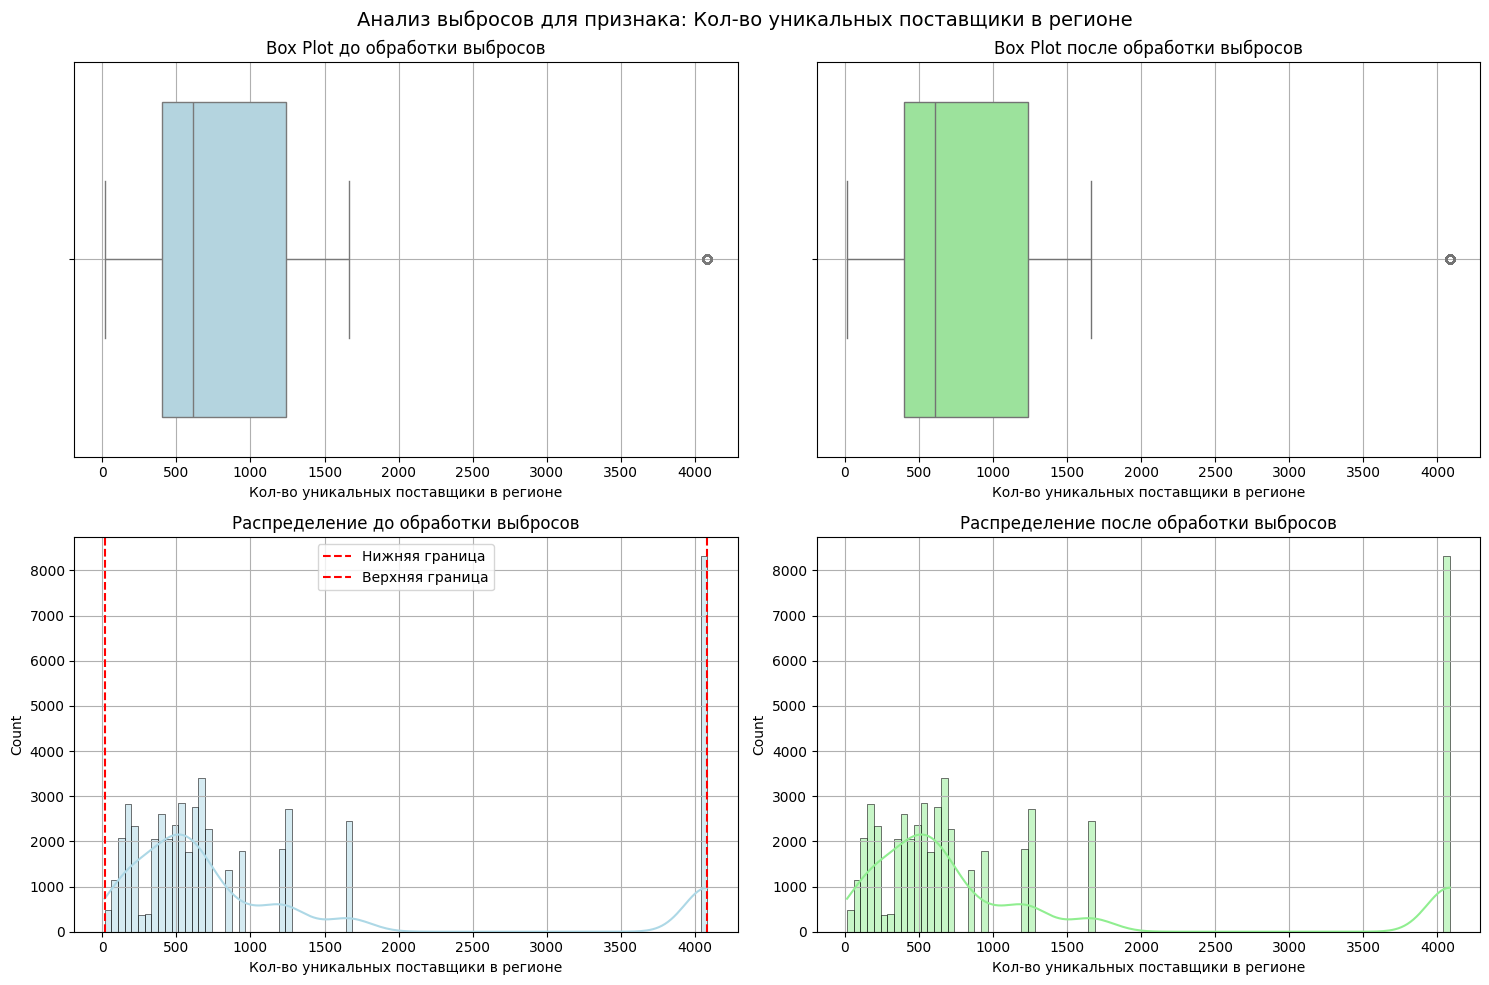


Статистики для признака Кол-во уникальных поставщики в сфере:

До обработки (тренировочная выборка):
Среднее: 129.83
Медиана: 69.00
Стд. отклонение: 163.27
Min: 1.00
Max: 727.00

После обработки:
Среднее: 129.83
Медиана: 69.00
Стд. отклонение: 163.27
Min: 1.00
Max: 727.00

Процент выбросов в тренировочной выборке: 0.00%


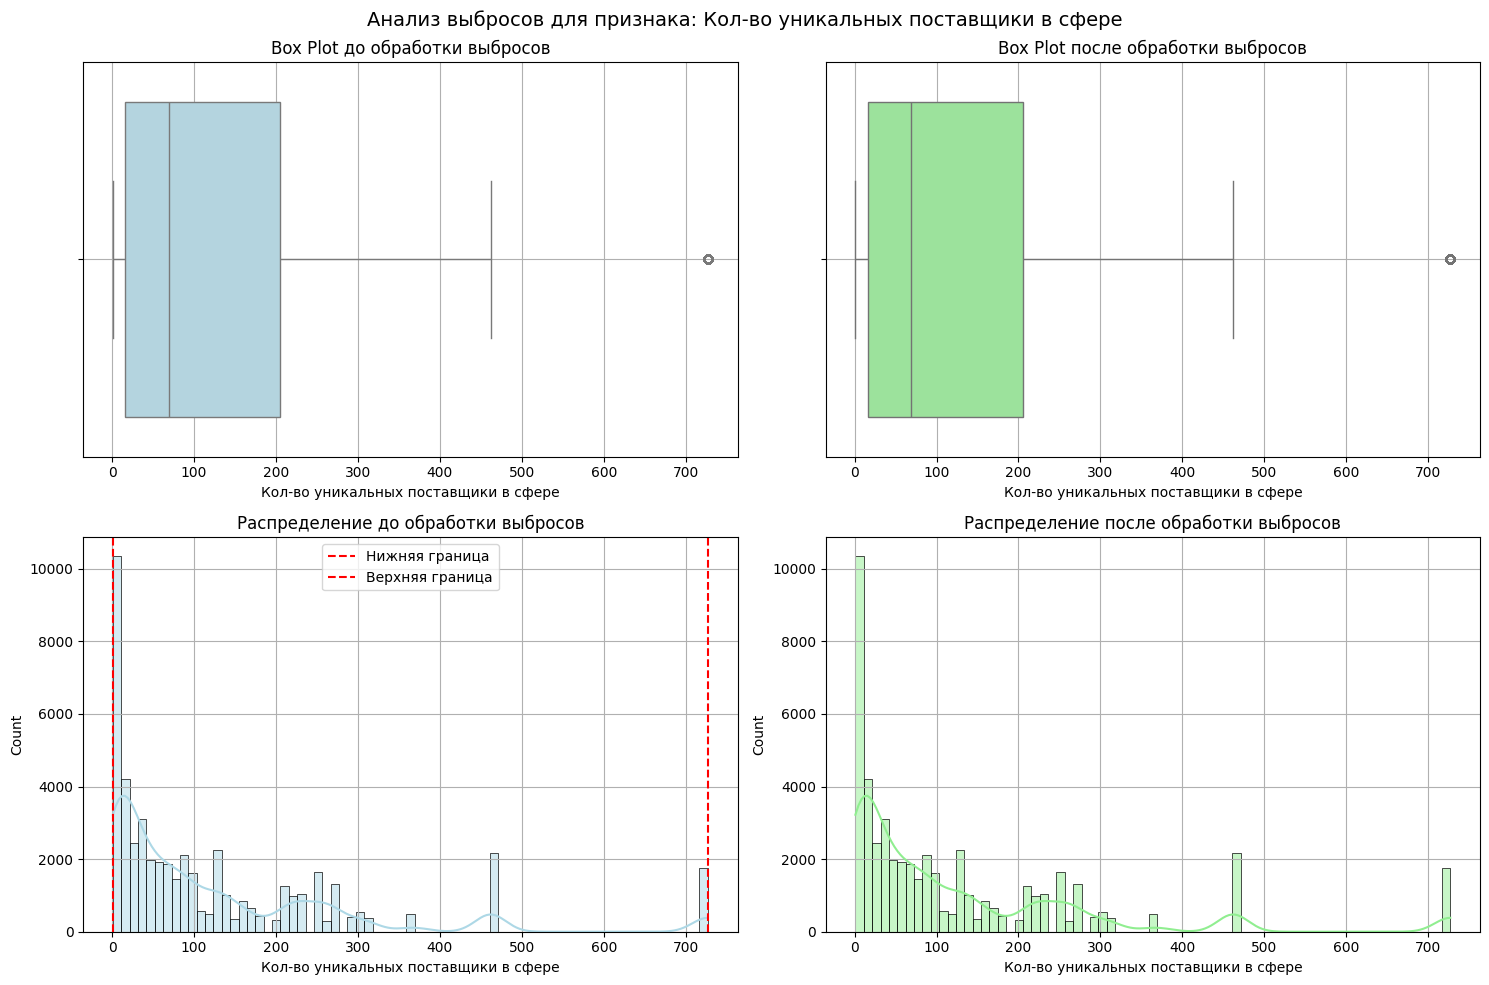

In [19]:
df_clean = train_data.copy()

for feature in numerical_features:
    Q1 = train_data[feature].quantile(0.05)
    Q3 = train_data[feature].quantile(0.95)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data_min = train_data[feature].min()
    data_max = train_data[feature].max()

    df_clean[feature] = df_clean[feature].clip(lower_bound, upper_bound)

    clean_min = df_clean[feature].min()
    clean_max = df_clean[feature].max()

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Анализ выбросов для признака: {feature}', fontsize=14)

        # Боксплоты
    sns.boxplot(x=train_data[feature], ax=axes[0, 0], color='lightblue', orient='horizontal')
    axes[0, 0].set_title('Box Plot до обработки выбросов')
    axes[0, 0].grid(True)

    sns.boxplot(x=df_clean[feature], ax=axes[0, 1], color='lightgreen', orient='horizontal')
    axes[0, 1].set_title('Box Plot после обработки выбросов')
    axes[0, 1].grid(True)

        # Гистограммы
    sns.histplot(data=train_data, x=feature, kde=True, ax=axes[1, 0], color='lightblue', stat='count')

        # Рисуем границы всегда, но с учетом обрезки
    plot_lower = lower_bound if lower_bound > data_min else data_min
    plot_upper = upper_bound if upper_bound < data_max else data_max

    axes[1, 0].axvline(plot_lower, color='red', linestyle='--', label='Нижняя граница')
    axes[1, 0].axvline(plot_upper, color='red', linestyle='--', label='Верхняя граница')
    axes[1, 0].set_title('Распределение до обработки выбросов')

    margin = (data_max - data_min) * 0.05
    axes[1, 0].set_xlim(data_min - margin, data_max + margin)

    axes[1, 0].legend()
    axes[1, 0].grid(True)

    sns.histplot(data=df_clean, x=feature, kde=True, ax=axes[1, 1], color='lightgreen', stat='count')
    axes[1, 1].set_title('Распределение после обработки выбросов')

    clean_margin = (clean_max - clean_min) * 0.05 
    lower_lim = clean_min - clean_margin if clean_margin > 0 else clean_min
    upper_lim = clean_max + clean_margin if clean_margin > 0 else clean_max
    axes[1, 1].set_xlim(lower_lim, upper_lim)
    axes[1, 1].grid(True)


    print(f"\nСтатистики для признака {feature}:")
    print("\nДо обработки (тренировочная выборка):")
    print(f"Среднее: {train_data[feature].mean():.2f}")
    print(f"Медиана: {train_data[feature].median():.2f}")
    print(f"Стд. отклонение: {train_data[feature].std():.2f}")
    print(f"Min: {train_data[feature].min():.2f}")
    print(f"Max: {train_data[feature].max():.2f}")
    
    print("\nПосле обработки:")
    print(f"Среднее: {df_clean[feature].mean():.2f}")
    print(f"Медиана: {df_clean[feature].median():.2f}")
    print(f"Стд. отклонение: {df_clean[feature].std():.2f}")
    print(f"Min: {df_clean[feature].min():.2f}")
    print(f"Max: {df_clean[feature].max():.2f}")

    outlier_percentage = ((train_data[feature] != df_clean[feature]).sum() / len(train_data) * 100) if len(train_data) > 0 else 0 
    print(f"\nПроцент выбросов в тренировочной выборке: {outlier_percentage:.2f}%")

    plt.tight_layout()
    plt.show()

Займемся проблемой дисбаланса классов. Делаем это только после обработки редких категорий и выбросов, так как иначе можем случайно размножить редкие категории при балансировке, таким образом алгоритм получится более стабильным

Первый вариант - использовать кластерный анализ для сохранения структуры данных, второй - SMOTE. Реализуем оба и сравним их

In [20]:
all_data = pd.concat([df_clean, test_data], axis=0)

for feature in categorical_features:
    all_data[feature] = all_data[feature].astype(str)
    
    value_counts = all_data[feature].value_counts(normalize=True)
    rare_categories = value_counts[value_counts < 0.001].index
    
    all_data[feature] = all_data[feature].apply(
        lambda x: 'Other' if x in rare_categories else x)
    
    all_data[feature] = all_data[feature].fillna('Unknown')

train_data_processed = all_data[all_data['Год'].isin(range(2019, 2024))].copy()
test_data_processed = all_data[all_data['Год'].isin(range(2024, 2026))].copy()

X = train_data_processed[numerical_features + categorical_features + time_features].copy()
y = train_data_processed['Target'].values

In [21]:
numerical_features = [
    'Процент побед', 'Кол-во побед по региону', 'Процент побед по региону',
    'Кол-во побед по заказчику', 'Процент побед по заказчику',
    'Кол-во побед по сфере', 'Процент побед по сфере',
    'Общее кол-во участий', 'Общее кол-во побед',
    'Стоимость(руб.) Заказчик', 'Длительность_приема_заявок', 
    'Время_до_торгов', 'Кол-во конкурентов в тендере',
    'Среднее кол-во конкурентов в регионе', 'Среднее кол-во конкурентов в сфере',
    'Длительность тендера (дни)', 'Кол-во уникальных поставщики в регионе',
    'Кол-во уникальных поставщики в сфере'
]

categorical_features = [
    'Уровень', 'Регион поставки', 'Сфера деятельности', 
    'Тип торгов', 'РНП ранее', 'Заказчик', 'Город поставки', 'Поставщик'
]

time_features = [
    'Год', 'Месяц', 
    'Публикация_декабрь', 'Публикация_январь', 'Окончание_прием_суббота'
]

In [47]:
df_clean.columns

Index(['Уровень', 'Заказчик', 'ИНН заказчика', 'Стоимость(руб.) Заказчик',
       'Реестровый номер публикации', 'Сфера деятельности', 'Регион поставки',
       'Город поставки', 'Дата публикации',
       'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
       'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
       'Дата окончания проведения торгов', 'Поставщик', 'ИНН поставщика',
       'Снижение на торгах,%', 'Тип торгов', 'РНП ранее', 'Target', 'Допущен',
       'Год', 'Месяц', 'Процент побед', 'Кол-во побед по региону',
       'Процент побед по региону', 'Кол-во побед по заказчику',
       'Процент побед по заказчику', 'Кол-во побед по сфере',
       'Процент побед по сфере', 'Общее кол-во участий', 'Общее кол-во побед',
       'Последняя дата публикации', 'Кол-во конкурентов в тендере',
       'Среднее кол-во конкурентов в регионе',
       'Среднее кол-во конкурентов в сфере'

In [22]:
winners = X[y == 1]
losers = X[y == 0]
    
print("Исходное распределение:")
print(f"Победители (класс 1): {len(winners):,} ({len(winners)/(len(winners)+len(losers)):.2%})")
print(f"Проигравшие (класс 0): {len(losers):,} ({len(losers)/(len(winners)+len(losers)):.2%})")

Исходное распределение:
Победители (класс 1): 29,447 (58.57%)
Проигравшие (класс 0): 20,830 (41.43%)


Будем применять кластерный анализ к мажоритарному классу - победителям, классу 1. Из каждого кластера "хороших" (победителей) берем примеры, сохраняя исходное распределение кластеров. Общее количество отобранных "хороших" = количество "плохих" * (1 + extra_samples_ratio)

Для измерения качества кластеризации будем использовать метрику Silhouette Score, которая показывает качество в диапазоне [-1, 1]. Она измеряет, насколько похож объект на свой кластер по сравнению с другими кластерами. Чем ближе к единцие, тем больше похоже объекты внутри одного кластера и различаются из разных кластеров

Используем Silhouette Score именно потому что он помогает найти оптимальное число кластеров автоматически, без ручного подбора

In [97]:
def balance_classes_with_clustering_corrected(X, y, extra_samples_ratio=0.15, max_clusters_to_try=10):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), numerical_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
        ])
    
    winners_prepared = preprocessor.fit_transform(winners)
    
    n_losers = len(losers)
    n_winners_target = int(n_losers * (1 + extra_samples_ratio))
    
    min_clusters = 2
    max_clusters = min(max_clusters_to_try, n_winners_target // 100)
    
    best_score = -1
    best_n_clusters = min_clusters
    
    print("Поиск оптимального числа кластеров:")
    for n_clusters in range(min_clusters, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, max_iter=300)
        labels = kmeans.fit_predict(winners_prepared)
        sample_size = min(10000, len(winners_prepared)) #выборка используется, можно потом убрать, когда уже на всех данных
        score = silhouette_score(winners_prepared, labels, sample_size=sample_size)
        print(f"Кластеров: {n_clusters}, Silhouette score: {score:.3f}")
        
        if score > best_score:
            best_score = score
            best_n_clusters = n_clusters
    
    print(f"\nОптимальное количество кластеров: {best_n_clusters} (score: {best_score:.3f})")
    
    kmeans = KMeans(n_clusters=best_n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(winners_prepared)
    
    cluster_proportions = np.bincount(cluster_labels) / len(cluster_labels)
    selected_indices = []
    
    for cluster in range(best_n_clusters):
        cluster_indices = np.where(cluster_labels == cluster)[0]
        n_samples = int(n_winners_target * cluster_proportions[cluster])
        
        if len(cluster_indices) > 0:
            replace = n_samples > len(cluster_indices)
            selected_indices.extend(
                np.random.choice(cluster_indices, size=n_samples, replace=replace)
            )
    
    X_balanced = pd.concat([losers, winners.iloc[selected_indices]], axis=0, ignore_index=True)
    y_balanced = np.concatenate([np.zeros(n_losers), np.ones(len(selected_indices))])
    
    print("\nИтоговое распределение классов:")
    print(pd.Series(y_balanced).value_counts(normalize=True))
    
    return X_balanced, y_balanced

X_balanced_cluster, y_balanced_cluster = balance_classes_with_clustering_corrected(X, y)

balanced_data = pd.concat([
    pd.DataFrame(X_balanced_cluster, columns=X.columns),
    pd.Series(y_balanced_cluster, name='Target')
], axis=1)

print("Размерность сбалансированного датасета:", balanced_data.shape)

train_data = balanced_data.copy()

Поиск оптимального числа кластеров:
Кластеров: 2, Silhouette score: 0.800
Кластеров: 3, Silhouette score: 0.725
Кластеров: 4, Silhouette score: 0.522
Кластеров: 5, Silhouette score: 0.553
Кластеров: 6, Silhouette score: 0.558
Кластеров: 7, Silhouette score: 0.551
Кластеров: 8, Silhouette score: 0.470
Кластеров: 9, Silhouette score: 0.442
Кластеров: 10, Silhouette score: 0.377

Оптимальное количество кластеров: 2 (score: 0.800)

Итоговое распределение классов:
1.0    0.534868
0.0    0.465132
Name: proportion, dtype: float64
Размерность сбалансированного датасета: (44783, 32)


In [50]:
y_balanced_cluster_int = y_balanced_cluster.astype(int)

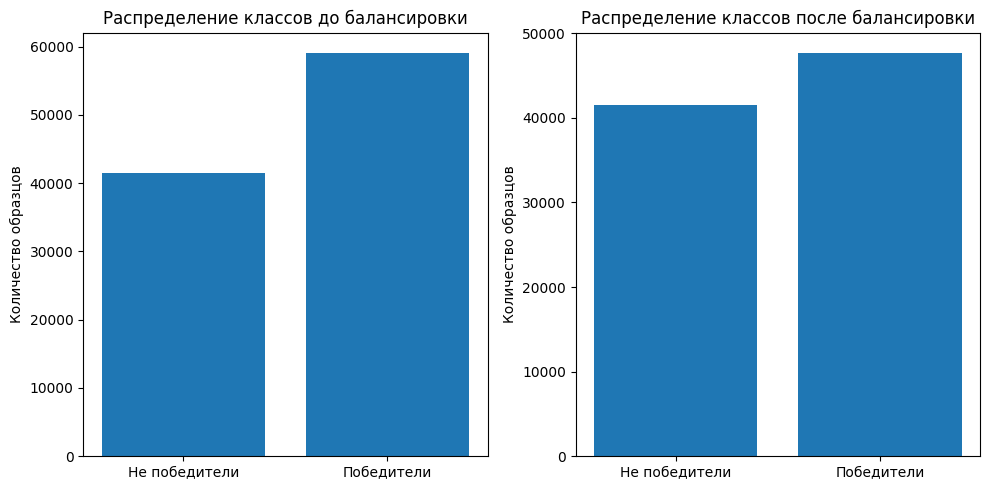

In [51]:
def plot_class_distribution(y_before, y_after):
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title('Распределение классов до балансировки')
    plt.bar(['Не победители', 'Победители'], np.bincount(y_before))
    plt.ylabel('Количество образцов')
    
    plt.subplot(1, 2, 2)
    plt.title('Распределение классов после балансировки')
    plt.bar(['Не победители', 'Победители'], np.bincount(y_after))
    plt.ylabel('Количество образцов')
    
    plt.tight_layout()
    plt.show()

plot_class_distribution(y, y_balanced_cluster_int)

In [25]:
numerical_features = [
    'Процент побед', 'Кол-во побед по региону', 'Процент побед по региону',
    'Кол-во побед по заказчику', 'Процент побед по заказчику',
    'Кол-во побед по сфере', 'Процент побед по сфере',
    'Общее кол-во участий', 'Общее кол-во побед',
    'Стоимость(руб.) Заказчик', 'Длительность_приема_заявок', 
    'Время_до_торгов', 'Кол-во конкурентов в тендере',
    'Среднее кол-во конкурентов в регионе', 'Среднее кол-во конкурентов в сфере',
    'Длительность тендера (дни)', 'Кол-во уникальных поставщики в регионе',
    'Кол-во уникальных поставщики в сфере'
]

categorical_features = [
    'Уровень', 'Регион поставки', 'Сфера деятельности', 
    'Тип торгов', 'РНП ранее', 'Заказчик', 'Город поставки', 'Поставщик'
]

time_features = [
    'Год', 'Месяц', 
    'Публикация_декабрь', 'Публикация_январь', 'Окончание_прием_суббота'
]

In [65]:
def balance_with_smote(X, y):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numerical_features),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
        ])
    
    X_prepared = preprocessor.fit_transform(X)
    
    feature_names = (
        numerical_features +
        list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
    )
    
    X_validated, y_validated = check_X_y(X_prepared, y, accept_sparse=['csr', 'csc'])
    
    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X_validated, y_validated)
    
    X_balanced = pd.DataFrame(X_smote, columns=feature_names)
    
    print("\nРаспределение классов после SMOTE:")
    print(pd.Series(y_smote).value_counts(normalize=True))
    
    return X_balanced, y_smote

In [66]:
print("Балансировка с помощью SMOTE:")
X_balanced_smote, y_balanced_smote = balance_with_smote(X, y)

Балансировка с помощью SMOTE:


/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



Распределение классов после SMOTE:
1    0.5
0    0.5
Name: proportion, dtype: float64


Предупреждение генерируется внутри самой библиотеки scikit-learn, чтобы его устранить, надо менять код библиотеки, но скоро будет обновление scikit-learn, где это будет исправлено (они уже работают над этим, судя по issues на GitHub)

Можно было бы использовать более старую версию scikit-learn (до 1.6), где это предупреждение еще не появлялось, но это не очень хорошая идея

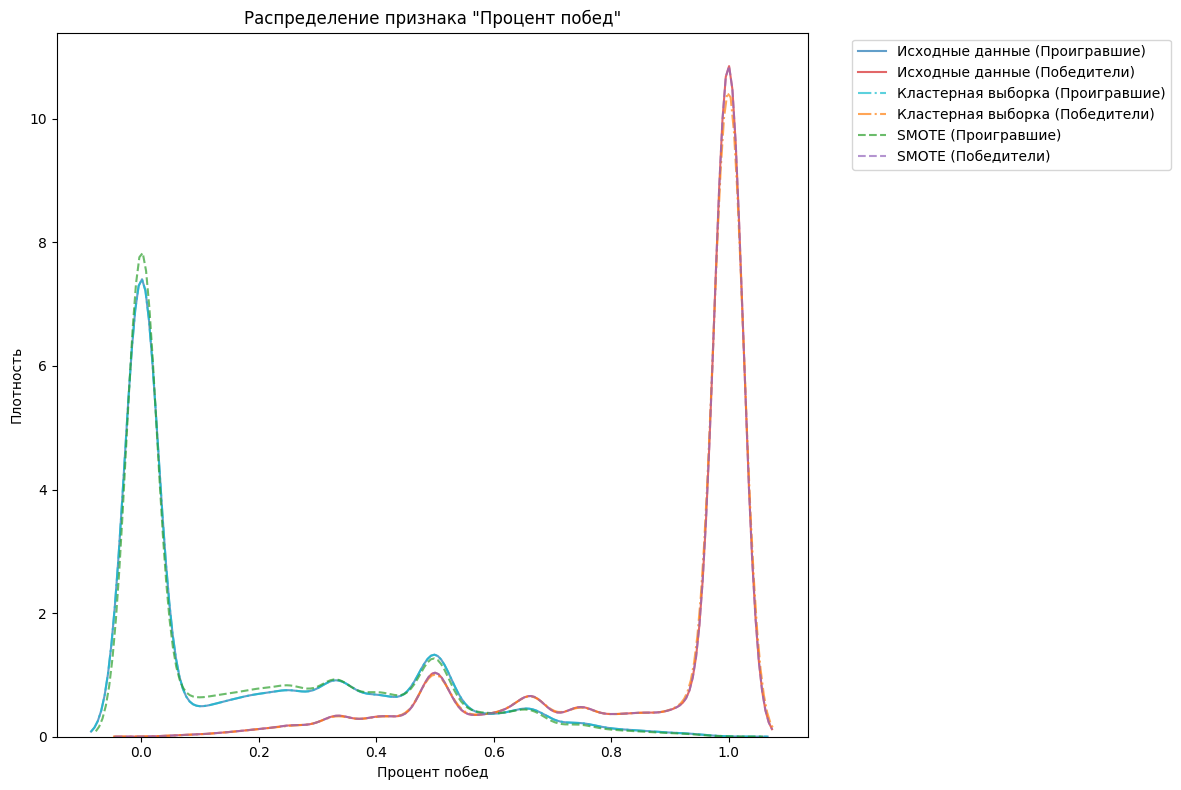

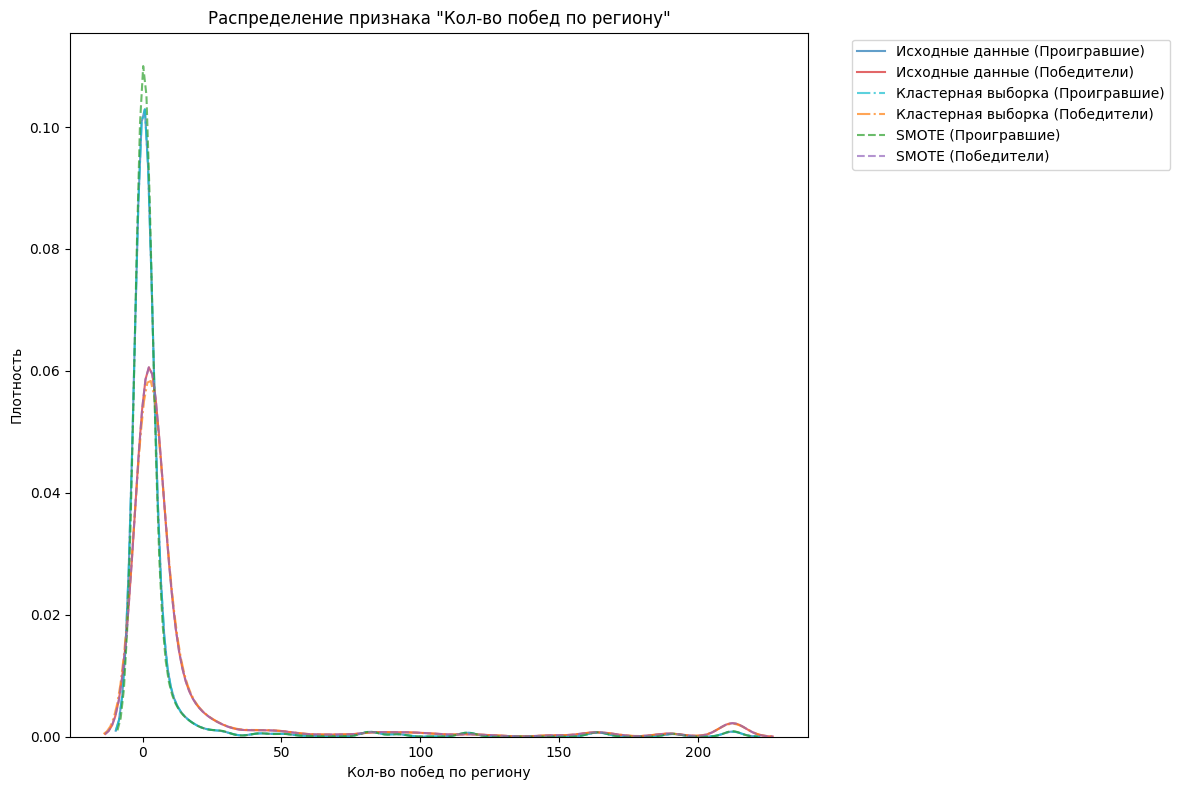

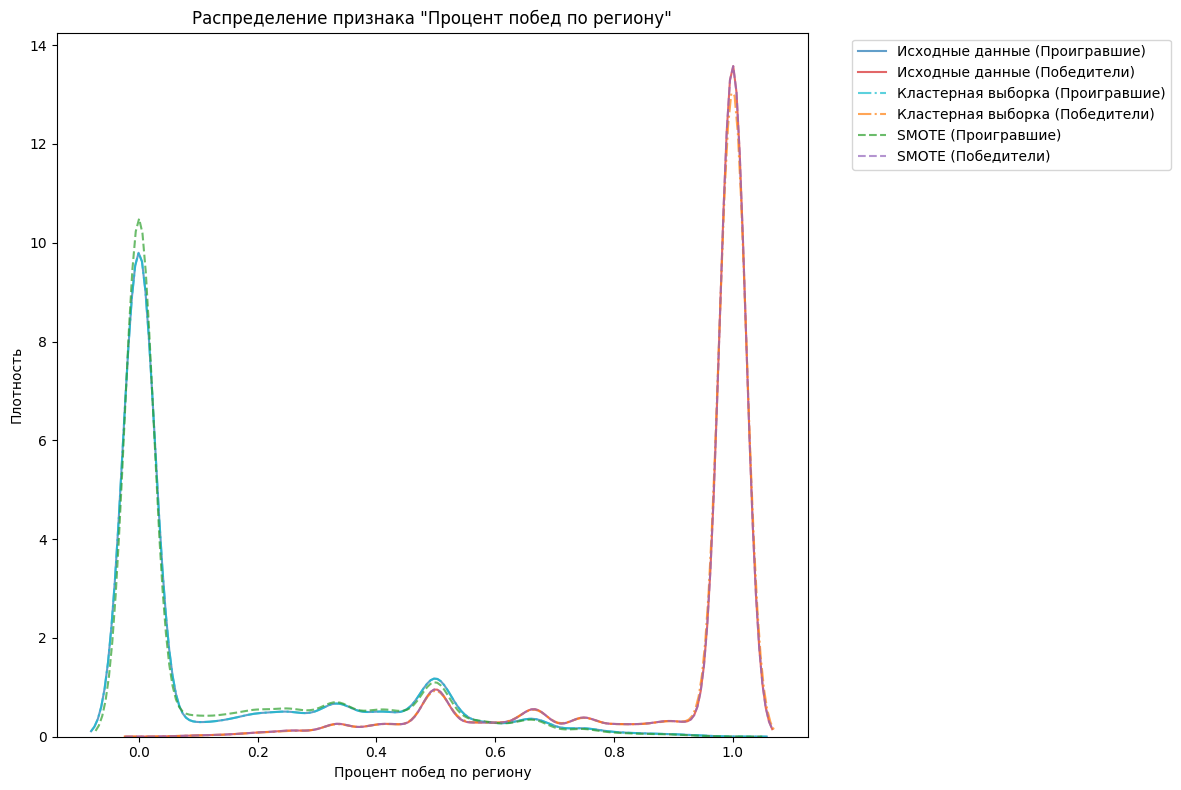

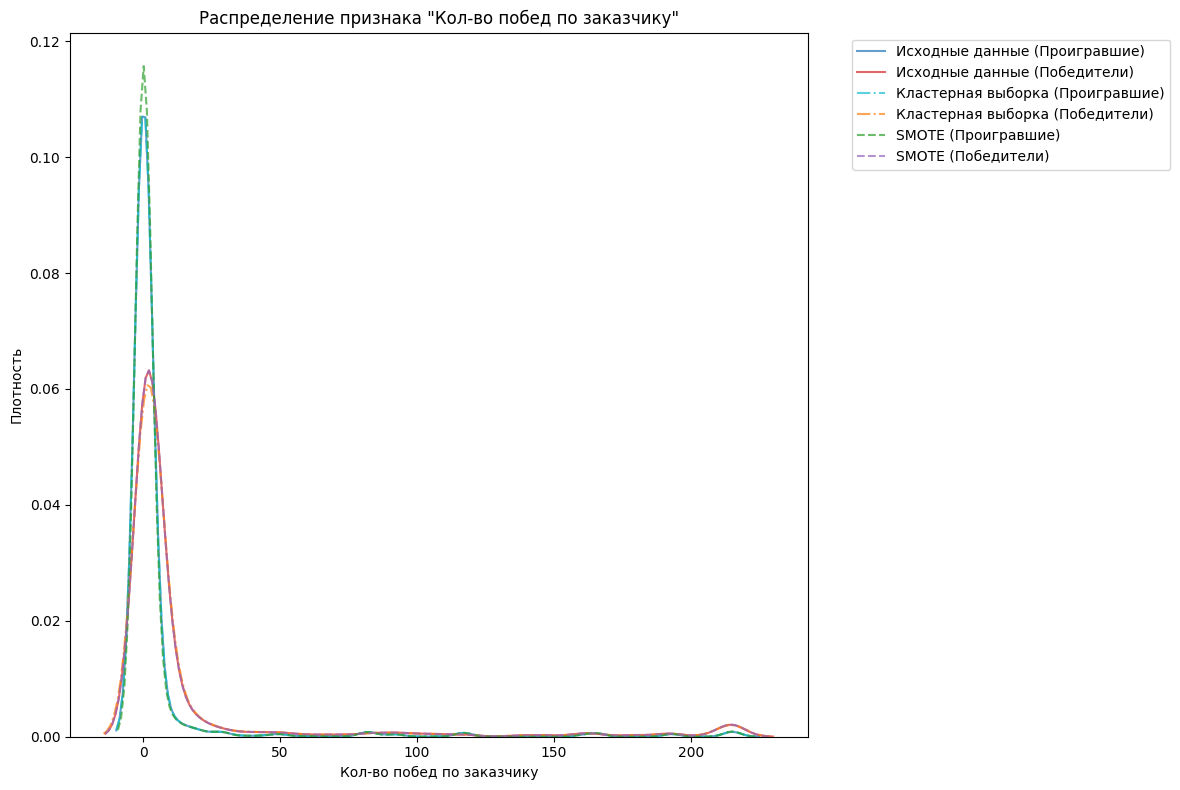

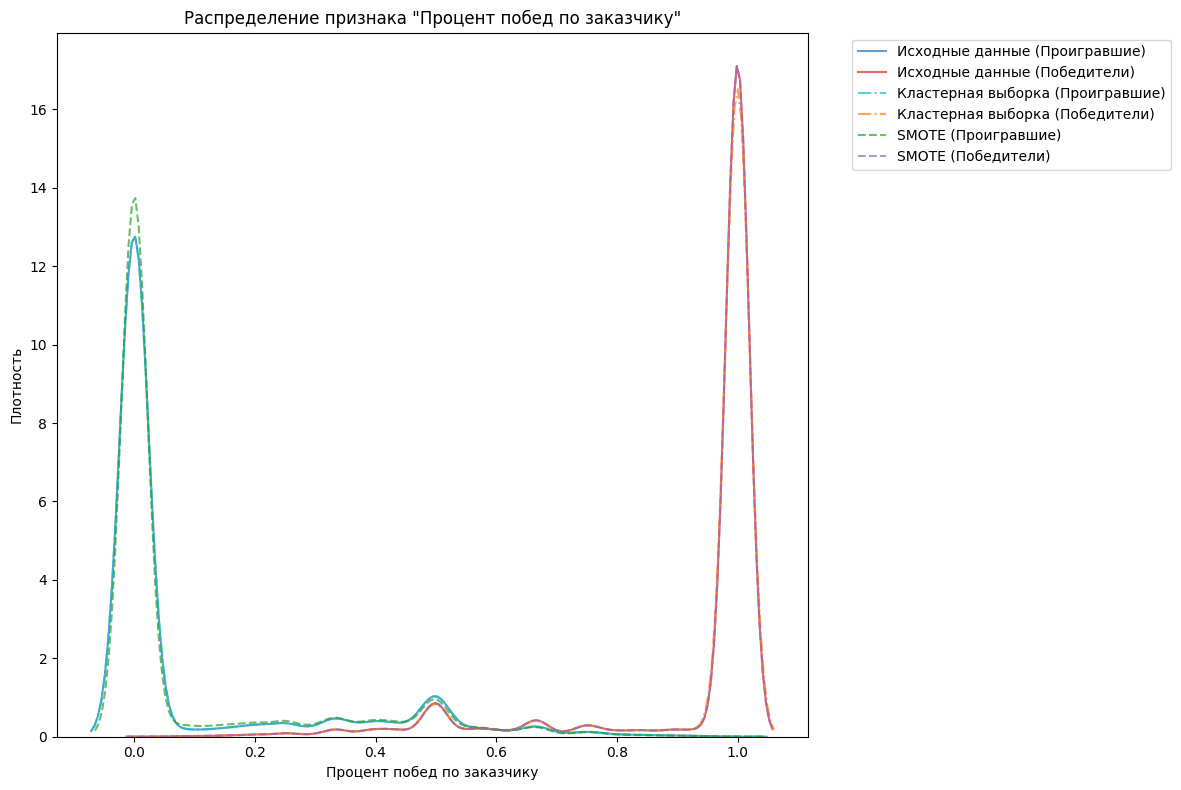

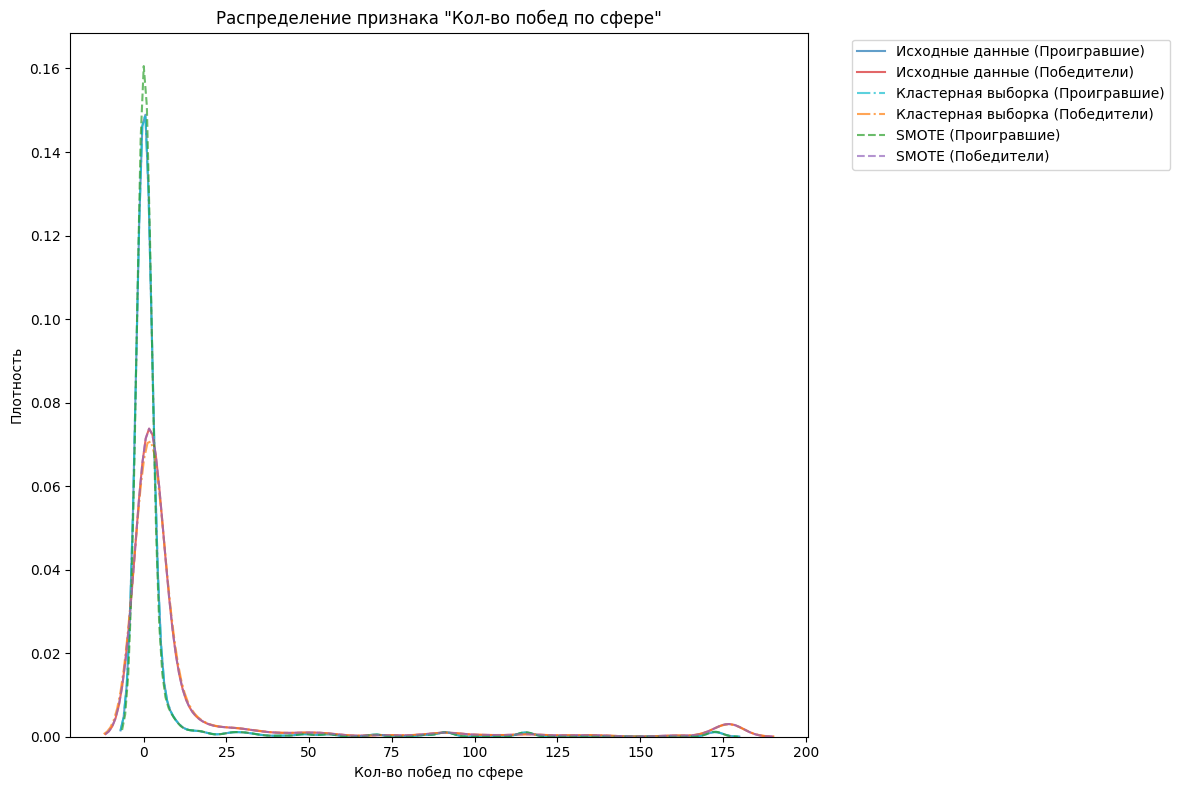

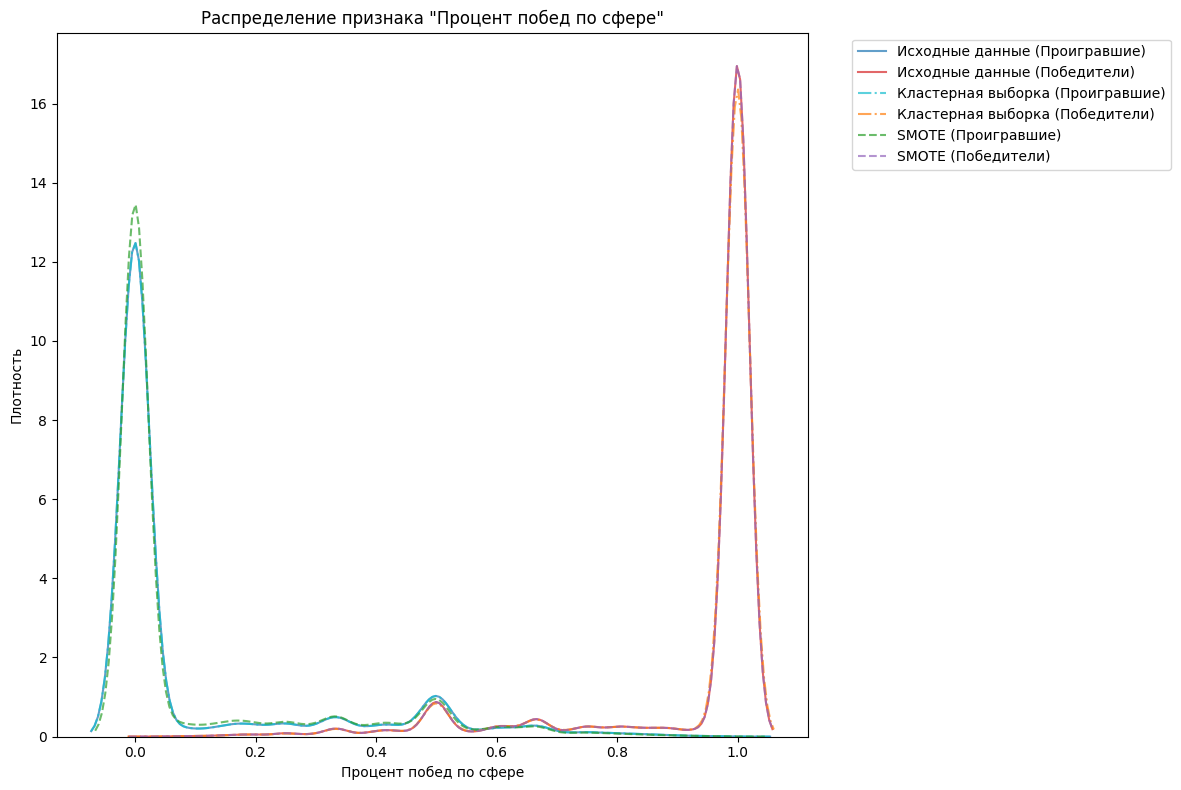

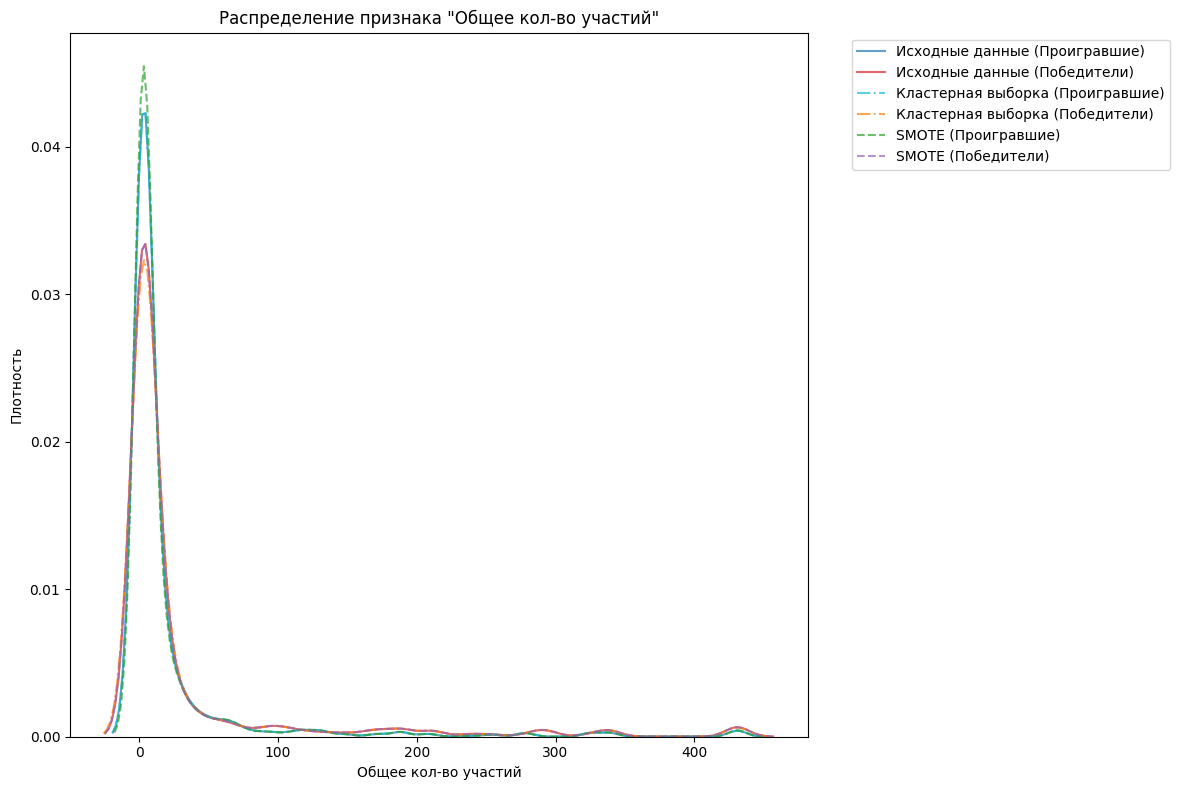

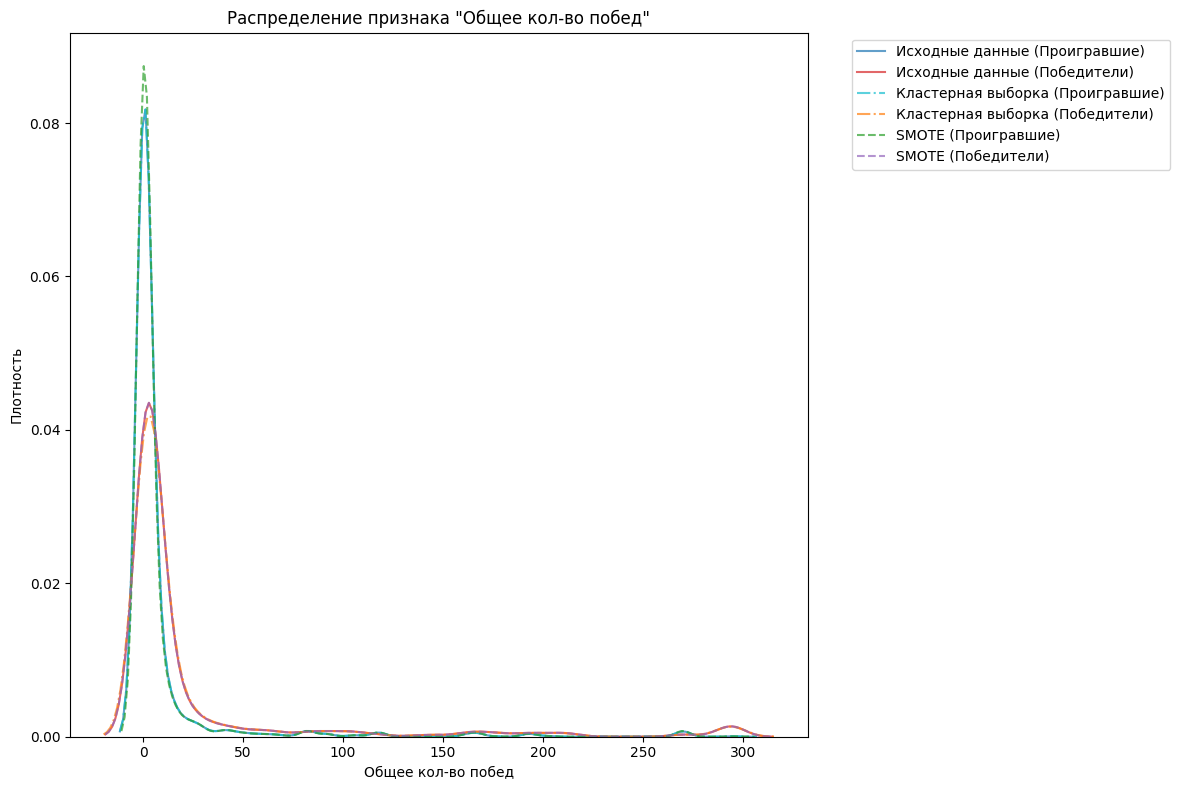

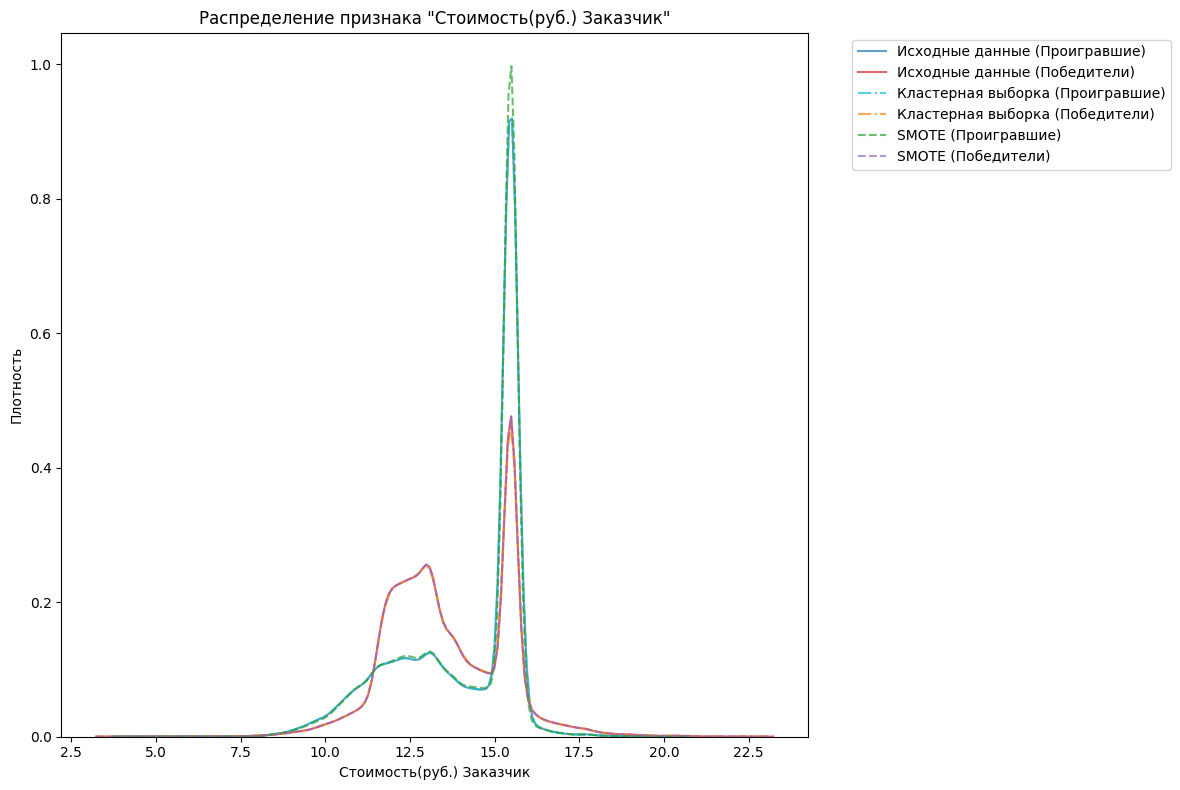

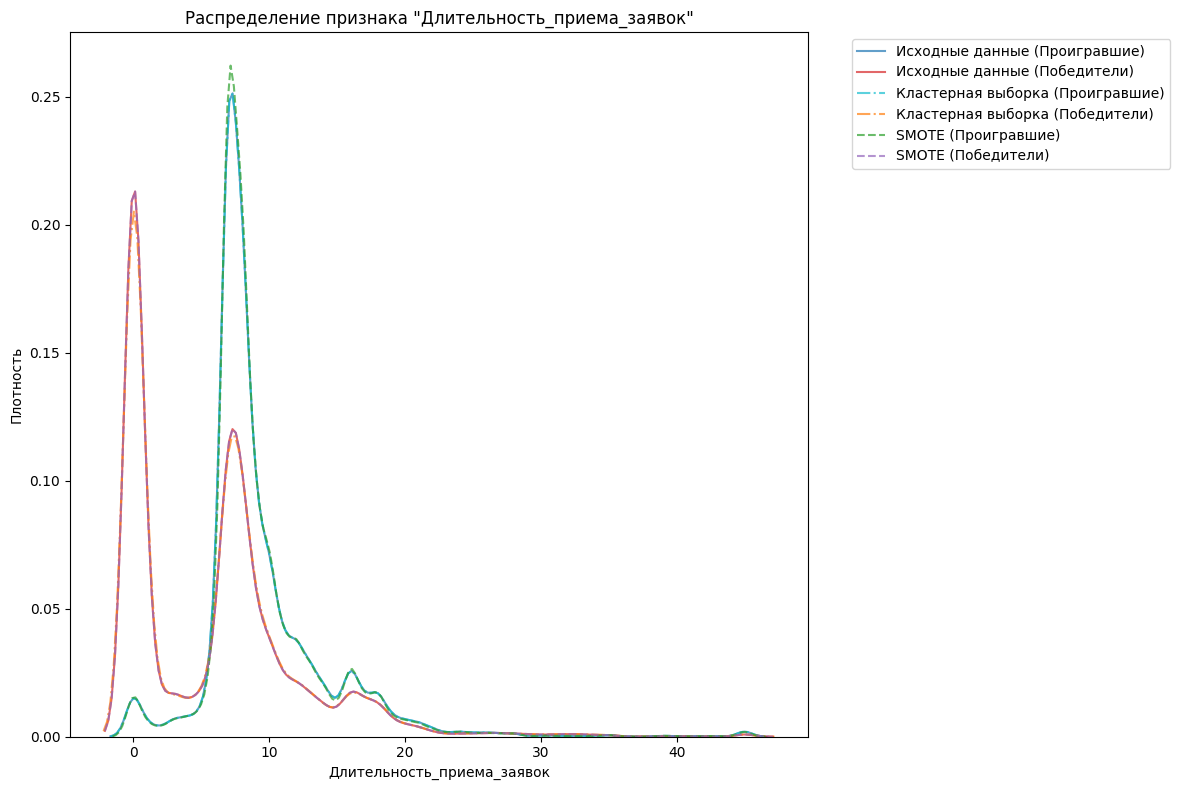

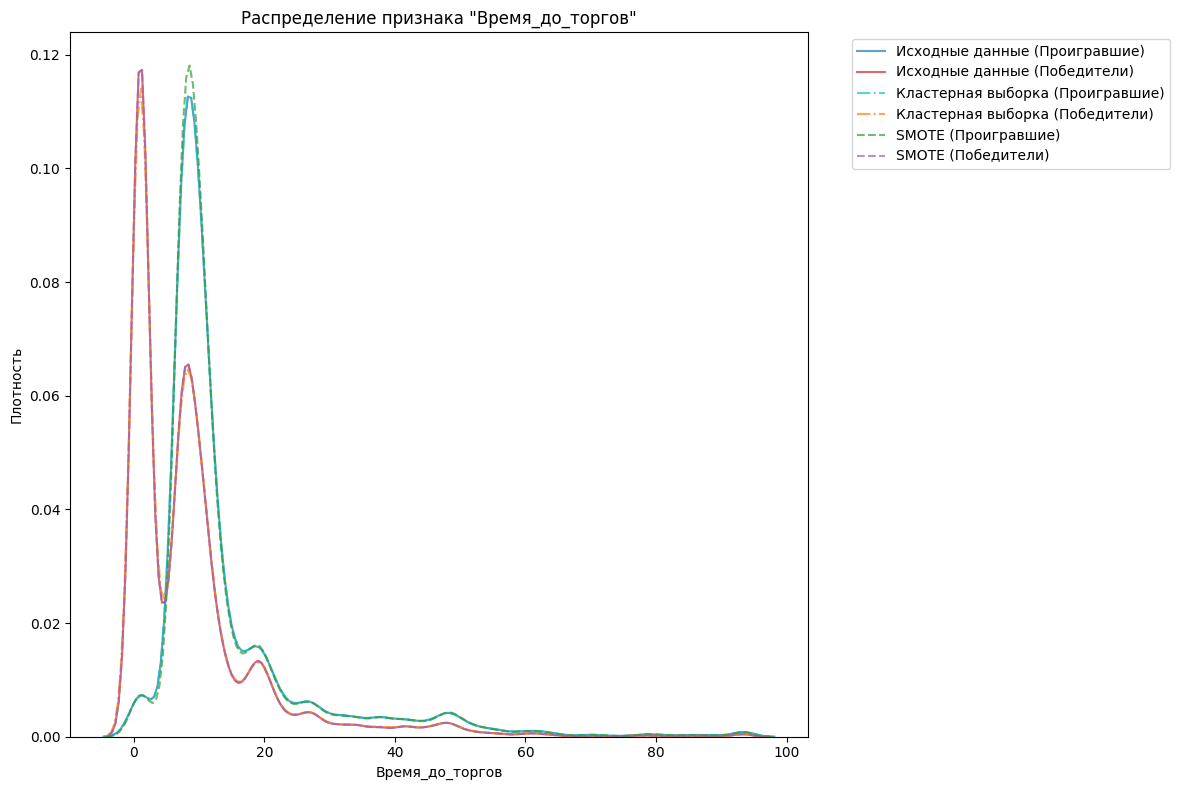

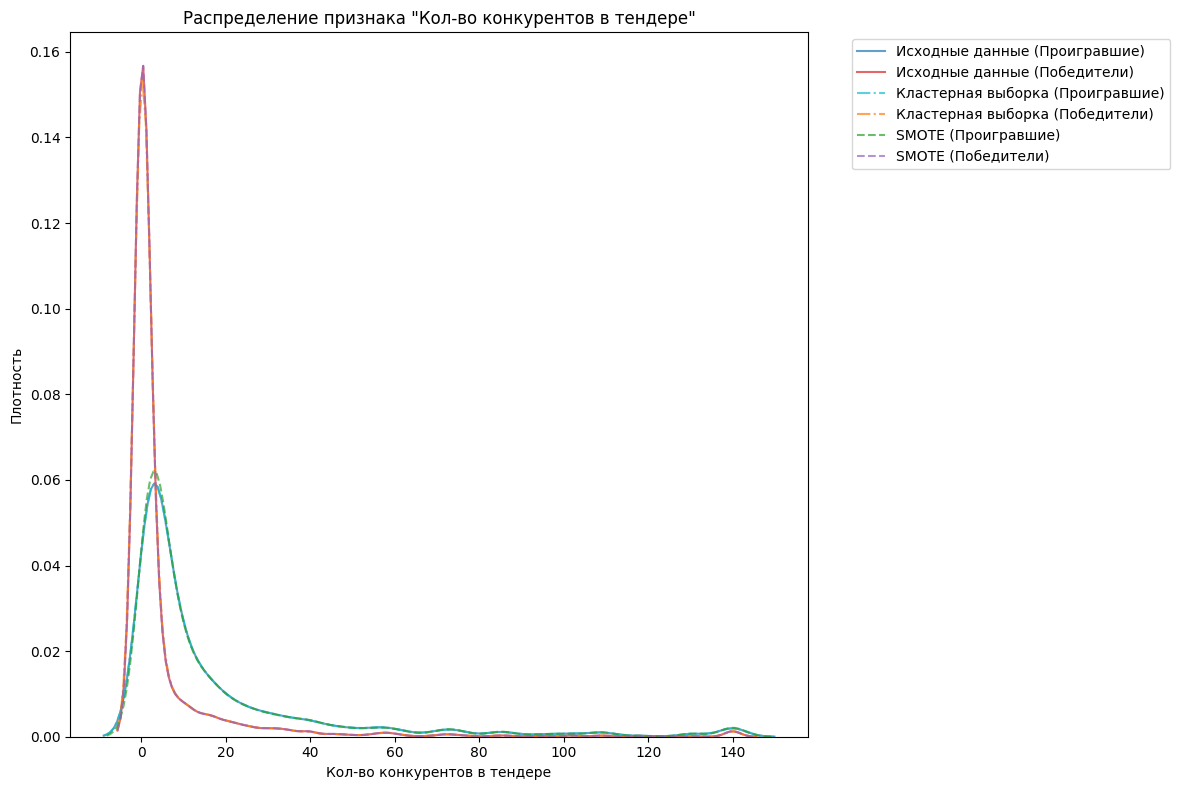

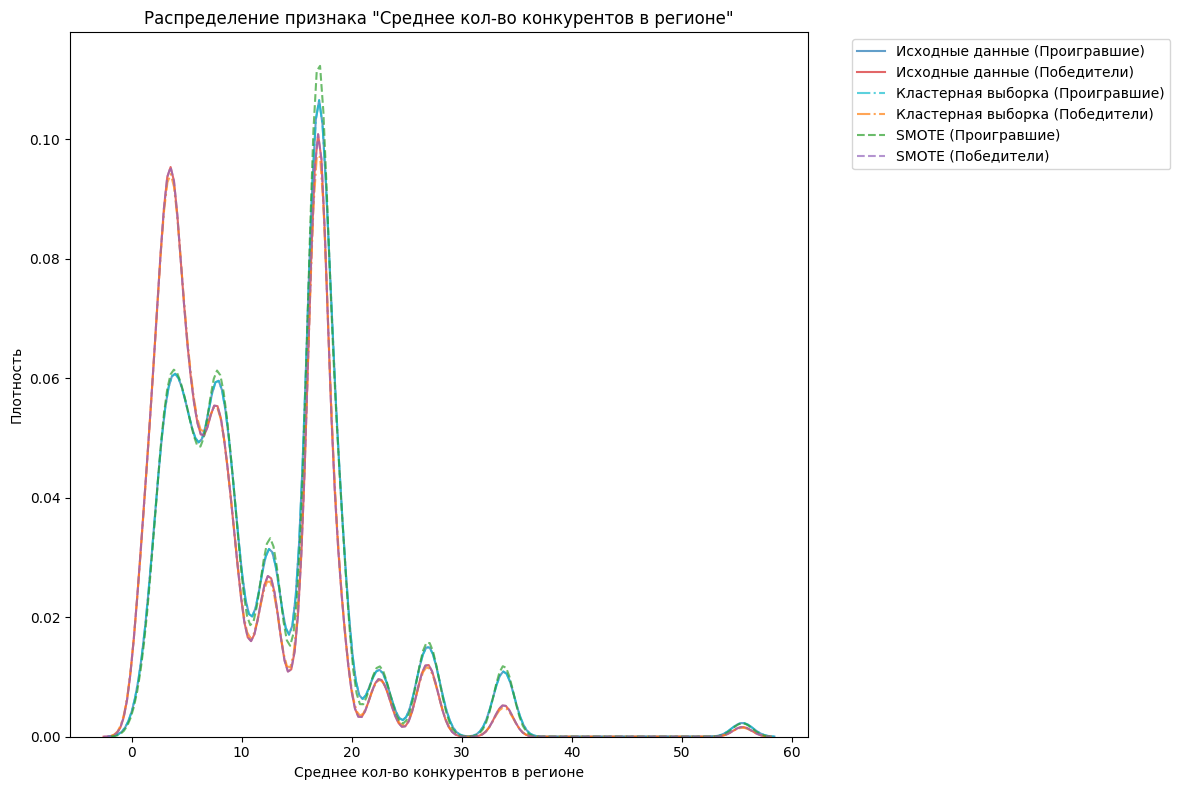

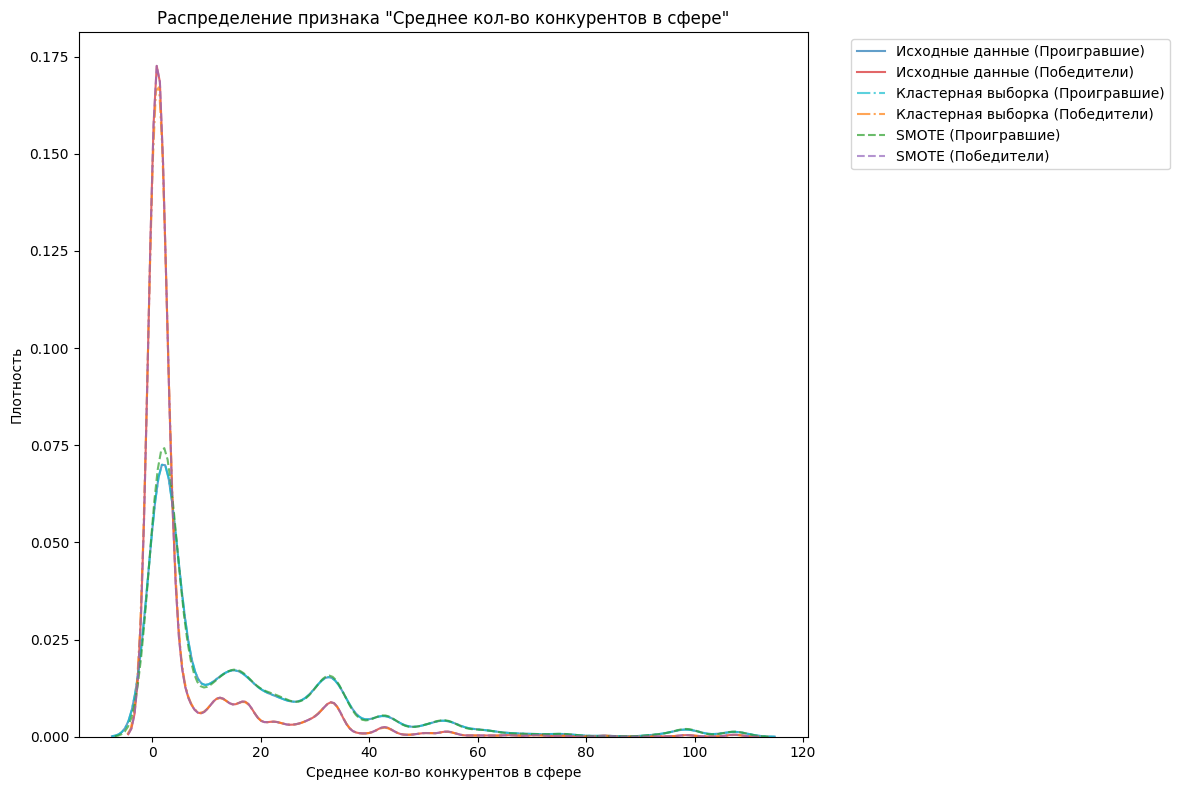

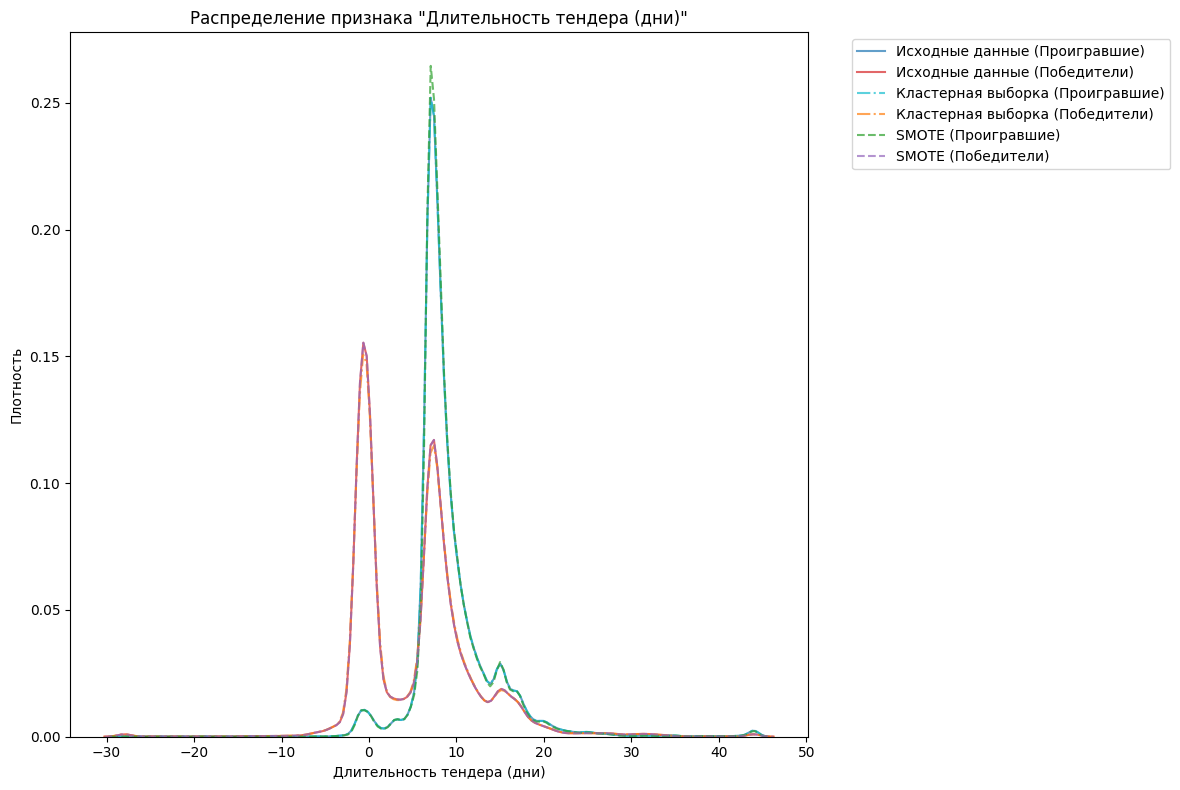

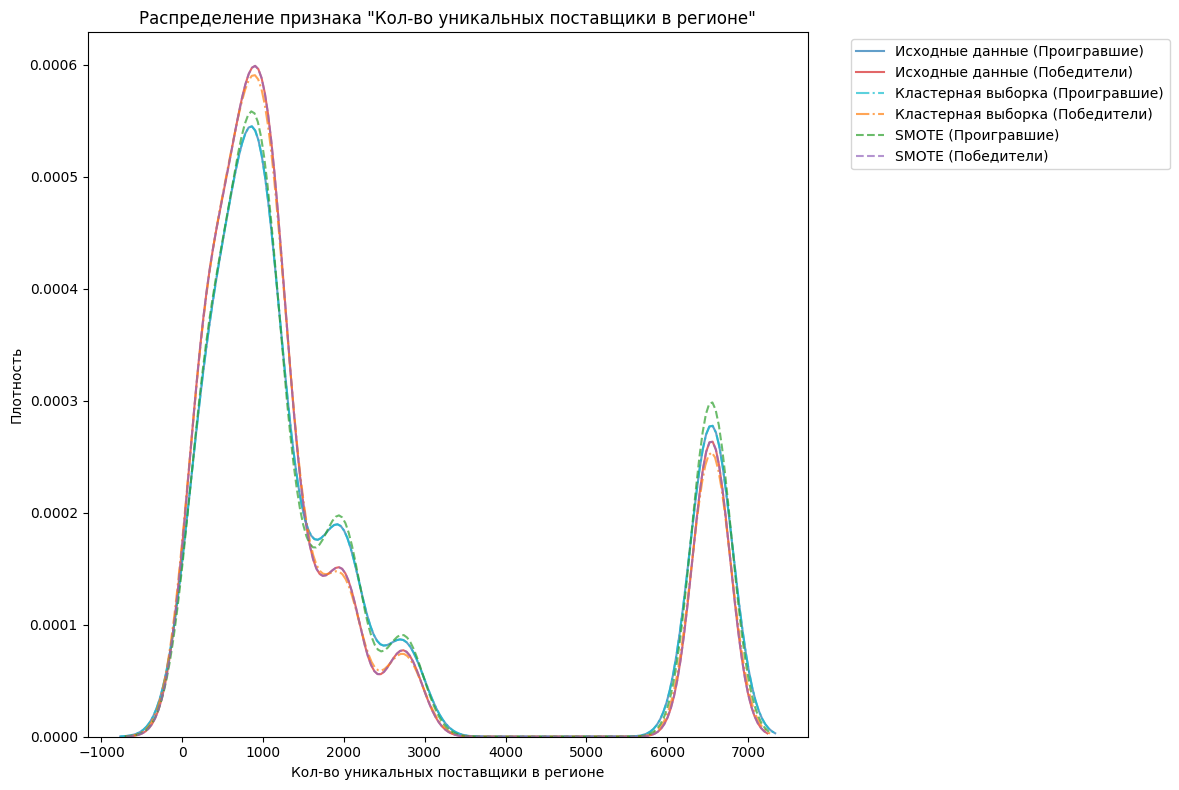

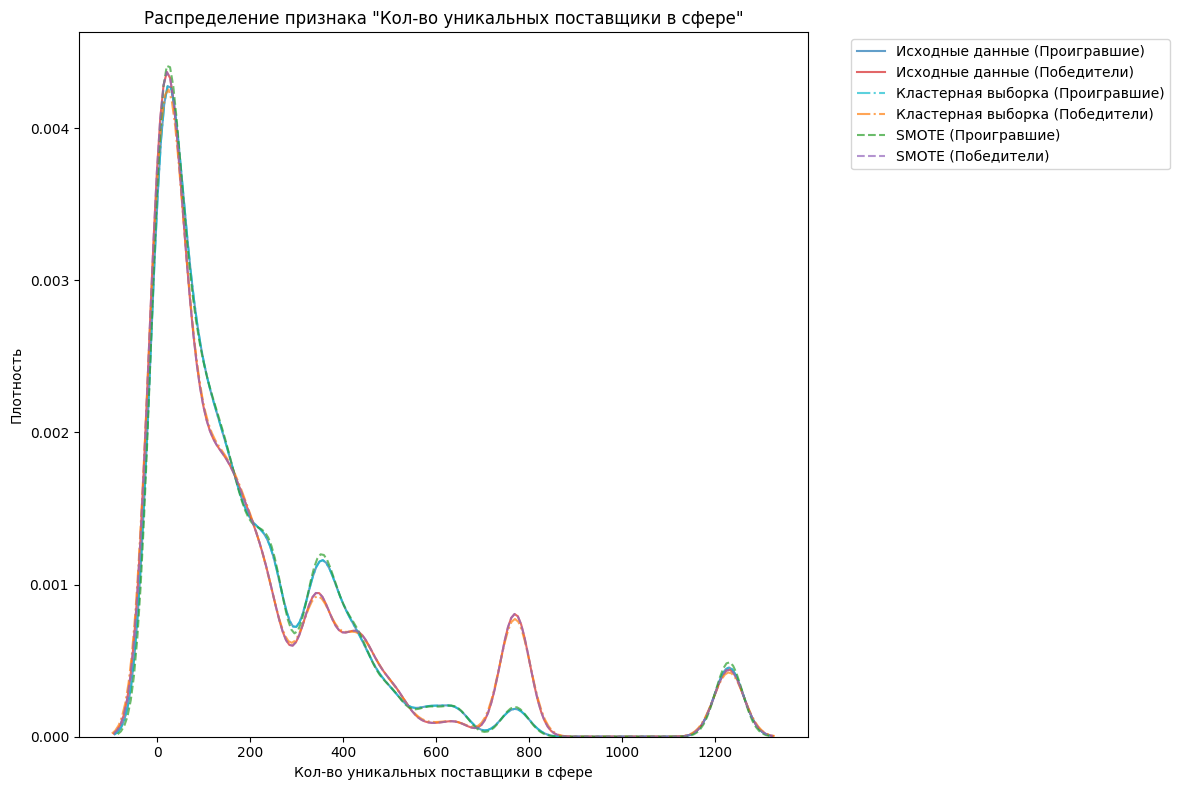


Распределение классов:

Исходные данные:
1    0.587574
0    0.412426
Name: proportion, dtype: float64

После ручной балансировки:
1.0    0.534876
0.0    0.465124
Name: proportion, dtype: float64

После SMOTE:
1    0.5
0    0.5
Name: proportion, dtype: float64


In [67]:
def plot_distribution_comparison(feature, original_X, original_y, balanced_X, balanced_y, smote_X, smote_y):
    plt.figure(figsize=(12, 8))
    
    if feature not in numerical_features:
        print(f"Пропускаем категориальный признак: {feature}")
        return
    
    sns.kdeplot(data=original_X[original_y == 0][feature], 
                color='#1f77b4',
                label='Исходные данные (Проигравшие)', 
                alpha=0.7)
    sns.kdeplot(data=original_X[original_y == 1][feature], 
                color='#d62728',
                label='Исходные данные (Победители)', 
                alpha=0.7)
    
    sns.kdeplot(data=balanced_X[balanced_y == 0][feature], 
                color='#17becf',
                label='Кластерная выборка (Проигравшие)', 
                alpha=0.7,
                linestyle='-.')
    sns.kdeplot(data=balanced_X[balanced_y == 1][feature], 
                color='#ff7f0e',
                label='Кластерная выборка (Победители)', 
                alpha=0.7,
                linestyle='-.')
    
    sns.kdeplot(data=smote_X[smote_y == 0][feature], 
                color='#2ca02c',
                label='SMOTE (Проигравшие)', 
                alpha=0.7,
                linestyle='--')
    sns.kdeplot(data=smote_X[smote_y == 1][feature], 
                color='#9467bd',
                label='SMOTE (Победители)', 
                alpha=0.7,
                linestyle='--')
    
    plt.title(f'Распределение признака "{feature}"')
    plt.xlabel(feature)
    plt.ylabel('Плотность')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

for feature in numerical_features:
    plot_distribution_comparison(
        feature,
        X,
        y,
        X_balanced_cluster,
        y_balanced_cluster_int,
        X_balanced_smote,
        y_balanced_smote
    )

print("\nРаспределение классов:")
print("\nИсходные данные:")
print(pd.Series(y).value_counts(normalize=True))
print("\nПосле ручной балансировки:")
print(pd.Series(y_balanced_cluster).value_counts(normalize=True))
print("\nПосле SMOTE:")
print(pd.Series(y_balanced_smote).value_counts(normalize=True))

SMOTE показывает идеальный (50/50). Балансировка с помощью кластеров дала соотношение примерно 53/47, что ближе к естественному распределению данных

Ручная балансировка лучше сохраняет форму исходного распределения, использует только реальные примеры (значит, меньше риск создания нереалистичных комбинаций признаков), а SMOTE создает более "шумное" распределение и может генерировать синтетические примеры, которые отклоняются от естественного распределения

Оставим первый вариант, так как соотношение 55/45 достаточно сбалансированное и при этом ближе к реальному распределению данных

In [29]:
train_data_balanced = pd.DataFrame(X_balanced_cluster, columns=X.columns)
train_data_balanced['Target'] = y_balanced_cluster

X_train_clean = train_data_balanced[numerical_features + categorical_features + time_features].copy()
y_train = train_data_balanced['Target']
X_test = test_data_processed[numerical_features + categorical_features + time_features].copy()
y_test = test_data_processed['Target']

preprocessor = ColumnTransformer(
    transformers=[
        ('percent_features', 'passthrough', percent_features),
        ('count_features', RobustScaler(), [f for f in numerical_features if f not in percent_features]),
        ('time_features', RobustScaler(), time_features),
        ('cost_transform', Pipeline([
            #('log', FunctionTransformer(np.log1p)),
            ('scale', StandardScaler())
        ]), ['Стоимость(руб.) Заказчик']),
        ('categorical', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore'
        ), categorical_features)
    ])

print("Размеры итоговых выборок:")
print(f"Обучающая выборка: {X_train_clean.shape}")
print(f"Валидационная выборка: {X_test.shape}")
print("\nРаспределение классов в обучающей выборке:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nРаспределение классов в тестовой выборке:")
print(pd.Series(y_test).value_counts(normalize=True))

Размеры итоговых выборок:
Обучающая выборка: (44783, 31)
Валидационная выборка: (4660, 31)

Распределение классов в обучающей выборке:
Target
1.0    0.534868
0.0    0.465132
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
Target
1    0.702146
0    0.297854
Name: proportion, dtype: float64


In [51]:
pipeline_log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

param_grid = {
    'classifier__C': [0.1],
    'classifier__solver': ['saga'],
    'classifier__max_iter': [400],
    'classifier__penalty': ['l1']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_log_reg = GridSearchCV(
    pipeline_log_reg,
    param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search_log_reg.fit(X_train_clean, y_train)
print("Логистическая регрессия:")
print("\nЛучшие параметры:")
print(grid_search_log_reg.best_params_)

print("\nРезультаты кросс-валидации:")
cv_results = pd.DataFrame(grid_search_log_reg.cv_results_)
for i in range(3):
    print(f"Fold {i+1} Recall: {cv_results[f'split{i}_test_score'][grid_search_log_reg.best_index_]:.4f}")

print(f"\nСредний Recall на кросс-валидации: {grid_search_log_reg.best_score_:.4f}")

y_pred = grid_search_log_reg.predict(X_test)
y_pred_proba = grid_search_log_reg.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Логистическая регрессия:

Лучшие параметры:
{'classifier__C': 0.1, 'classifier__max_iter': 400, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}

Результаты кросс-валидации:
Fold 1 Recall: 0.9656
Fold 2 Recall: 0.9606
Fold 3 Recall: 0.9614

Средний Recall на кросс-валидации: 0.9625
Recall на тестовой выборке: 0.7961


/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [66]:
def get_feature_importance(model, X, y, feature_names, method='built_in'):
    if method == 'built_in' and hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        if len(importances) != len(feature_names):
            if len(feature_names) > len(importances):
                feature_names = feature_names[:len(importances)]
            else:
                feature_names = feature_names + [f'feature_{i}' for i in range(len(feature_names), len(importances))]
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })
    elif method == 'coef' and hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
        if len(importances) != len(feature_names):
            if len(feature_names) > len(importances):
                feature_names = feature_names[:len(importances)]
            else:
                feature_names = feature_names + [f'feature_{i}' for i in range(len(feature_names), len(importances))]
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })
    else:
        perm_importance = permutation_importance(model, X, y, n_repeats=10, random_state=42)
        importances = perm_importance.importances_mean
        if len(importances) != len(feature_names):
            if len(feature_names) > len(importances):
                feature_names = feature_names[:len(importances)]
            else:
                feature_names = feature_names + [f'feature_{i}' for i in range(len(feature_names), len(importances))]
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })
    
    return importance_df.sort_values('importance', ascending=False)

In [53]:
trained_preprocessor_log_reg = grid_search_log_reg.best_estimator_.named_steps['preprocessor']
X_transformed_log_reg = trained_preprocessor_log_reg.transform(X_test)

feature_names = []

feature_names.extend(numerical_features)
for cat_feature in categorical_features:
    unique_values = X[cat_feature].unique()
    unique_values = [val for val in unique_values if pd.notna(val)]
    feature_names.extend([f"{cat_feature}_{val}" for val in unique_values])

Важность признаков для логистической регрессии:
Предупреждение: количество признаков (605) не соответствует размеру коэффициентов (603)


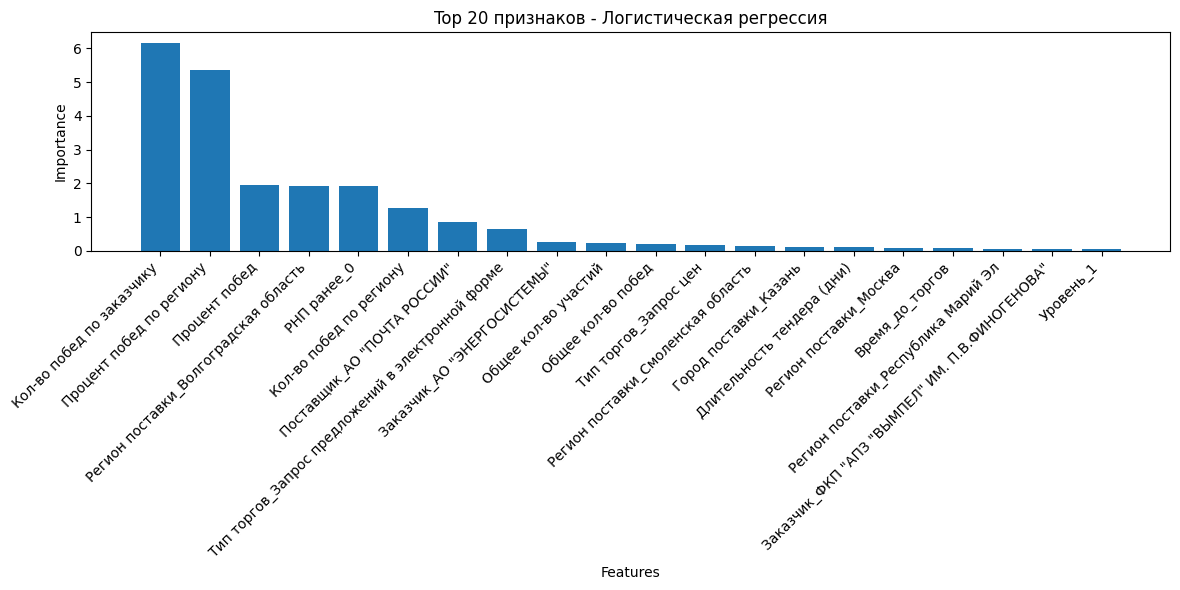


Важность признаков:
                                               feature  importance
3                            Кол-во побед по заказчику    6.170550
2                             Процент побед по региону    5.362758
0                                        Процент побед    1.951103
24               Регион поставки_Волгоградская область    1.909762
306                                        РНП ранее_0    1.909762
1                              Кол-во побед по региону    1.259397
588                        Поставщик_АО "ПОЧТА РОССИИ"    0.856317
301  Тип торгов_Запрос предложений в электронной форме    0.647658
369                        Заказчик_АО "ЭНЕРГОСИСТЕМЫ"    0.266668
7                                 Общее кол-во участий    0.235166
8                                   Общее кол-во побед    0.192845
295                              Тип торгов_Запрос цен    0.183756
80                  Регион поставки_Смоленская область    0.157313
448                              Город по

In [67]:
print("Важность признаков для логистической регрессии:")
log_reg_model = grid_search_log_reg.best_estimator_
log_reg_importance = get_feature_importance(
    log_reg_model.named_steps['classifier'],
    X_transformed_log_reg,
    y_test,
    feature_names,
    'coef'
)
plot_feature_importance(log_reg_importance.head(20), "Top 20 признаков - Логистическая регрессия")

Логистическая регрессия Metrics:
Accuracy: 0.7644
Precision: 0.858
Recall: 0.7961
F1-Score: 0.8259
ROC-AUC: 0.8628

Confusion Matrix:


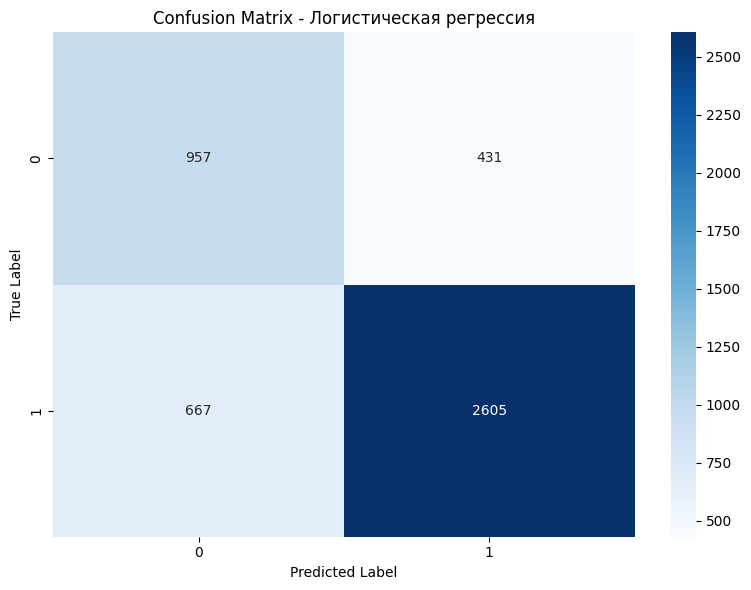

In [55]:
evaluate_model("Логистическая регрессия", y_test, y_pred, y_pred_proba)

In [56]:
model_filename = 'logistic_regression_model.joblib'
dump(grid_search_log_reg, model_filename)

['logistic_regression_model.joblib']

In [57]:
pipeline_gnb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

pipeline_bnb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', BernoulliNB())
])

param_grid_nb = {}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_gnb = GridSearchCV(
    pipeline_gnb,
    param_grid_nb,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid_search_gnb.fit(X_train_clean, y_train)
print("Gaussian Naive Bayes:")

print("\nРезультаты кросс-валидации:")
cv_results = pd.DataFrame(grid_search_gnb.cv_results_)
for i in range(3):
    print(f"Fold {i+1} ROC-AUC: {cv_results[f'split{i}_test_score'][grid_search_gnb.best_index_]:.4f}")

print(f"\nСредний Recall на кросс-валидации: {grid_search_gnb.best_score_:.4f}")

y_pred = grid_search_gnb.predict(X_test)
y_pred_proba = grid_search_gnb.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

grid_search_bnb = GridSearchCV(
    pipeline_bnb,
    param_grid_nb,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid_search_bnb.fit(X_train_clean, y_train)
print("\nBernoulli Naive Bayes:")

print("\nРезультаты кросс-валидации:")
cv_results = pd.DataFrame(grid_search_bnb.cv_results_)
for i in range(3):
    print(f"Fold {i+1} ROC-AUC: {cv_results[f'split{i}_test_score'][grid_search_bnb.best_index_]:.4f}")

print(f"\nСредний Recall на кросс-валидации: {grid_search_bnb.best_score_:.4f}")

y_pred = grid_search_bnb.predict(X_test)
y_pred_proba = grid_search_bnb.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

Gaussian Naive Bayes:

Результаты кросс-валидации:
Fold 1 ROC-AUC: 0.6935
Fold 2 ROC-AUC: 0.6899
Fold 3 ROC-AUC: 0.6964

Средний Recall на кросс-валидации: 0.6933
Recall на тестовой выборке: 0.7867

Bernoulli Naive Bayes:

Результаты кросс-валидации:
Fold 1 ROC-AUC: 0.8880
Fold 2 ROC-AUC: 0.8853
Fold 3 ROC-AUC: 0.8913

Средний Recall на кросс-валидации: 0.8882
Recall на тестовой выборке: 0.9542



Важность признаков для Gaussian Naive Bayes:


/Users/arinazajceva/Desktop/project — копия/visualization_features.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


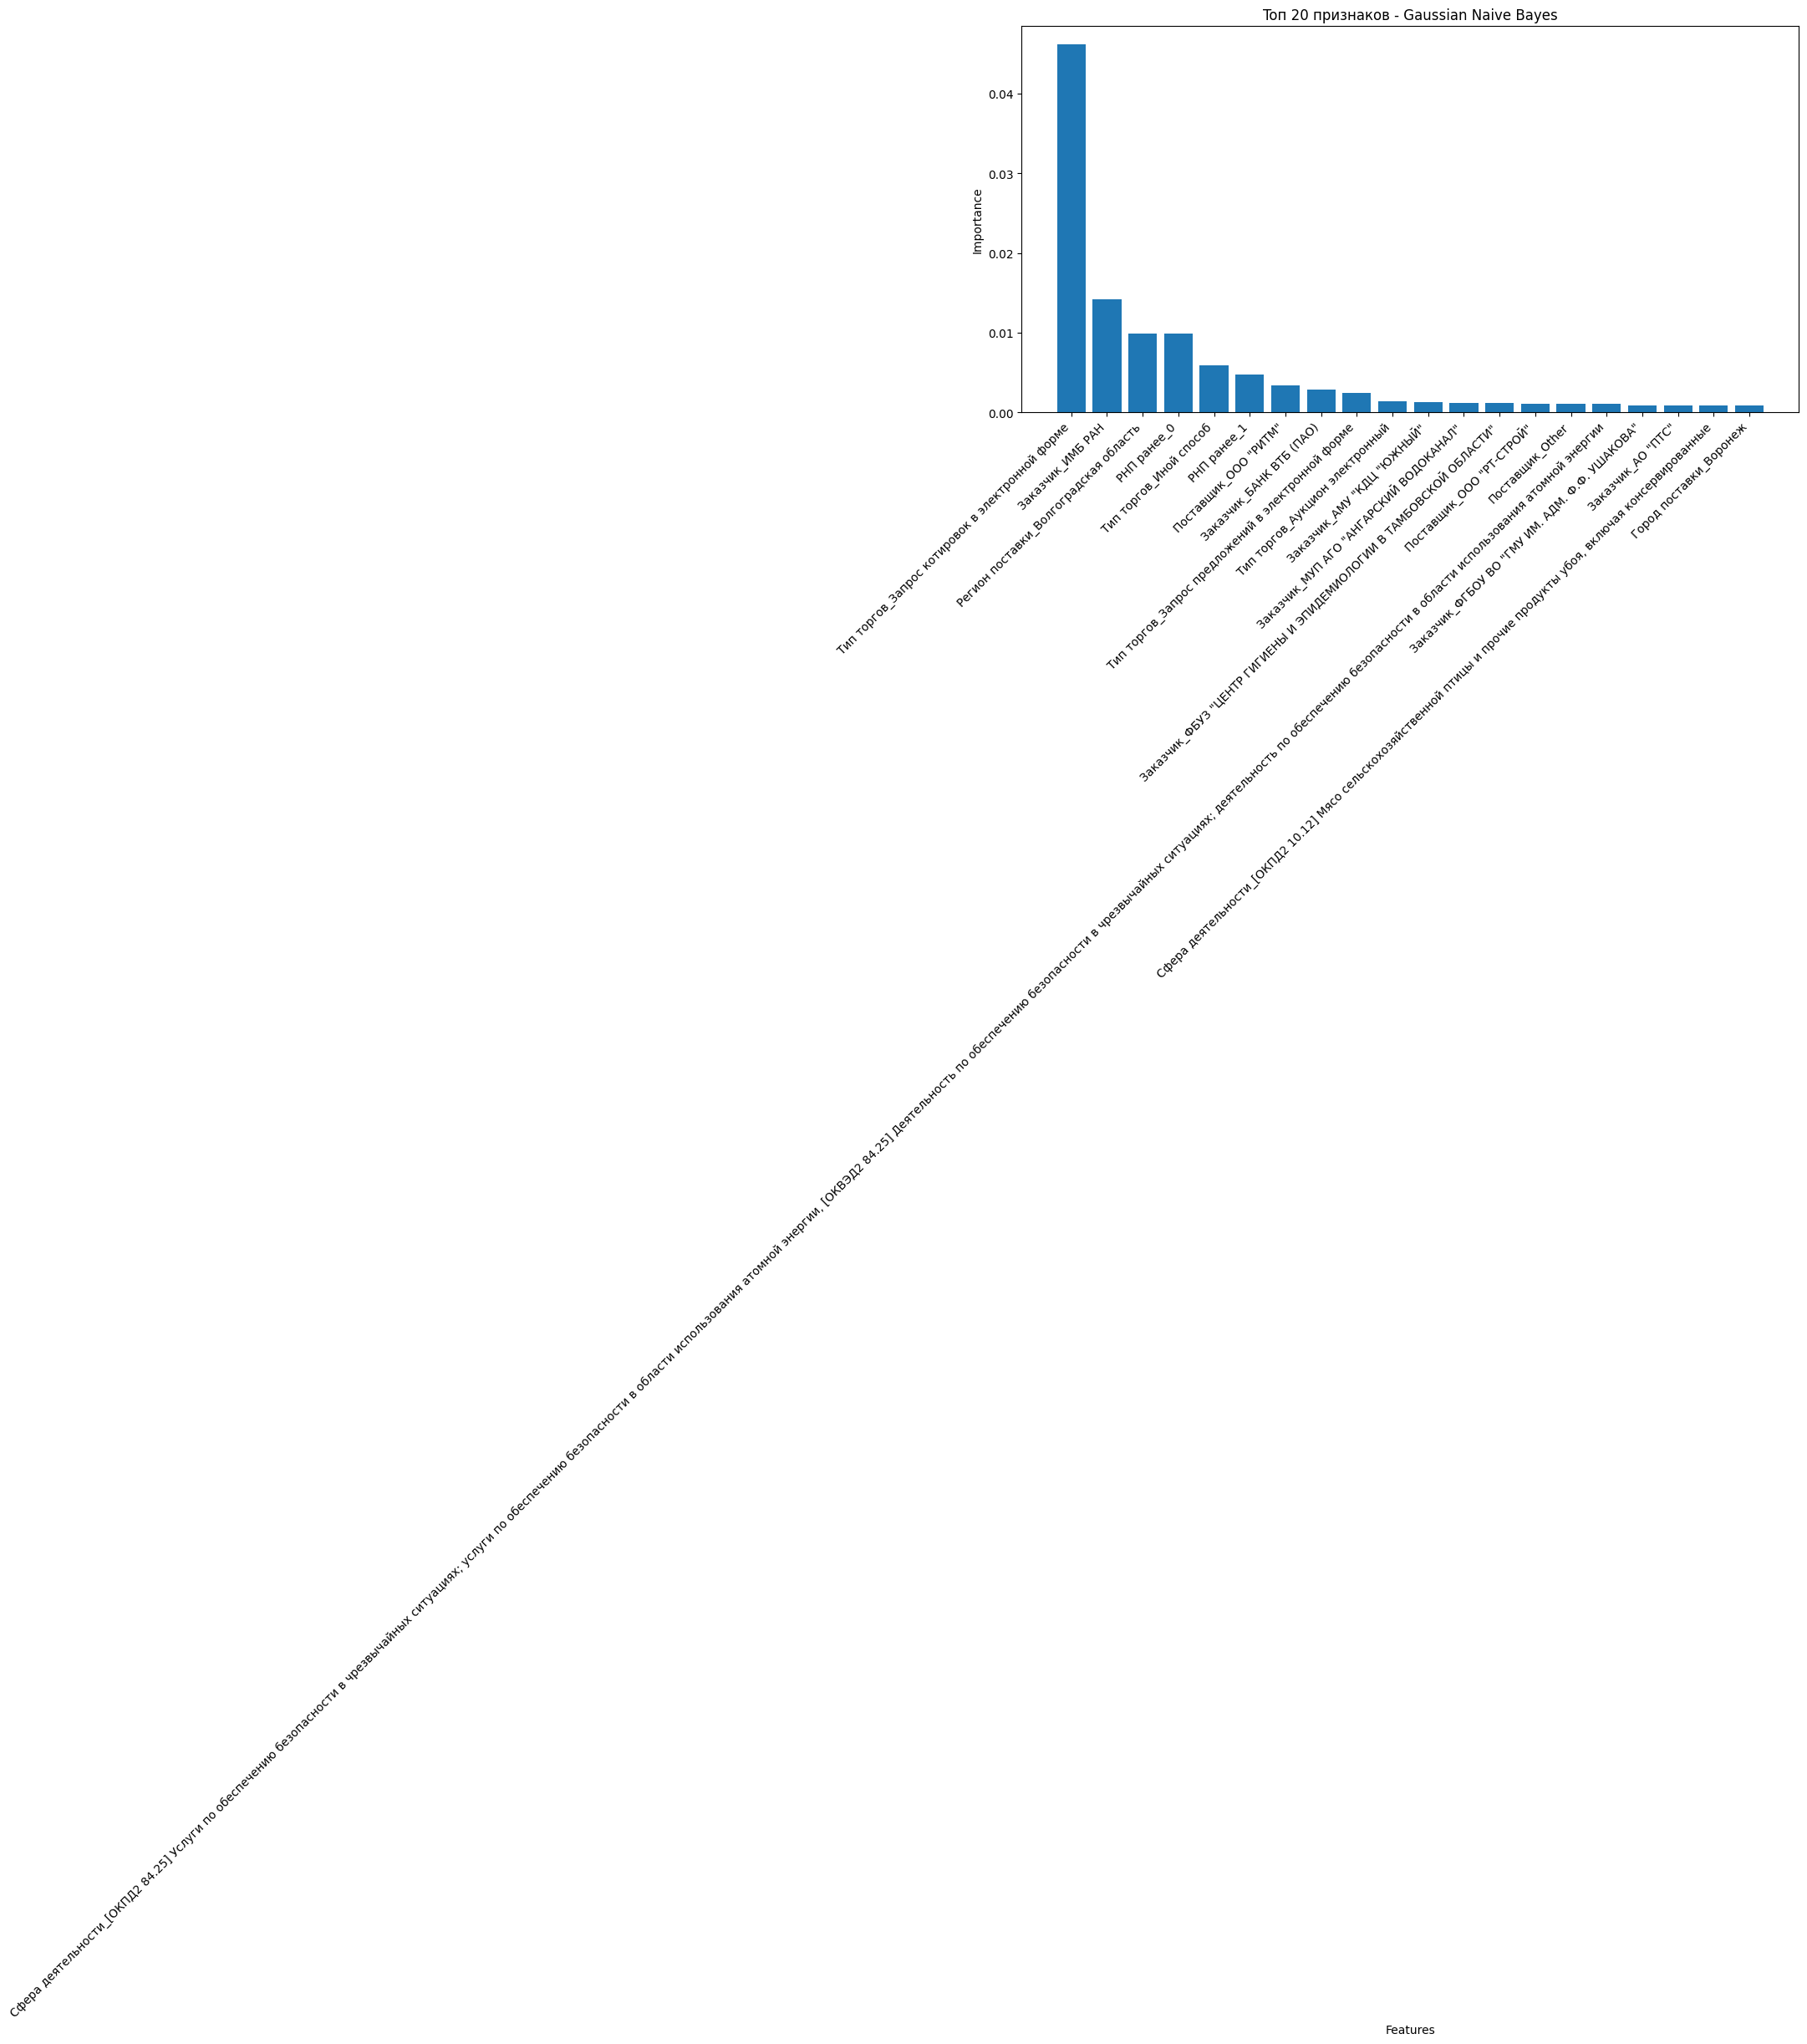


Важность признаков:
                                               feature  importance
298    Тип торгов_Запрос котировок в электронной форме    0.046137
403                                   Заказчик_ИМБ РАН    0.014185
24               Регион поставки_Волгоградская область    0.009871
306                                        РНП ранее_0    0.009871
303                             Тип торгов_Иной способ    0.005966
307                                        РНП ранее_1    0.004764
562                               Поставщик_ООО "РИТМ"    0.003455
315                            Заказчик_БАНК ВТБ (ПАО)    0.002833
301  Тип торгов_Запрос предложений в электронной форме    0.002425
300                     Тип торгов_Аукцион электронный    0.001438
368                          Заказчик_АМУ "КДЦ "ЮЖНЫЙ"    0.001352
358             Заказчик_МУП АГО "АНГАРСКИЙ ВОДОКАНАЛ"    0.001180
320  Заказчик_ФБУЗ "ЦЕНТР ГИГИЕНЫ И ЭПИДЕМИОЛОГИИ В...    0.001159
563                           Поставщик_О

/Users/arinazajceva/Desktop/project — копия/visualization_features.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


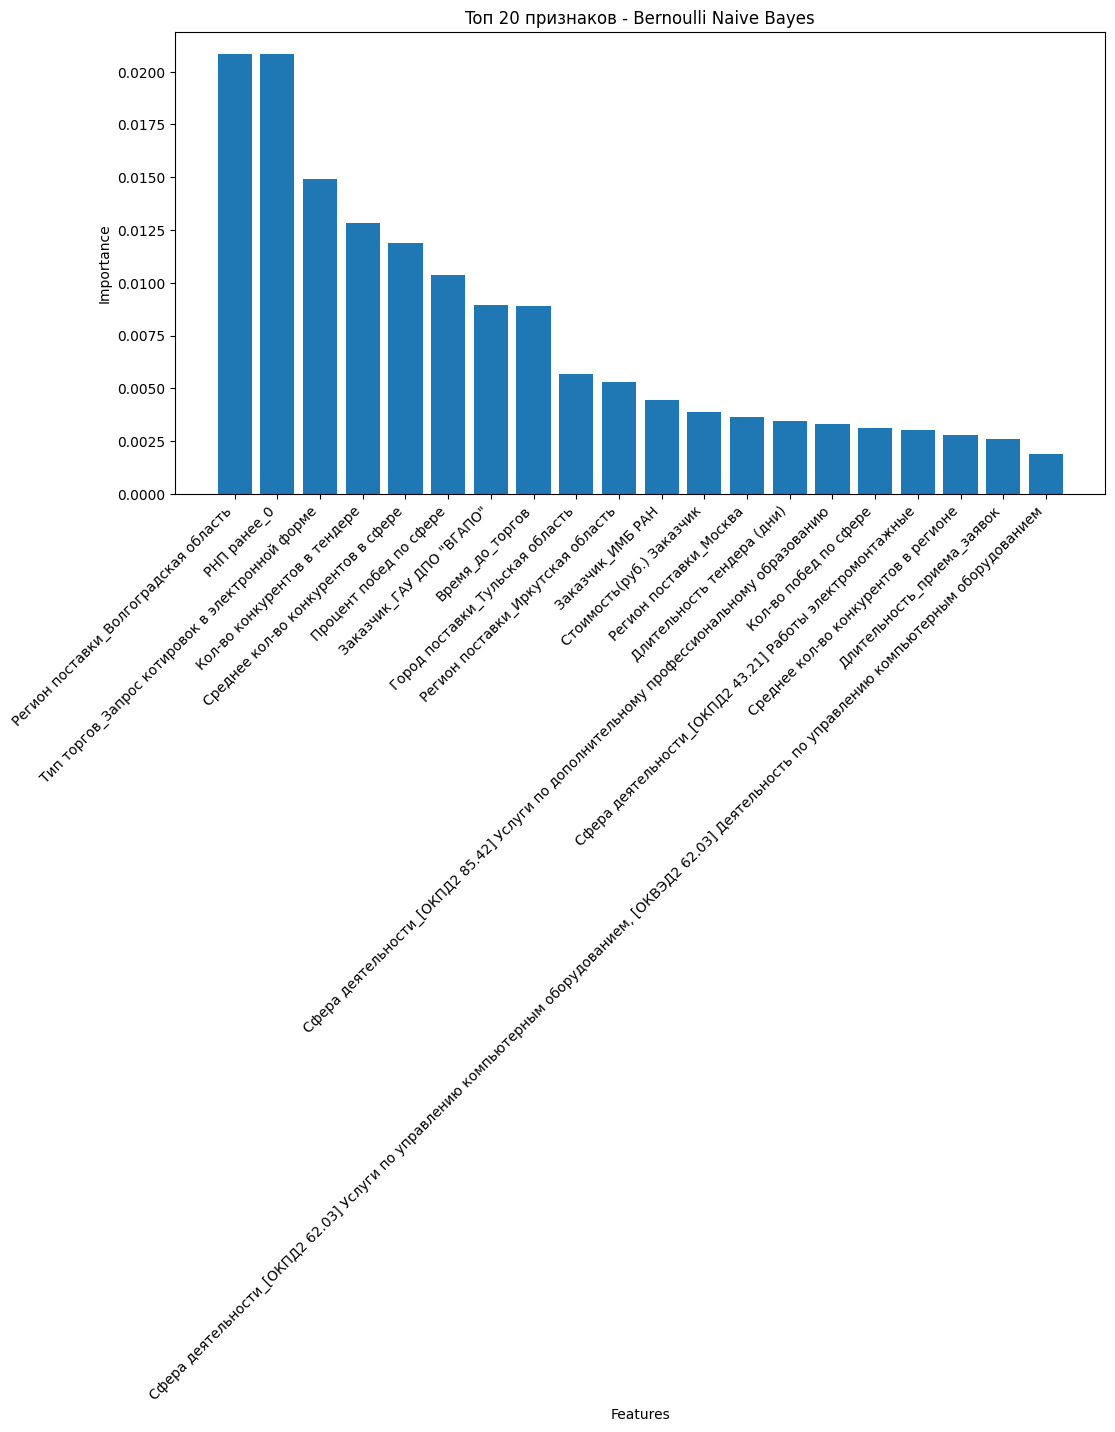


Важность признаков:
                                               feature  importance
24               Регион поставки_Волгоградская область    0.020837
306                                        РНП ранее_0    0.020837
298    Тип торгов_Запрос котировок в электронной форме    0.014914
12                        Кол-во конкурентов в тендере    0.012811
14                  Среднее кол-во конкурентов в сфере    0.011888
6                               Процент побед по сфере    0.010365
313                           Заказчик_ГАУ ДПО "ВГАПО"    0.008970
11                                     Время_до_торгов    0.008906
543                    Город поставки_Тульская область    0.005665
66                   Регион поставки_Иркутская область    0.005322
403                                   Заказчик_ИМБ РАН    0.004442
9                             Стоимость(руб.) Заказчик    0.003863
23                              Регион поставки_Москва    0.003670
15                          Длительность 

In [59]:
trained_preprocessor_gnb = grid_search_gnb.best_estimator_.named_steps['preprocessor']
X_transformed_gnb = trained_preprocessor_gnb.transform(X_test)

trained_preprocessor_bnb = grid_search_bnb.best_estimator_.named_steps['preprocessor']
X_transformed_bnb = trained_preprocessor_bnb.transform(X_test)

print("Важность признаков для Gaussian Naive Bayes:")
gnb_model = grid_search_gnb.best_estimator_
gnb_importance = get_feature_importance(
    gnb_model.named_steps['classifier'],
    X_transformed_gnb,
    y_test,
    feature_names,
    'permutation'
)
plot_feature_importance(gnb_importance.head(20), "Toп 20 признаков - Gaussian Naive Bayes")

print("\nВажность признаков для Bernoulli Naive Bayes:")
bnb_model = grid_search_bnb.best_estimator_
bnb_importance = get_feature_importance(
    bnb_model.named_steps['classifier'],
    X_transformed_bnb,
    y_test,
    feature_names,
    'permutation'
)
plot_feature_importance(bnb_importance.head(20), "Toп 20 признаков - Bernoulli Naive Bayes")

Gaussian Naive Bayes Metrics:
Accuracy: 0.7431
Precision: 0.7489
Recall: 0.9542
F1-Score: 0.8391
ROC-AUC: 0.8958

Confusion Matrix:


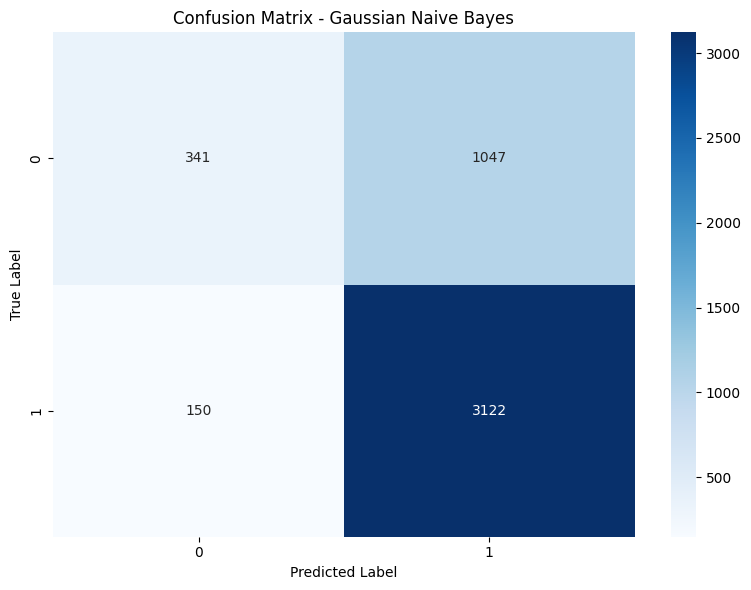

Bernoulli Naive Bayes Metrics:
Accuracy: 0.7431
Precision: 0.7489
Recall: 0.9542
F1-Score: 0.8391
ROC-AUC: 0.8958

Confusion Matrix:


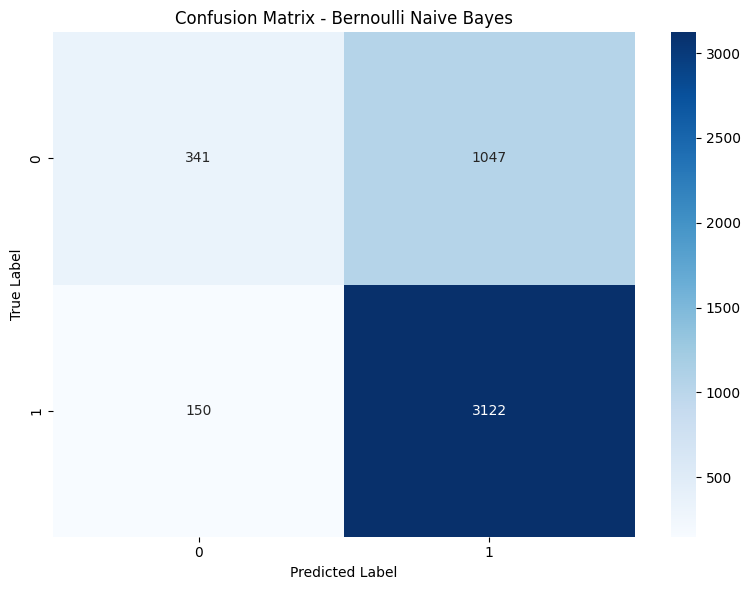

In [60]:
evaluate_model("Gaussian Naive Bayes", y_test, y_pred, y_pred_proba)
evaluate_model("Bernoulli Naive Bayes", y_test, y_pred, y_pred_proba)

In [61]:
dump(grid_search_gnb, 'gaussian_nb_model.joblib')
dump(grid_search_bnb, 'bernoulli_nb_model.joblib')

gnb_info = {
    'best_params': grid_search_gnb.best_params_,
    'best_score': grid_search_gnb.best_score_,
    'cv_results': pd.DataFrame(grid_search_gnb.cv_results_).to_dict()
}
dump(gnb_info, 'gaussian_nb_info.joblib')

bnb_info = {
    'best_params': grid_search_bnb.best_params_,
    'best_score': grid_search_bnb.best_score_,
    'cv_results': pd.DataFrame(grid_search_bnb.cv_results_).to_dict()
}
dump(bnb_info, 'bernoulli_nb_info.joblib')

['bernoulli_nb_info.joblib']

In [62]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [200],
    'classifier__max_depth': [10, 15],
    'classifier__min_samples_split': [2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
)

grid_search_rf.fit(X_train_clean, y_train)
print("Random Forest:")
print("\nЛучшие параметры:")
print(grid_search_rf.best_params_)

print("\nРезультаты кросс-валидации:")
cv_results = pd.DataFrame(grid_search_rf.cv_results_)
for i in range(3):
    print(f"Fold {i+1} Recall: {cv_results[f'split{i}_test_score'][grid_search_rf.best_index_]:.4f}")

print(f"\nСреднее ROC-AUC на кросс-валидации: {grid_search_rf.best_score_:.4f}")

y_pred = grid_search_rf.predict(X_test)
y_pred_proba = grid_search_rf.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

Random Forest:

Лучшие параметры:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Результаты кросс-валидации:
Fold 1 Recall: 0.9637
Fold 2 Recall: 0.9550
Fold 3 Recall: 0.9567

Среднее ROC-AUC на кросс-валидации: 0.9585
Recall на тестовой выборке: 0.8319



Важность признаков для Random Forest:
Предупреждение: количество признаков (605) не соответствует размеру важностей (603)


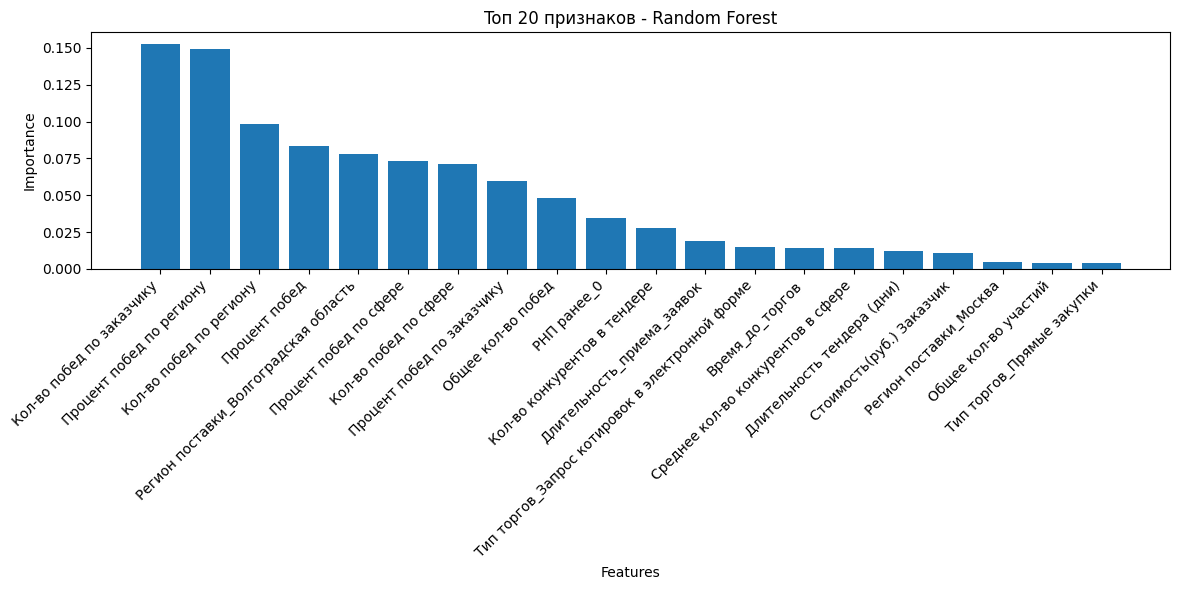


Важность признаков:
                                             feature  importance
3                          Кол-во побед по заказчику    0.152966
2                           Процент побед по региону    0.149028
1                            Кол-во побед по региону    0.098538
0                                      Процент побед    0.083285
24             Регион поставки_Волгоградская область    0.077734
6                             Процент побед по сфере    0.073062
5                              Кол-во побед по сфере    0.071132
4                         Процент побед по заказчику    0.059938
8                                 Общее кол-во побед    0.047837
306                                      РНП ранее_0    0.034728
12                      Кол-во конкурентов в тендере    0.028040
10                        Длительность_приема_заявок    0.018924
298  Тип торгов_Запрос котировок в электронной форме    0.014944
11                                   Время_до_торгов    0.013891
14  

In [70]:
trained_preprocessor_rf = grid_search_rf.best_estimator_.named_steps['preprocessor']
X_transformed_rf = trained_preprocessor_rf.transform(X_test)

print("\nВажность признаков для Random Forest:")
rf_model = grid_search_rf.best_estimator_
rf_importance = get_feature_importance(
    rf_model.named_steps['classifier'],
    X_transformed_rf,
    y_test,
    feature_names,
    'built_in'
)
plot_feature_importance(rf_importance.head(20), "Toп 20 признаков - Random Forest")

Random Forest Metrics:
Accuracy: 0.7897
Precision: 0.8636
Recall: 0.8319
F1-Score: 0.8474
ROC-AUC: 0.879

Confusion Matrix:


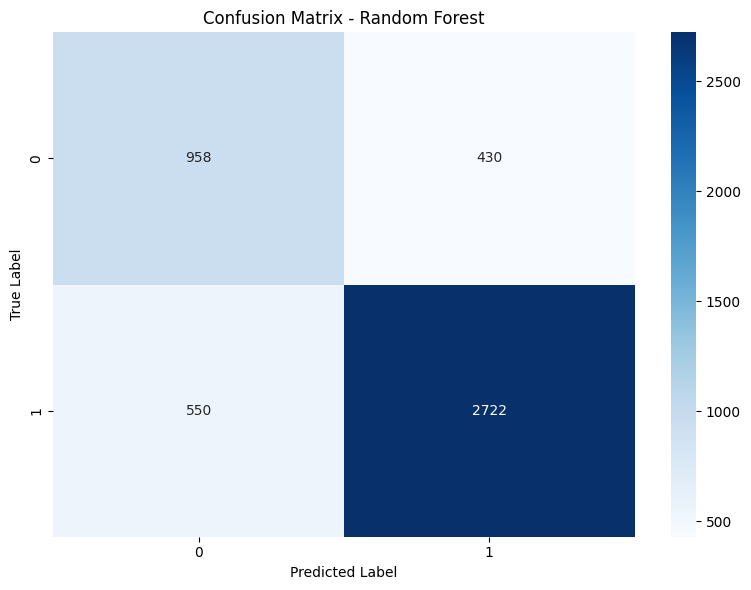

In [71]:
evaluate_model("Random Forest", y_test, y_pred, y_pred_proba)

In [72]:
dump(grid_search_rf, 'random_forest_model.joblib')

model_info = {
    'best_params': grid_search_rf.best_params_,
    'best_score': grid_search_rf.best_score_,
    'cv_results': pd.DataFrame(grid_search_rf.cv_results_).to_dict()
}
dump(model_info, 'random_forest_info.joblib')

['random_forest_info.joblib']

In [73]:
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2, 4],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid_dt,
    cv=cv,
    scoring='recall',
)

grid_search_dt.fit(X_train_clean, y_train)
print("Decision Tree:")
print("\nЛучшие параметры:")
print(grid_search_dt.best_params_)

print("\nРезультаты кросс-валидации:")
cv_results = pd.DataFrame(grid_search_dt.cv_results_)
for i in range(3):
    print(f"Fold {i+1} Recall: {cv_results[f'split{i}_test_score'][grid_search_dt.best_index_]:.4f}")

print(f"\nСреднее Recall на кросс-валидации: {grid_search_dt.best_score_:.4f}")

y_pred = grid_search_dt.predict(X_test)
y_pred_proba = grid_search_dt.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

Decision Tree:

Лучшие параметры:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}

Результаты кросс-валидации:
Fold 1 Recall: 0.9607
Fold 2 Recall: 0.9613
Fold 3 Recall: 0.9529

Среднее Recall на кросс-валидации: 0.9583
Recall на тестовой выборке: 0.8099



Важность признаков для Decision Tree:
Предупреждение: количество признаков (605) не соответствует размеру важностей (603)


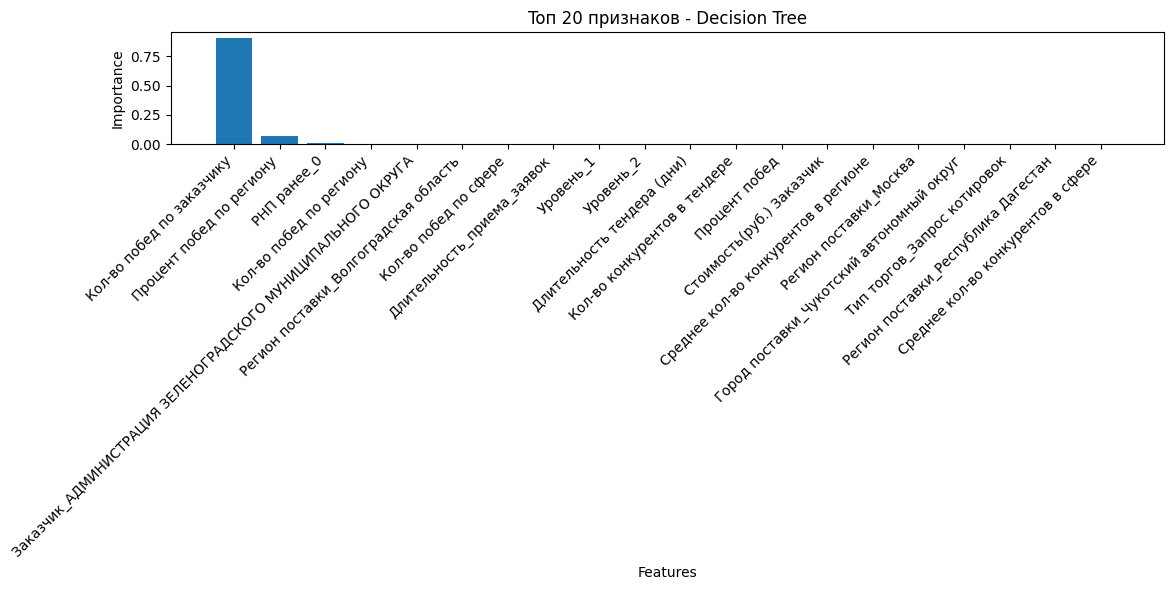


Важность признаков:
                                               feature  importance
3                            Кол-во побед по заказчику    0.908497
2                             Процент побед по региону    0.071809
306                                        РНП ранее_0    0.011495
1                              Кол-во побед по региону    0.002477
388  Заказчик_АДМИНИСТРАЦИЯ ЗЕЛЕНОГРАДСКОГО МУНИЦИП...    0.001035
24               Регион поставки_Волгоградская область    0.000580
5                                Кол-во побед по сфере    0.000544
10                          Длительность_приема_заявок    0.000484
19                                           Уровень_1    0.000480
18                                           Уровень_2    0.000386
15                          Длительность тендера (дни)    0.000362
12                        Кол-во конкурентов в тендере    0.000322
0                                        Процент побед    0.000223
9                             Стоимость(р

In [74]:
trained_preprocessor_dt = grid_search_dt.best_estimator_.named_steps['preprocessor']
X_transformed_dt = trained_preprocessor_dt.transform(X_test)

print("\nВажность признаков для Decision Tree:")
dt_model = grid_search_dt.best_estimator_
dt_importance = get_feature_importance(
    dt_model.named_steps['classifier'],
    X_transformed_dt,
    y_test,
    feature_names,
    'built_in'
)
plot_feature_importance(dt_importance.head(20), "Toп 20 признаков - Decision Tree")

Decision Tree Metrics:
Accuracy: 0.8122
Precision: 0.9128
Recall: 0.8099
F1-Score: 0.8583
ROC-AUC: 0.8497

Confusion Matrix:


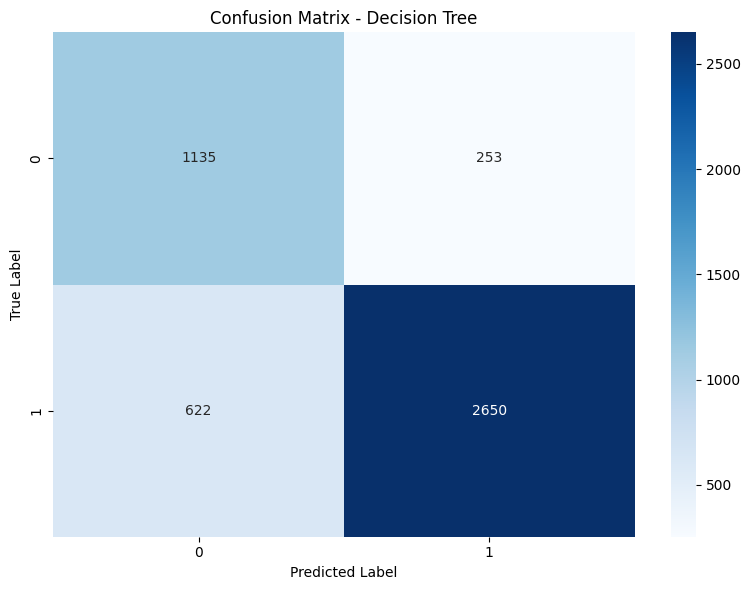

In [75]:
evaluate_model("Decision Tree", y_test, y_pred, y_pred_proba)

In [76]:
dump(grid_search_dt, 'decision_tree_model.joblib')

model_info = {
    'best_params': grid_search_dt.best_params_,
    'best_score': grid_search_dt.best_score_,
    'cv_results': pd.DataFrame(grid_search_dt.cv_results_).to_dict()
}
dump(model_info, 'decision_tree_info.joblib')

['decision_tree_info.joblib']

In [90]:
X_train_transformed = preprocessor.fit_transform(X_train_clean)
X_test_transformed = preprocessor.transform(X_test)

if not isinstance(X_train_transformed, np.ndarray):
    X_train_transformed = X_train_transformed.toarray()
if not isinstance(X_test_transformed, np.ndarray):
    X_test_transformed = X_test_transformed.toarray()

# Создаем и обучаем базовую модель XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores_recall = []
cv_scores_roc_auc = []

print("XGBoost:")
print("\nРезультаты кросс-валидации:")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_fold_train = X_train_transformed[train_idx]
    X_fold_val = X_train_transformed[val_idx]
    y_fold_train = y_train[train_idx]
    y_fold_val = y_train[val_idx]
    
    xgb_model.fit(X_fold_train, y_fold_train)
    
    y_pred = xgb_model.predict(X_fold_val)
    y_pred_proba = xgb_model.predict_proba(X_fold_val)[:, 1]
    
    fold_recall = recall_score(y_fold_val, y_pred)
    fold_roc_auc = roc_auc_score(y_fold_val, y_pred_proba)
    
    cv_scores_recall.append(fold_recall)
    cv_scores_roc_auc.append(fold_roc_auc)
    
    print(f"Fold {fold} Recall: {fold_recall:.4f}")

print(f"Средний Recall на кросс-валидации: {np.mean(cv_scores_recall):.4f}")

xgb_model.fit(X_train_transformed, y_train)

y_pred = xgb_model.predict(X_test_transformed)
y_pred_proba = xgb_model.predict_proba(X_test_transformed)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

XGBoost:

Результаты кросс-валидации:
Fold 1 Recall: 0.9588
Fold 2 Recall: 0.9512
Fold 3 Recall: 0.9545
Средний Recall на кросс-валидации: 0.9548
Recall на тестовой выборке: 0.8282


Размер feature_importances_: 603
Количество сформированных имен признаков: 605
Обрезаем список имен признаков

Топ-20 важных признаков:
                                               feature  importance
2                             Процент побед по региону    0.339986
3                            Кол-во побед по заказчику    0.315413
5                                Кол-во побед по сфере    0.182348
306                                        РНП ранее_0    0.028908
24               Регион поставки_Волгоградская область    0.028680
6                               Процент побед по сфере    0.020793
1                              Кол-во побед по региону    0.019698
4                           Процент побед по заказчику    0.016521
388  Заказчик_АДМИНИСТРАЦИЯ ЗЕЛЕНОГРАДСКОГО МУНИЦИП...    0.008735
12                        Кол-во конкурентов в тендере    0.002888
305                        Тип торгов_Запрос котировок    0.002879
369                        Заказчик_АО "ЭНЕРГОСИСТЕМЫ"    0.

/Users/arinazajceva/Desktop/project — копия/visualization_features.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


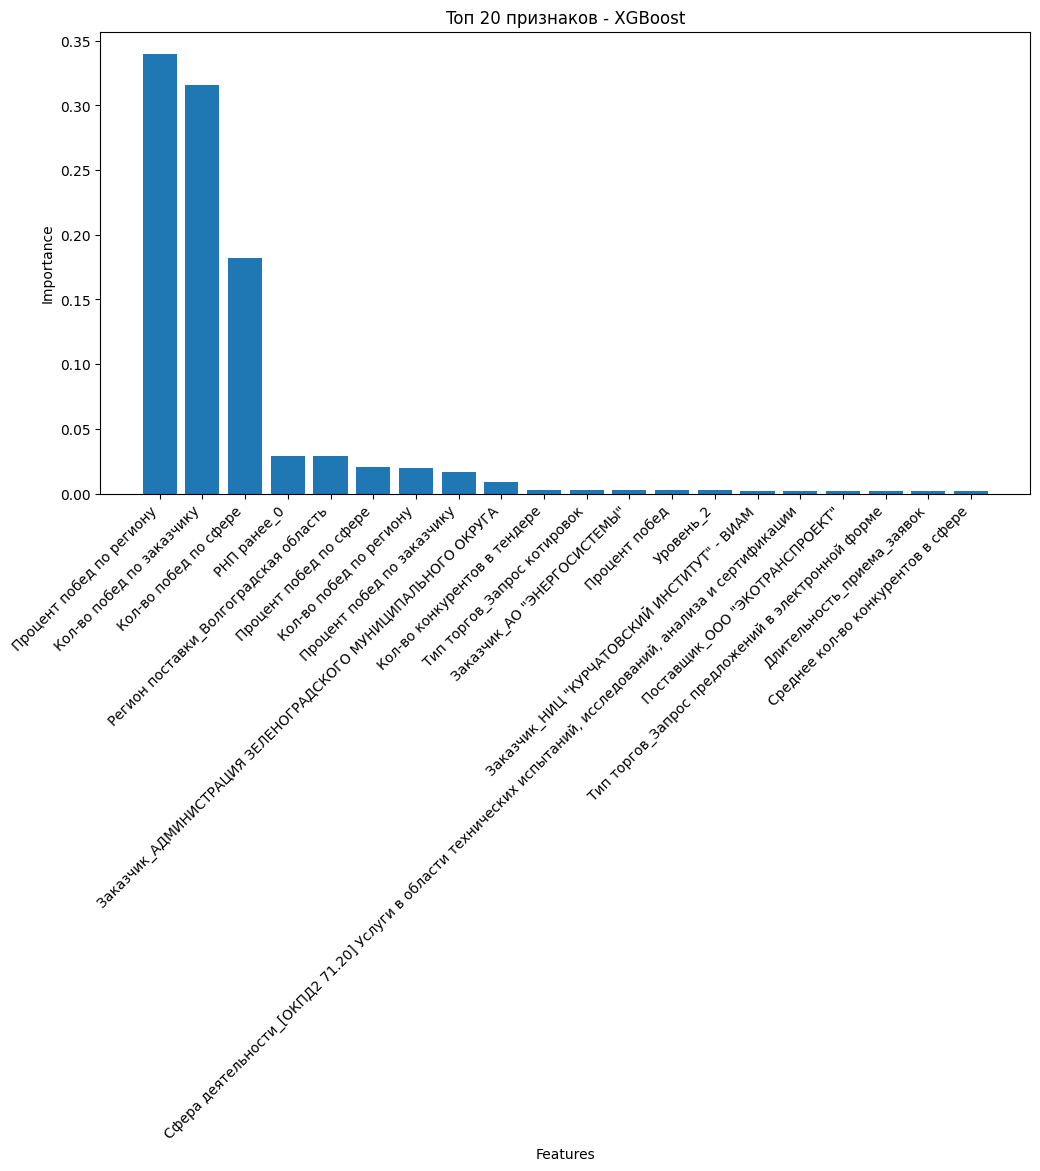


Важность признаков:
                                               feature  importance
2                             Процент побед по региону    0.339986
3                            Кол-во побед по заказчику    0.315413
5                                Кол-во побед по сфере    0.182348
306                                        РНП ранее_0    0.028908
24               Регион поставки_Волгоградская область    0.028680
6                               Процент побед по сфере    0.020793
1                              Кол-во побед по региону    0.019698
4                           Процент побед по заказчику    0.016521
388  Заказчик_АДМИНИСТРАЦИЯ ЗЕЛЕНОГРАДСКОГО МУНИЦИП...    0.008735
12                        Кол-во конкурентов в тендере    0.002888
305                        Тип торгов_Запрос котировок    0.002879
369                        Заказчик_АО "ЭНЕРГОСИСТЕМЫ"    0.002687
0                                        Процент побед    0.002633
18                                       

In [94]:
feature_names = []
feature_names.extend(numerical_features)

for cat_feature in categorical_features:
    unique_values = X[cat_feature].unique()
    unique_values = [val for val in unique_values if pd.notna(val)]
    feature_names.extend([f"{cat_feature}_{val}" for val in unique_values])

if len(feature_names) > len(xgb_model.feature_importances_):
    feature_names = feature_names[:len(xgb_model.feature_importances_)]
elif len(feature_names) < len(xgb_model.feature_importances_):
    for i in range(len(feature_names), len(xgb_model.feature_importances_)):
        feature_names.append(f"feature_{i}")

xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values('importance', ascending=False)

print("\nТоп-20 важных признаков:")
print(xgb_importance.head(20))

plot_feature_importance(xgb_importance.head(20), "Toп 20 признаков - XGBoost")

XGBoost Metrics:
Accuracy: 0.797
Precision: 0.8759
Recall: 0.8282
F1-Score: 0.8514
ROC-AUC: 0.8641

Confusion Matrix:


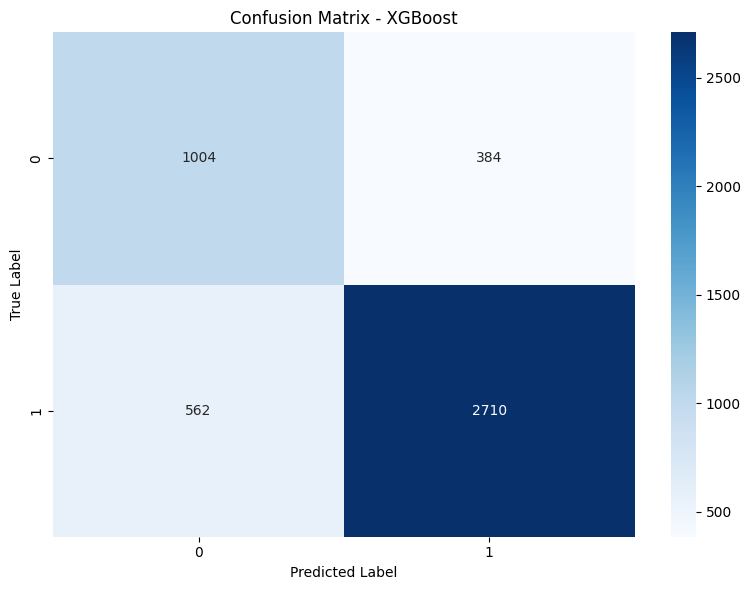

In [93]:
evaluate_model("XGBoost", y_test, y_pred, y_pred_proba)

In [95]:
dump(xgb_model, 'xgboost_model.joblib')
dump(preprocessor, 'xgboost_preprocessor.joblib')

model_info = {
    'cv_scores': cv_scores_recall,
    'mean_cv_score': np.mean(cv_scores_recall),
    'test_recall': test_recall,
    'test_roc_auc': test_roc_auc,
    'cv_results': pd.DataFrame({
        'fold': range(1, len(cv_scores_recall) + 1),
        'recall': cv_scores_recall
    }).to_dict()
}
dump(model_info, 'xgboost_info.joblib')

['xgboost_info.joblib']

In [78]:
base_estimator = DecisionTreeClassifier(max_depth=3)

pipeline_ada = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(estimator=base_estimator, random_state=42))
])

param_grid_ada = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__estimator__max_depth': [1, 2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_ada = GridSearchCV(
    pipeline_ada,
    param_grid_ada,
    cv=cv,
    scoring='recall',
)

grid_search_ada.fit(X_train_clean, y_train)
print("AdaBoost:")
print("\nЛучшие параметры:")
print(grid_search_ada.best_params_)

print("\nРезультаты кросс-валидации:")
cv_results = pd.DataFrame(grid_search_ada.cv_results_)
for i in range(3):
    print(f"Fold {i+1} Recall: {cv_results[f'split{i}_test_score'][grid_search_ada.best_index_]:.4f}")

print(f"\nСредний Recall на кросс-валидации: {grid_search_ada.best_score_:.4f}")

y_pred = grid_search_ada.predict(X_test)
y_pred_proba = grid_search_ada.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

AdaBoost:

Лучшие параметры:
{'classifier__estimator__max_depth': 2, 'classifier__learning_rate': 0.1, 'classifier__n_estimators': 100}

Результаты кросс-валидации:
Fold 1 Recall: 0.9641
Fold 2 Recall: 0.9575
Fold 3 Recall: 0.9651

Средний Recall на кросс-валидации: 0.9622
Recall на тестовой выборке: 0.8197



Важность признаков для AdaBoost:
Предупреждение: количество признаков (605) не соответствует размеру важностей (603)


/Users/arinazajceva/Desktop/project — копия/visualization_features.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


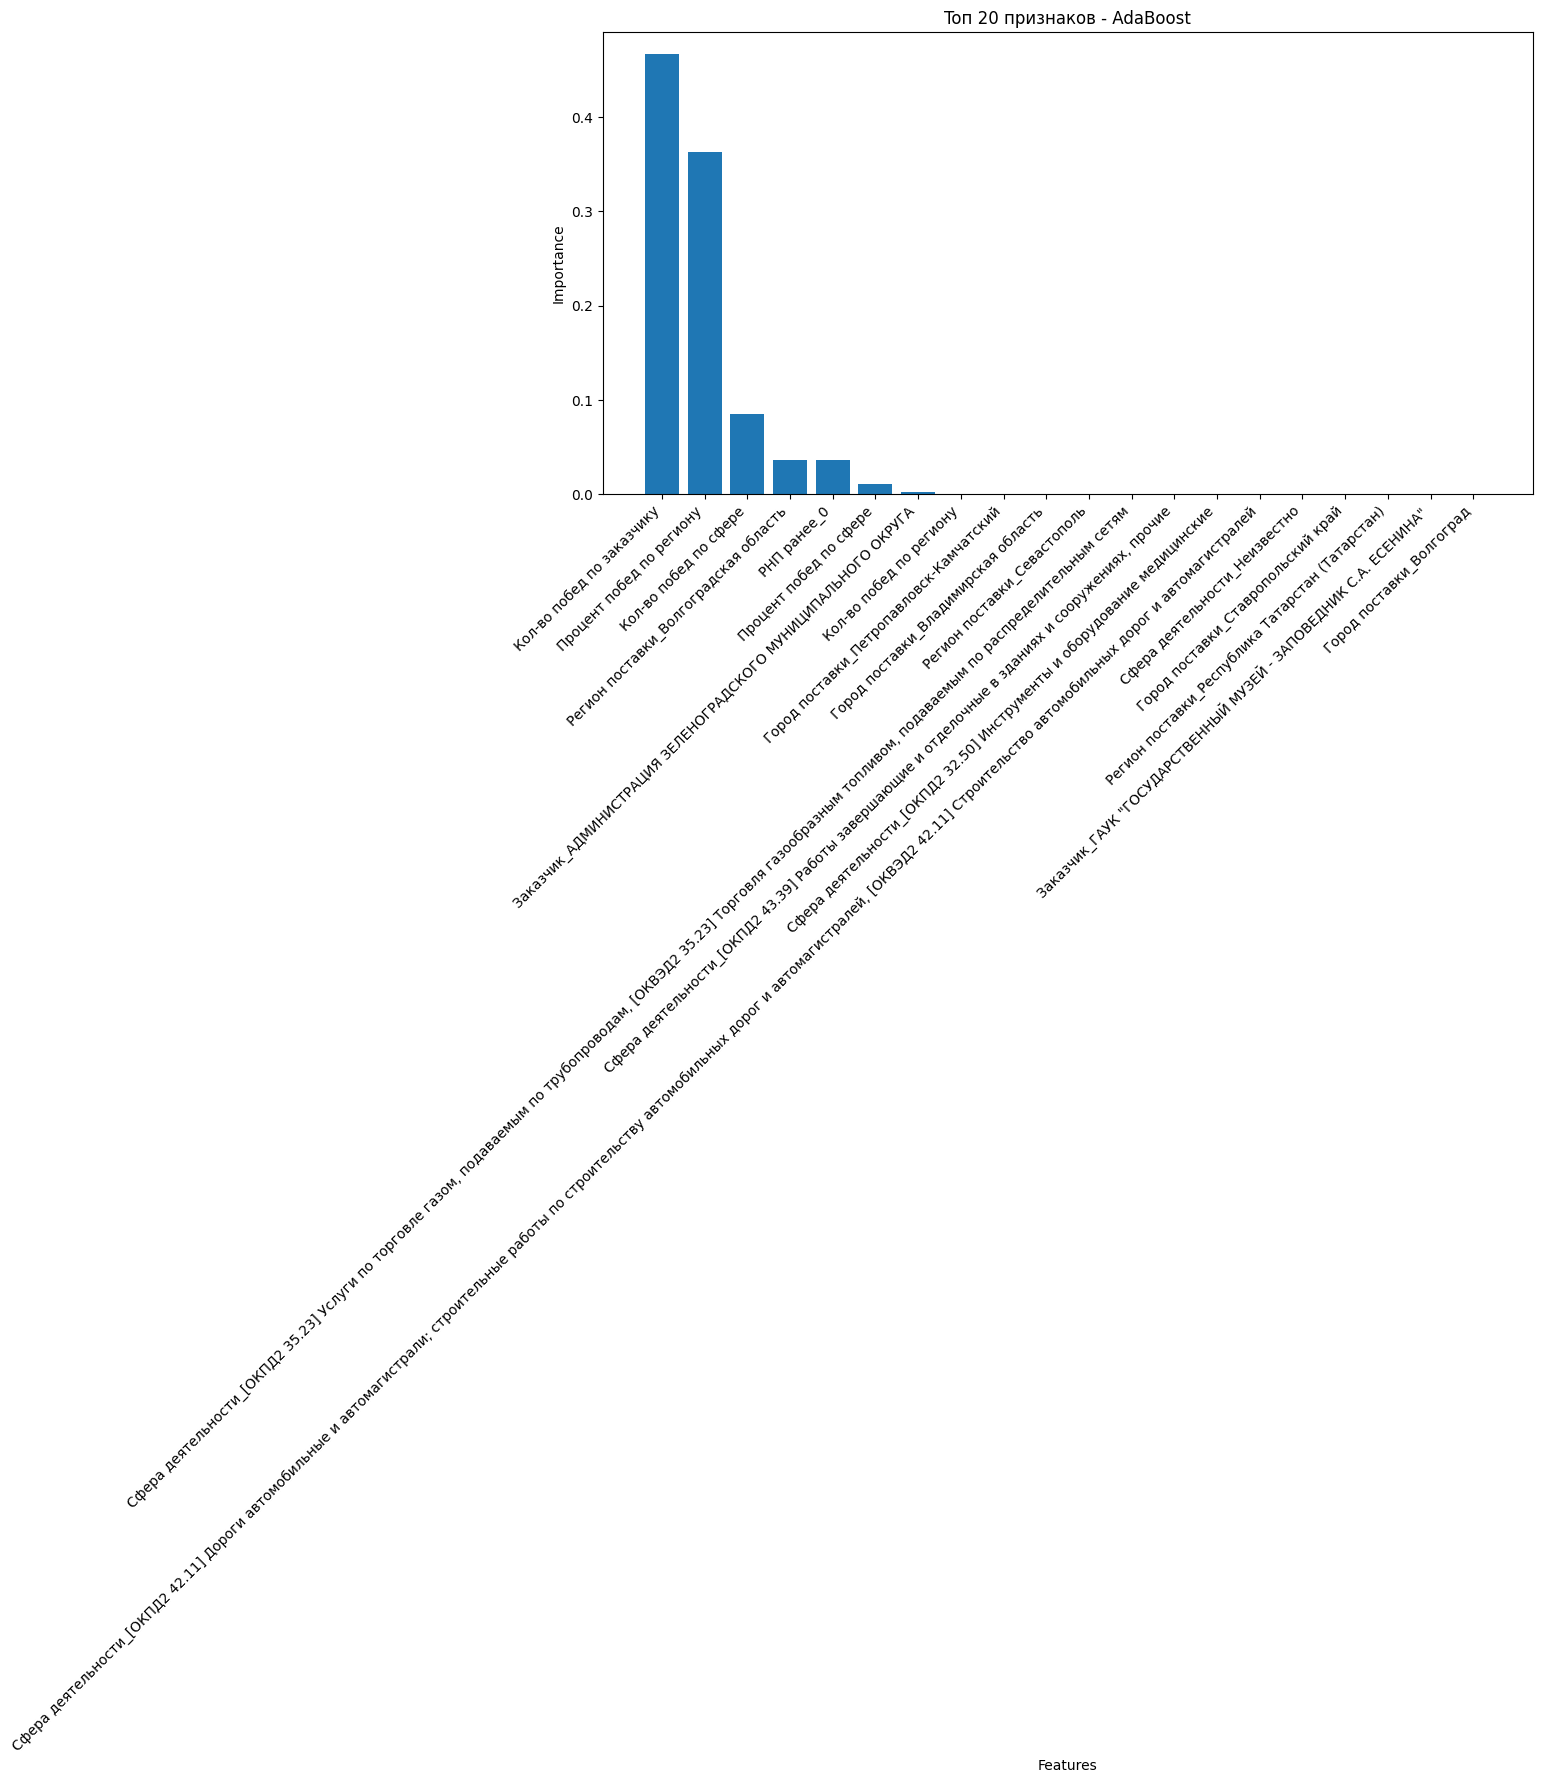


Важность признаков:
                                               feature    importance
3                            Кол-во побед по заказчику  4.671264e-01
2                             Процент побед по региону  3.632556e-01
5                                Кол-во побед по сфере  8.532568e-02
24               Регион поставки_Волгоградская область  3.600554e-02
306                                        РНП ранее_0  3.566727e-02
6                               Процент побед по сфере  1.031063e-02
388  Заказчик_АДМИНИСТРАЦИЯ ЗЕЛЕНОГРАДСКОГО МУНИЦИП...  2.294117e-03
1                              Кол-во побед по региону  1.469767e-05
553            Город поставки_Петропавловск-Камчатский  7.252626e-14
434                Город поставки_Владимирская область  7.063318e-14
82                         Регион поставки_Севастополь  3.930502e-14
266  Сфера деятельности_[ОКПД2 35.23] Услуги по тор...  3.320295e-14
205  Сфера деятельности_[ОКПД2 43.39] Работы заверш...  2.977327e-14
101  Сфера де

In [ ]:
trained_preprocessor_ada = grid_search_ada.best_estimator_.named_steps['preprocessor']
X_transformed_ada = trained_preprocessor_ada.transform(X_test)

print("Важность признаков для AdaBoost:")
ada_model = grid_search_ada.best_estimator_
ada_importance = get_feature_importance(
    ada_model.named_steps['classifier'],
    X_transformed_ada,
    y_test,
    feature_names,
    'built_in'
)
plot_feature_importance(ada_importance.head(20), "Toп 20 признаков - AdaBoost")

AdaBoost Metrics:
Accuracy: 0.7798
Precision: 0.8602
Recall: 0.8197
F1-Score: 0.8394
ROC-AUC: 0.8576

Confusion Matrix:


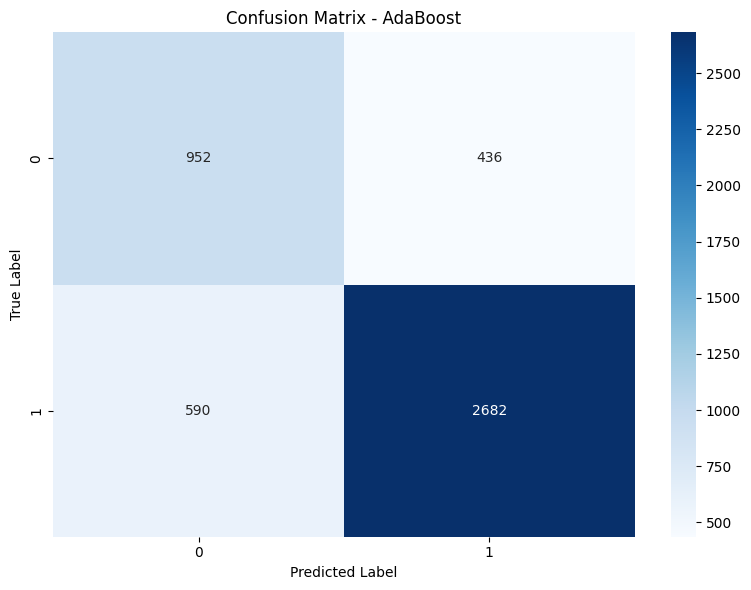

In [80]:
evaluate_model("AdaBoost", y_test, y_pred, y_pred_proba)

In [81]:
dump(grid_search_ada, 'model_name.joblib')

model_info = {
    'best_params': grid_search_ada.best_params_,
    'best_score': grid_search_ada.best_score_,
    'cv_results': pd.DataFrame(grid_search_ada.cv_results_).to_dict()
}
dump(model_info, 'ada_info.joblib')

['ada_info.joblib']

In [82]:
pipeline_lgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        random_state=42,
        objective='binary',
        metric='binary_logloss',
        min_split_gain=1e-5,
        min_child_weight=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=0.5,
        verbose=-1,
        boosting_type='gbdt'      
    ))
])

param_grid_lgb = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [3, 4],
    'classifier__learning_rate': [0.05],
    'classifier__num_leaves': [15],
    'classifier__min_child_samples': [30]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_lgb = GridSearchCV(
    pipeline_lgb,
    param_grid_lgb,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
)

grid_search_lgb.fit(X_train_clean, y_train)

print("LightGBM:")
print("\nЛучшие параметры:")
print(grid_search_lgb.best_params_)

print("\nРезультаты кросс-валидации:")
cv_results = pd.DataFrame(grid_search_lgb.cv_results_)
for i in range(3):
    print(f"Fold {i+1} Recall: {cv_results[f'split{i}_test_score'][grid_search_lgb.best_index_]:.4f}")

print(f"\nСредний Recall на кросс-валидации: {grid_search_lgb.best_score_:.4f}")

y_pred = grid_search_lgb.predict(X_test)
y_pred_proba = grid_search_lgb.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Recall на тестовой выборке: {test_recall:.4f}")

/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature nam

LightGBM:

Лучшие параметры:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__min_child_samples': 30, 'classifier__n_estimators': 100, 'classifier__num_leaves': 15}

Результаты кросс-валидации:
Fold 1 Recall: 0.9618
Fold 2 Recall: 0.9513
Fold 3 Recall: 0.9549

Средний Recall на кросс-валидации: 0.9560
Recall на тестовой выборке: 0.7778


/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Важность признаков для LightGBM:
Предупреждение: количество признаков (605) не соответствует размеру важностей (603)


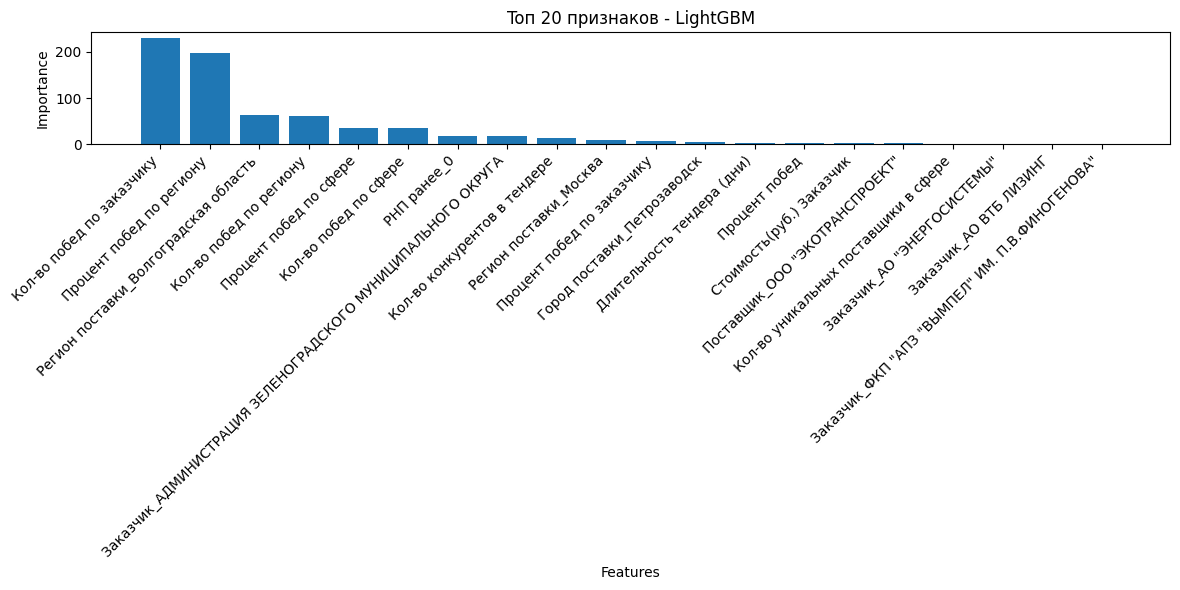


Важность признаков:
                                               feature  importance
3                            Кол-во побед по заказчику         231
2                             Процент побед по региону         197
24               Регион поставки_Волгоградская область          63
1                              Кол-во побед по региону          62
6                               Процент побед по сфере          35
5                                Кол-во побед по сфере          34
306                                        РНП ранее_0          18
388  Заказчик_АДМИНИСТРАЦИЯ ЗЕЛЕНОГРАДСКОГО МУНИЦИП...          17
12                        Кол-во конкурентов в тендере          13
23                              Регион поставки_Москва           8
4                           Процент побед по заказчику           6
545                        Город поставки_Петрозаводск           5
15                          Длительность тендера (дни)           2
0                                        

In [83]:
trained_preprocessor_lgb = grid_search_lgb.best_estimator_.named_steps['preprocessor']
X_transformed_lgb = trained_preprocessor_lgb.transform(X_test)

print("Важность признаков для LightGBM:")
lgb_model = grid_search_lgb.best_estimator_
lgb_importance = get_feature_importance(
    lgb_model.named_steps['classifier'],
    X_transformed_lgb,
    y_test,
    feature_names,
    'built_in'
)
plot_feature_importance(lgb_importance.head(20), "Toп 20 признаков - LightGBM")

LightGBM Metrics:
Accuracy: 0.7987
Precision: 0.9234
Recall: 0.7778
F1-Score: 0.8444
ROC-AUC: 0.8472

Confusion Matrix:


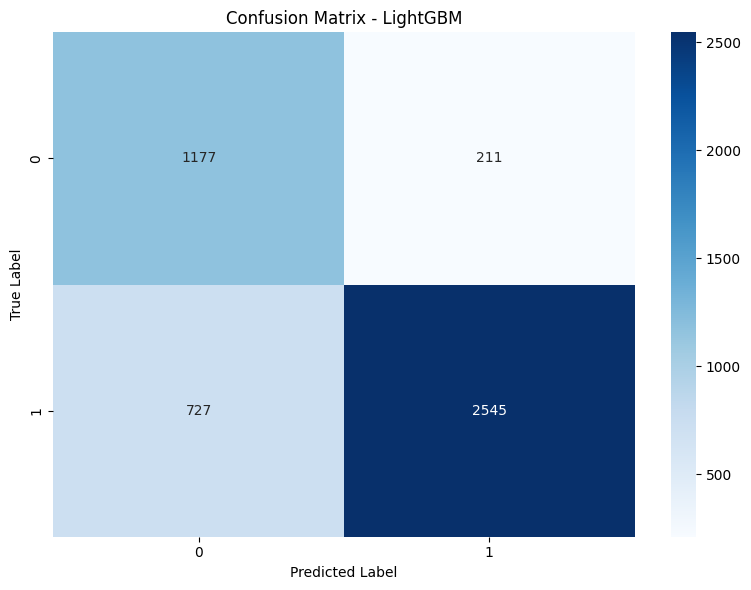

In [84]:
evaluate_model("LightGBM", y_test, y_pred, y_pred_proba)

In [85]:
dump(grid_search_lgb, 'lightgbm_model.joblib')

model_info = {
    'best_params': grid_search_lgb.best_params_,
    'best_score': grid_search_lgb.best_score_,
    'cv_results': pd.DataFrame(grid_search_lgb.cv_results_).to_dict()
}
dump(model_info, 'lightgbm_info.joblib')

['lightgbm_info.joblib']